<!-- # 0. library import & Data load -->

In [1]:
import pandas as pd
import numpy as np
import gc
import matplotlib.pyplot as plt
import datetime
from warnings import simplefilter
from functools import partial

from tqdm.auto import tqdm
import datetime as dt
from pathlib import Path

tqdm.pandas()

simplefilter(action="ignore", category=pd.errors.PerformanceWarning)
simplefilter(action="ignore", category=pd.errors.DtypeWarning)
pd.set_option('display.max_columns', None)

from pandarallel import pandarallel
pandarallel.initialize()

INFO: Pandarallel will run on 64 workers.
INFO: Pandarallel will use Memory file system to transfer data between the main process and workers.


In [2]:
store_dir = "/home/DAHS1/gangmin/my_research/clinical_multimodal_learning/data/full_data/subject_data/mimic_3_1/"

In [3]:
# data path
core_mimiciv_path = "/home/DAHS1/gangmin/my_research/clinical_multimodal_learning/data/mimic/physionet.org/files/mimiciv/3.1/"
# core_mimiciv_imgcxr_path = 'C:/Users/gangmin/dahs/data/physionet.org/files/mimic-cxr-jpg/2.1.0/'

In [4]:
# MIMIC-IV V 3.1
## core
df_admissions = pd.read_feather(core_mimiciv_path + 'hosp/admissions.ftr')
df_patients = pd.read_feather(core_mimiciv_path + 'hosp/patients.ftr')
df_transfers = pd.read_feather(core_mimiciv_path + 'hosp/transfers.ftr')

## hosp
df_diagicd = pd.read_feather(core_mimiciv_path + "hosp/diagnoses_icd.ftr")
df_procicd = pd.read_feather(core_mimiciv_path + "hosp/procedures_icd.ftr")
df_lab = pd.read_feather(core_mimiciv_path + "hosp/labevents.ftr")
df_prscr = pd.read_feather(core_mimiciv_path + "hosp/prescriptions.ftr")
df_micro = pd.read_feather(core_mimiciv_path + "hosp/microbiologyevents.ftr")
df_omr = pd.read_feather(core_mimiciv_path + "hosp/omr.ftr")
df_dlabitems = pd.read_feather(core_mimiciv_path + "hosp/d_labitems.ftr")

## icu
df_icustays = pd.read_feather(core_mimiciv_path + 'icu/icustays.ftr')
df_chart = pd.read_feather(core_mimiciv_path + "icu/chartevents.ftr")
df_input = pd.read_feather(core_mimiciv_path + "icu/inputevents.ftr")
df_output = pd.read_feather(core_mimiciv_path + "icu/outputevents.ftr")
df_proc = pd.read_feather(core_mimiciv_path + "icu/procedureevents.ftr")
df_ditems = pd.read_feather(core_mimiciv_path + "icu/d_items.ftr")

In [5]:
# cxr
df_mimic_cxr_chexpert = pd.read_csv('/home/DAHS1/gangmin/my_research/data/mimic-cxr-2.0.0-chexpert.csv')
df_mimic_cxr_metadata = pd.read_csv('/home/DAHS1/gangmin/my_research/data/mimic-cxr-2.0.0-metadata.csv')

In [6]:
# chexpert 라벨 데이터
df_mimic_cxr_chexpert.head()

,subject_id,study_id,Atelectasis,Cardiomegaly,Consolidation,Edema,Enlarged Cardiomediastinum,Fracture,Lung Lesion,Lung Opacity,No Finding,Pleural Effusion,Pleural Other,Pneumonia,Pneumothorax,Support Devices
0,10000032,50414267,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN
1,10000032,53189527,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN
2,10000032,53911762,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN
3,10000032,56699142,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN
4,10000764,57375967,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.0,NaN,NaN


In [7]:
# 라벨 제외 CXR 주요 정보
df_mimic_cxr_metadata.head()

,dicom_id,subject_id,study_id,PerformedProcedureStepDescription,ViewPosition,Rows,Columns,StudyDate,StudyTime,ProcedureCodeSequence_CodeMeaning,ViewCodeSequence_CodeMeaning,PatientOrientationCodeSequence_CodeMeaning
0,02aa804e-bde0afdd-112c0b34-7bc16630-4e384014,10000032,50414267,CHEST (PA AND LAT),PA,3056,2544,21800506,213014.531,CHEST (PA AND LAT),postero-anterior,Erect
1,174413ec-4ec4c1f7-34ea26b7-c5f994f8-79ef1962,10000032,50414267,CHEST (PA AND LAT),LATERAL,3056,2544,21800506,213014.531,CHEST (PA AND LAT),lateral,Erect
2,2a2277a9-b0ded155-c0de8eb9-c124d10e-82c5caab,10000032,53189527,CHEST (PA AND LAT),PA,3056,2544,21800626,165500.312,CHEST (PA AND LAT),postero-anterior,Erect
3,e084de3b-be89b11e-20fe3f9f-9c8d8dfe-4cfd202c,10000032,53189527,CHEST (PA AND LAT),LATERAL,3056,2544,21800626,165500.312,CHEST (PA AND LAT),lateral,Erect
4,68b5c4b1-227d0485-9cc38c3f-7b84ab51-4b472714,10000032,53911762,CHEST (PORTABLE AP),AP,2705,2539,21800723,80556.875,CHEST (PORTABLE AP),antero-posterior,NaN


In [8]:
# unnecessary column drop
df_chart = df_chart.drop(columns=['storetime', 'warning', 'caregiver_id'])

tmp = ['subject_id', 'hadm_id', 'stay_id', 'starttime', 'endtime', 'itemid', 'amount', 'amountuom', 'rate', 'rateuom', 'patientweight']
df_input = df_input.drop(columns=[col for col in df_input.columns if col not in tmp])

df_output = df_output.drop(columns=['storetime', 'caregiver_id'])

tmp = ['subject_id', 'hadm_id', 'stay_id', 'starttime', 'endtime', 'itemid', 'value', 'valueuom', 'patientweight']
df_proc = df_proc.drop(columns=[col for col in df_proc.columns if col not in tmp])

tmp = ['subject_id', 'hadm_id', 'specimen_id', 'itemid', 'charttime', 'value', 'valuenum', 'valueuom']
df_lab = df_lab.drop(columns=[col for col in df_lab.columns if col not in tmp])

tmp = ['subject_id', 'hadm_id', 'starttime', 'stoptime', 'drug']
df_prscr = df_prscr.drop(columns=[col for col in df_prscr.columns if col not in tmp])
df_prscr.columns = [col if col != 'stoptime' else 'endtime' for col in df_prscr.columns]

tmp = ['subject_id', 'hadm_id', 'charttime', 'spec_type_desc', 'org_name'] # spec_itemid -> spec_type_desc, 
df_micro = df_micro.drop(columns = [col for col in df_micro.columns if col not in tmp])
df_micro.columns = [col if col != 'spec_type_desc' else 'itemid' for col in df_micro.columns ]

<!-- # 1. Extract cxr within ICU -->

In [9]:
# 각 데이터셋에 포함된 여러 시간 정보를 str 자료형에서 datetime 자료형으로 변경
df_list = [df_admissions, df_transfers, df_icustays, df_chart, df_input, df_proc, df_output, df_procicd, df_lab, df_prscr, df_micro, df_omr]

for df in tqdm(df_list):
    # chart, output, lab, microbiology 
    if 'charttime' in df.columns:
        df['charttime'] = pd.to_datetime(df['charttime'])
        df = df.sort_values(['subject_id', 'charttime']).reset_index(drop=True)
    
    # input, procedure, prescription
    elif 'endtime' in df.columns:
        df['starttime'] = pd.to_datetime(df['starttime'])
        df['endtime'] = pd.to_datetime(df['endtime'])
        df = df.sort_values(['subject_id', 'starttime']).reset_index(drop=True)

    # admission, 
    elif 'admittime' in df.columns:
        df['admittime'] = pd.to_datetime(df['admittime'])
        df['dischtime'] = pd.to_datetime(df['dischtime'])
        df = df.sort_values(['subject_id', 'admittime']).reset_index(drop=True)
    
    # procicd, omr
    elif 'chartdate' in df.columns:
        df['chartdate'] = pd.to_datetime(df['chartdate'])
        df = df.sort_values(['subject_id', 'chartdate']).reset_index(drop=True)

    # transfers, icustays
    elif 'intime' in df.columns:
        df['intime'] = pd.to_datetime(df['intime'])
        df['outtime'] = pd.to_datetime(df['outtime'])
        df = df.sort_values(['subject_id', 'intime']).reset_index(drop=True)

  0%|          | 0/12 [00:00<?, ?it/s]

<!-- - mimic-cxr에는 hadm_id와 stay_id가 없으므로 cxrtime을 통해서 hadm_id와 stay_id의 할당이 필요함. -->

---

In [9]:
stayids = df_icustays.stay_id.tolist()
subjectids = df_icustays.subject_id.unique().tolist()
hadmids = df_icustays.hadm_id.unique().tolist()
df_icustays.intime =  pd.to_datetime(df_icustays.intime)
df_icustays.outtime =  pd.to_datetime(df_icustays.outtime)
df_admissions.admittime =  pd.to_datetime(df_admissions.admittime)
df_admissions.dischtime =  pd.to_datetime(df_admissions.dischtime)

In [10]:
# concatenating all information in patients, admissions, and icustays
static_info = df_patients.set_index('subject_id').join(df_admissions.set_index('subject_id'), how='left').reset_index()
static_info = static_info.set_index(['subject_id', 'hadm_id']).join(df_icustays.set_index(['subject_id', 'hadm_id']), how='left').reset_index()

In [11]:
'''
subject에 대해 동일한 정보의 모음은 아래와 같다.
'gender', 'anchor_age', 'anchor_year', 'anchor_year_group', 'language', 'race', 'dod', 'deathtime'

admission에 대해 동일한 정보의 모음은 아래와 같다.(위의 정보를 포함한다.)
'admittime', 'dischtime', 'admission_type', 'admission_location', 'discharge_location', 'insurance', 'marital_status', 'edregtime', 'edouttime', 'hospital_expire_flag', 'admit_provider_id'

이를 검사해보자.
'''
identical_for_sub = ['gender', 'anchor_age', 'anchor_year', 'anchor_year_group', 'language', 'race', 'dod', 'deathtime']
identical_for_adm = identical_for_sub+['admittime', 'dischtime', 'admission_type', 'admission_location', 'discharge_location', 'insurance', 'marital_status', 'edregtime', 'edouttime', 'hospital_expire_flag', 'admit_provider_id']

def identical_test(x, identical):
    unique_rows = x[identical].drop_duplicates().reset_index(drop=True)
    
    if unique_rows.shape[0] == 1:
        return None
    else:
        tmp = []
        for idx in range(unique_rows.shape[0]-1):
           tmp += np.array(identical)[(unique_rows.iloc[idx]!=unique_rows.iloc[idx+1])&(~pd.isna(unique_rows).all())].tolist()
        tmp = list(set(tmp))
        unique_rows['unique'] = np.nan
        unique_rows['unique'] = unique_rows['unique'].astype(object)
        for idx in range(unique_rows.shape[0]):
            unique_rows.at[idx, 'unique'] = ', '.join(tmp)

        return unique_rows
    
tmp = static_info.groupby('subject_id').progress_apply(partial(identical_test, identical=identical_for_sub), include_groups=True)
try: print(set(', '.join(tmp['unique'].unique().tolist()).split(', ')))
except: pass

tmp = static_info.groupby('hadm_id').progress_apply(partial(identical_test, identical=identical_for_adm), include_groups=True)
try: print(set(', '.join(tmp['unique'].unique().tolist()).split(', ')))
except: pass

  0%|          | 0/364627 [00:00<?, ?it/s]

{'deathtime', 'race'}


/home/DAHS1/.local/lib/python3.10/site-packages/tqdm/std.py:917: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return getattr(df, df_function)(wrapper, **kwargs)


  0%|          | 0/546028 [00:00<?, ?it/s]

/home/DAHS1/.local/lib/python3.10/site-packages/tqdm/std.py:917: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return getattr(df, df_function)(wrapper, **kwargs)


In [12]:
def id_num_check(static_info):
    print(f'subject_id: {len(static_info.subject_id.unique())}')
    print(f'hadm_id: {len(static_info.hadm_id.unique())}')
    print(f'stay_id: {len(static_info.stay_id.unique())}')

id_num_check(static_info)

subject_id: 364627
hadm_id: 546029
stay_id: 94459


In [13]:
# subjects without admission
tmp = static_info.groupby('subject_id')['hadm_id'].count().apply(lambda x: x==0)
static_info = static_info.loc[static_info.subject_id.isin(tmp[~tmp].index)].reset_index(drop=True)

# 이런 경우는 제거해도 될듯함
id_num_check(static_info)

subject_id: 223452
hadm_id: 546028
stay_id: 94459


In [14]:
# The normal order of these 4 timestamps is: admittime, intime, outtime, and dischtime.
transfers = df_transfers.loc[df_transfers['subject_id'].isin(static_info['subject_id'].unique())].reset_index(drop=True)
transfers['intime'] = pd.to_datetime(transfers['intime'])
transfers['outtime'] = pd.to_datetime(transfers['outtime'])
transfers = transfers.sort_values(['subject_id', 'intime'])
np.setdiff1d(transfers.hadm_id, static_info.hadm_id)

array([nan])

In [15]:
transfers

,subject_id,hadm_id,transfer_id,eventtype,careunit,intime,outtime
0,10000032,22595853.0,33258284,ED,Emergency Department,2180-05-06 19:17:00,2180-05-06 23:30:00
1,10000032,22595853.0,35223874,admit,Transplant,2180-05-06 23:30:00,2180-05-07 17:21:27
2,10000032,22595853.0,36904543,discharge,UNKNOWN,2180-05-07 17:21:27,NaT
5,10000032,22841357.0,38112554,ED,Emergency Department,2180-06-26 15:54:00,2180-06-26 21:31:00
4,10000032,22841357.0,34703856,admit,Transplant,2180-06-26 21:31:00,2180-06-27 18:49:12
...,...,...,...,...,...,...,...
2220211,19999840,21033226.0,31734955,discharge,UNKNOWN,2164-09-17 16:35:15,NaT
2220220,19999987,23865745.0,34731548,ED,Emergency Department,2145-11-02 19:28:00,2145-11-02 22:59:00
2220221,19999987,23865745.0,36195440,admit,Trauma SICU (TSICU),2145-11-02 22:59:00,2145-11-04 21:29:30
2220219,19999987,23865745.0,30249304,transfer,Neurology,2145-11-04 21:29:30,2145-11-11 13:00:47


In [16]:
# 첫 event가 transfer나 discharge인 case 확인 -> 잘못된 케이스
tmp = transfers.groupby('hadm_id')['eventtype'].first().reset_index()
tmp['eventtype'].value_counts()

eventtype
ED           374251
admit        171766
transfer          5
discharge         2
Name: count, dtype: int64

In [17]:
# 마지막 case 확인
tmp = transfers.groupby('hadm_id')['eventtype'].last().reset_index()
tmp['eventtype'].value_counts()

eventtype
discharge    546024
Name: count, dtype: int64

In [18]:
# if the first transfer event is "transfer", check those really transferred from other facilities.
tmp = transfers.groupby('hadm_id')['eventtype'].first().reset_index()
static_info[static_info['hadm_id'].isin(tmp[tmp['eventtype'].isin(['transfer'])]['hadm_id'])]['admission_location']

110607    TRANSFER FROM HOSPITAL
116170        PHYSICIAN REFERRAL
127703    TRANSFER FROM HOSPITAL
229343    TRANSFER FROM HOSPITAL
364709     WALK-IN/SELF REFERRAL
Name: admission_location, dtype: object

In [19]:
# dischtime과 비교
transfers[transfers['hadm_id'].isin(tmp[tmp['eventtype'].isin(['discharge'])]['hadm_id'])]

,subject_id,hadm_id,transfer_id,eventtype,careunit,intime,outtime
736293,13328242,28419467.0,30646598,discharge,UNKNOWN,2180-01-19 15:29:40,NaT
2154966,19703083,21086286.0,38829034,discharge,UNKNOWN,2122-01-02 18:25:07,NaT


In [20]:
static_info[static_info['hadm_id'].isin(tmp[tmp['eventtype'].isin(['discharge'])]['hadm_id'])][['hadm_id', 'admittime', 'dischtime']]

,hadm_id,admittime,dischtime
184451,28419467.0,2180-01-10 10:25:00,2180-01-19 15:29:00
538945,21086286.0,2121-12-03 09:30:00,2122-01-02 17:52:00


In [21]:
# admittime과 비교
transfers[transfers['hadm_id'].isin(tmp[tmp['eventtype'].isin(['transfer'])]['hadm_id'])].sort_values(['hadm_id', 'intime'])#.groupby('hadm_id').first().sort_index()

,subject_id,hadm_id,transfer_id,eventtype,careunit,intime,outtime
916604,14149834,23318596.0,37143734,transfer,Medical Intensive Care Unit (MICU),2189-03-16 21:25:25,2189-03-30 18:23:37
916605,14149834,23318596.0,37776032,discharge,UNKNOWN,2189-03-30 18:23:37,NaT
464368,12118836,24562087.0,38381601,transfer,Neuro Intermediate,2150-06-18 09:13:37,2150-06-18 09:18:21
464369,12118836,24562087.0,38702814,transfer,Neuro Intermediate,2150-06-18 09:18:21,2150-06-18 09:46:43
464367,12118836,24562087.0,38049238,transfer,Neuro Intermediate,2150-06-18 09:46:43,2150-06-18 09:46:51
464364,12118836,24562087.0,31959235,transfer,Neuro Intermediate,2150-06-18 09:46:51,2150-06-26 22:51:55
464366,12118836,24562087.0,36500397,transfer,Neurology,2150-06-26 22:51:55,2150-07-05 17:05:02
464370,12118836,24562087.0,39921394,transfer,Neurology,2150-07-05 17:05:02,2150-07-23 17:26:57
464365,12118836,24562087.0,33775861,discharge,UNKNOWN,2150-07-23 17:26:57,NaT
510198,12328043,27952818.0,35754808,transfer,PACU,2110-11-04 13:09:35,2110-11-04 23:23:36


In [22]:
static_info[static_info['hadm_id'].isin(tmp[tmp['eventtype'].isin(['transfer'])]['hadm_id'])][['hadm_id', 'admittime', 'dischtime']].sort_values('hadm_id')

,hadm_id,admittime,dischtime
229343,23318596.0,2189-03-10 23:37:00,2189-03-30 16:55:00
116170,24562087.0,2150-06-08 01:12:00,2150-07-23 16:50:00
127703,27952818.0,2110-10-31 02:26:00,2110-11-12 15:08:00
364709,28972067.0,2190-11-02 02:46:00,2190-11-16 14:35:00
110607,29183821.0,2122-05-03 22:08:00,2122-05-11 16:12:00


In [23]:
# error in transfer: transfer records start with transfer or discharge
# in these admissions, discharge time in static info can be replace with transfer dataset intime of discharge event
static_info.sort_values('hadm_id').loc[static_info['hadm_id'].isin(tmp[tmp['eventtype'].isin(['transfer', 'discharge'])]['hadm_id']), ['hadm_id', 'dischtime']]

,hadm_id,dischtime
538945,21086286.0,2122-01-02 17:52:00
229343,23318596.0,2189-03-30 16:55:00
116170,24562087.0,2150-07-23 16:50:00
127703,27952818.0,2110-11-12 15:08:00
184451,28419467.0,2180-01-19 15:29:00
364709,28972067.0,2190-11-16 14:35:00
110607,29183821.0,2122-05-11 16:12:00


In [24]:
# transfers에 오류가 있는지 살펴보자.
# admission 내의 시간오류 
def fix_transfer_error(x):
    x['admittime']

In [25]:
# error type 0: admittime < dischtime, intime < outtime
# atdt를 조정하거나 그냥 이러한 subject들을 모두 제외할 수 있음
# 여기서는 제외하겠지만 조정하는 코드도 짜놓았으니 편한대로 선택하면됨
def srb_error_0_handler(static_info, how):
    adms = static_info[['subject_id', 'hadm_id', 'admittime', 'dischtime']].drop_duplicates().dropna().sort_values('admittime')
    stys = static_info[['subject_id', 'stay_id', 'intime', 'outtime']].drop_duplicates().dropna().sort_values('intime')

    error_subs = []
    tmp_cond = adms['admittime'] >= adms['dischtime']
    error_subs += adms.loc[tmp_cond, 'subject_id'].unique().tolist()

    print(f'number of subjects with reversed order of at dt: {len(error_subs)}')

    tmp_cond = stys['intime'] >= stys['outtime']
    error_subs += stys.loc[tmp_cond, 'subject_id'].unique().tolist()

    print(f'number of subjects with reversed order of it ot: {len(stys.loc[tmp_cond, "subject_id"].unique().tolist())}')

    if how == 'del':
        return static_info.loc[~static_info.subject_id.isin(error_subs)]
    
    elif how == 'adj':
        tmp_at = static_info.loc[static_info.subject_id.isin(error_subs), 'admittime'].copy()
        tmp_dt = static_info.loc[static_info.subject_id.isin(error_subs), 'dischtime'].copy()

        static_info.loc[static_info.subject_id.isin(error_subs), 'admittime'] = tmp_dt
        static_info.loc[static_info.subject_id.isin(error_subs), 'dischtime'] = tmp_at
        
        return static_info

tmp_df = srb_error_0_handler(static_info, how='del')

number of subjects with reversed order of at dt: 180
number of subjects with reversed order of it ot: 0


In [26]:
static_info = tmp_df.copy()

In [27]:
id_num_check(static_info)

subject_id: 223272
hadm_id: 544884
stay_id: 94298


In [28]:
# error type 1: overlapping admissions or stays
static_info['overlap_hadm'] = 0
static_info['overlap_stay'] = 0

In [29]:
# error type 1.1: overlapping admissions
def srb_error_1_1_handler(x):
    # multi admission subject만 걸러서 살펴보아야 함
    adms = x[['hadm_id', 'admittime', 'dischtime']].drop_duplicates().sort_values('admittime')
    adms = adms.to_numpy().tolist()
    overlap_ids = []
    for idx in range(1, len(adms)):
        if adms[idx][1] < adms[idx-1][2]:
            overlap_ids += [adms[idx-1][0] ,adms[idx][0]]
    x.loc[x.hadm_id.isin(overlap_ids), 'overlap_hadm'] = 1

    return x

tmp = static_info.groupby('subject_id')['hadm_id'].value_counts().groupby('subject_id').count().apply(lambda x: x>1)
tmp_ids = tmp[tmp].index
tmp_df = static_info.loc[static_info.subject_id.isin(tmp_ids)].groupby('subject_id', group_keys=False).parallel_apply(srb_error_1_1_handler)
error_subs = tmp_df.query('overlap_hadm==1').subject_id.unique()
print(f'# of subjects with overlapping admissions: {len(error_subs)}')
static_info = static_info.loc[~static_info.subject_id.isin(error_subs)].reset_index(drop=True)

error_subs = tmp_df.query('overlap_hadm==1').subject_id.unique()
print(f'# of subjects with overlapping admissions after removal: {len(error_subs)}')

# of subjects with overlapping admissions: 47
# of subjects with overlapping admissions after removal: 47


In [30]:
id_num_check(static_info)

subject_id: 223225
hadm_id: 543836
stay_id: 94258


In [31]:
# error type 1.2: overlapping stays
def srb_error_1_2_handler(x):
    # multi stay adms만 걸러서 살펴보아야 함
    stays = x[['stay_id', 'intime', 'outtime']].drop_duplicates().sort_values('intime')
    stays = stays.to_numpy().tolist()
    overlap_ids = []
    for idx in range(1, len(stays)):
        if stays[idx][1] < stays[idx-1][2]:
            overlap_ids += [stays[idx-1][0] ,stays[idx][0]]
    x.loc[x.stay_id.isin(overlap_ids), 'overlap_stay'] = 1

    return x

tmp = static_info.groupby('hadm_id')['stay_id'].value_counts().groupby('hadm_id').count().apply(lambda x: x>1)
tmp_ids = tmp[tmp].index

tmp_df = static_info.loc[static_info.hadm_id.isin(tmp_ids)].groupby('hadm_id', group_keys=False).apply(srb_error_1_2_handler) # 이 부분을 hadm_id로
error_subs = tmp_df.query('overlap_stay==1').subject_id.unique()
print(f'# of admissions with overlapping stays: {len(error_subs)}')

static_info.loc[static_info.hadm_id.isin(tmp_ids)] = tmp_df.copy()

# of admissions with overlapping stays: 0


/tmp/ipykernel_2435937/1802447212.py:17: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  tmp_df = static_info.loc[static_info.hadm_id.isin(tmp_ids)].groupby('hadm_id', group_keys=False).apply(srb_error_1_2_handler) # 이 부분을 hadm_id로


In [32]:
# multi-stay admission은 존재하지만, 그 안에서 intime/outtime이 겹치는 ICU stay는 없다.
print("multi-stay admissions:", len(tmp_ids))
print("rows checked:", len(tmp_df))
print("overlap rows:", tmp_df['overlap_stay'].fillna(0).sum())

multi-stay admissions: 7684
rows checked: 16887
overlap rows: 0


In [33]:
id_num_check(static_info)

subject_id: 223225
hadm_id: 543836
stay_id: 94258


In [34]:
# error type 3: order error
def srb_error_3(x):
    intime = x['intime'].values[0]
    outtime = x['outtime'].values[0]
    admittime = x['admittime'].values[0]
    dischtime = x['dischtime'].values[0]

    if admittime <= intime < outtime <= dischtime:
        return None
    else:
        errors = []
        for a, b in [(admittime, intime), (admittime, outtime),  (intime, dischtime), (outtime, dischtime)]:
            errors += [(a-b)/np.timedelta64(1, 'h')]
                
        return errors
# 각 stay id 별로, error가 존재하는 경우 AT-IT, AT-OT, IT-DT, OT-DT를 계산함
tmp_df = static_info.groupby('stay_id').apply(srb_error_3)
print(f'# of errorneous stays: {len(tmp_df[pd.notna(tmp_df)])}')

# of errorneous stays: 17147


/tmp/ipykernel_2435937/3124672945.py:17: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  tmp_df = static_info.groupby('stay_id').apply(srb_error_3)


In [35]:
error_df = tmp_df[pd.notna(tmp_df)]
error_df = pd.DataFrame(error_df.values.tolist(), index=error_df.index, columns=['AT_IT', 'AT_OT', 'IT_DT', 'OT_DT'])
for col in error_df.columns:
    print(f'# of {col[:2]} recorded after {col[-2:]}: {(error_df[col]>0).sum()}')
# AT < Dt, IT < OT가 항상 성립. 가능한 오류의 가지 수 중 5가지 이하에 대한 오류 처리 로직이 필요함

# of AT recorded after IT: 446
# of AT recorded after OT: 9
# of IT recorded after DT: 51
# of OT recorded after DT: 16705


In [36]:
print('# of ADIO: ', error_df.query('IT_DT >= 0').shape[0])
print('# of AIDO: ', error_df.query('AT_IT <= 0').query('IT_DT <= 0').query('OT_DT >= 0').shape[0])
print('# of AIOD: ', error_df.query('AT_IT <= 0').query('OT_DT <= 0').shape[0]) # 오류가 아님
print('# of IADO: ', error_df.query('AT_IT >= 0').query('OT_DT >= 0').shape[0])
print('# of IAOD: ', error_df.query('AT_IT >= 0').query('AT_OT <= 0').query('OT_DT <= 0').shape[0])
print('# of IOAD: ', error_df.query('AT_OT >= 0').shape[0])

# of ADIO:  51
# of AIDO:  16636
# of AIOD:  0
# of IADO:  18
# of IAOD:  419
# of IOAD:  9


In [37]:
'''handling
* ADIO : AT < DT < IT < OT
분석결과를 정리하자면 아래와 같음.
1. 대부분 outtime과 discharge time, 혹은 admittime과 intime의 순서가 역전되어 있음: 12980(AIDO) +13(IADO) +398(IAOD)= 13405 /13432
2. discharge time 이후 intime이 발생하는 경우: 39 stays
3. outtime 이후 admittime이 발생하는 경우: 2 stays
4. ADIO, AIDO, IADO, IAOD, IOAD 6가지에 대한 로직을 처리하면 됨

오류처리로직은 아래와 같음.
1. 기본적으로 IT, OT의 정보는 정확하다고 가정
2. 두 가지 로직을 각각 선택하여 사용함: stay를 삭제 or 시간을 조정. 
1) 삭제: stay 기록 자체를 삭제
2) 조정: mm, aa
    => min(AT, IT) = AT, max(DT, OT) = DT
    => IT-a = AT, OT+a = DT (justification 필요)
'''
tmp_ruleset = {
    'ADIO': 'del',
    'AIDO': 'mm',
    'IADO': 'mm',
    'IAOD': 'mm',
    'IOAD': 'del'
}
static_info['srb_error'] = None

def srb_error_3_handler(x, ruleset=tmp_ruleset, alpha=np.timedelta64(12, 'h')):
    import numpy as np
    i = np.min(x['intime'].values)
    o = np.max(x['outtime'].values)
    a = x['admittime'].values[0]
    d = x['dischtime'].values[0]
    error_type = None

    if a <= d <= i <= o: 
        error_type = 'ADIO'
        
    elif a <= i <= d <= o: 
        error_type = 'AIDO'

    elif i <= a <= d <= o: 
        error_type = 'IADO'
        
    elif i <= a <= o <= d: 
        error_type = 'IAOD'
        
    elif i <= o <= a <= d: 
        error_type = 'IOAD'
    
    x['srb_error'] = error_type

    try:
        if ruleset[error_type] == 'del': 
            x[['intime', 'outtime', 'admittime', 'dischtime']] = 'exclude'

        elif ruleset[error_type] == 'aa': 
            x['admittime'] = i-alpha
            x['dischtime'] = o+alpha

        elif ruleset[error_type] == 'mm': 
            x['admittime'] = np.min((i,a))
            x['dischtime'] = np.max((o,d))
    except KeyError:
        pass

    return x

static_info = static_info.groupby('hadm_id', group_keys=False).parallel_apply(srb_error_3_handler)
error_subs = static_info.query('intime=="exclude"')['subject_id'].unique()
static_info = static_info.loc[~static_info['subject_id'].isin(error_subs)].reset_index(drop=True)

In [38]:
id_num_check(static_info)

subject_id: 223189
hadm_id: 543628
stay_id: 94198


In [39]:
# 환자의 죽음에 관련한 정보: discharge_location, hospital_expire_flag, deathtime, dod 에 존재함
'''
exact meaning for each columns
1. discharge_location: MIMIC-IV의 admission_location과 함께, discharge_location은 UB-04 billing codes와 연관되어 있다. DIED는 Patient Status Code 20: Expired에 연결된 코드이며, 환자가 병원 내에서 사망했음을 의미한다.[1, 2]
2. hospital_expire_flag: 환자가 given hospitalization(주어진 입원 기간으로 해석 수 있나?)에서 사망했음을 의미한다.[1]
3. deathtime: 병원 내에서의 죽은 시각을 나타낸다.
4. dod: 환자가 죽은 날짜를 의미하며, 퇴원 후 최대 1년까지의 죽음 기록까지도 기록한다고 한다. 다만 관련하여 포함되지 않은 소수의 기록이 있을 수 있다는 지적이 있으니 자세한 내용은 reference 3을 참조.[3]

상기 정보가 사실이라면 아래가 성립
1. discharge_location == 'DIED' 이면 환자가 병원 입원 기간 내에 사망한 것
2. hospital_expire_flag == 1 이면 환자가 병원 입원 기간 내에 사망한 것
3. dod가 기록되어 있으면 환자가 퇴원 후 1년 이내에 사망한 것
4. deathtime이 기록되어 있으면 병원 내에서 환자가 사망한 것

발생할 수 있는 오류의 종류는 아래와 같음
1. 사망여부의 오류: dloc, hef의 0 vs 1, dod, dt의 기록여부
2. 시간의 오류: dod != deathtime, 죽은 후에도 입원 기록이 있음, deathtime이 퇴원 후에 발생하는 것, dod가 dischtime 이후 1년 뒤에 발생하는 것, hef = 1 or dloc = died 인데 dod나 dht가 dt 이후인 것

references 
[1] https://mimic.mit.edu/docs/iv/
[2] https://www.cms1500claimbilling.com/2023/06/ub-04-medicare-discharge-status-code.html
[3] https://github.com/MIT-LCP/mimic-code/issues/1411 : out of state mortality가 잘못되었을 가능성이 있음/dod의 maximum follow up time은 1년임
[4] https://github.com/MIT-LCP/mimic-code/issues/1520 : deathtime, dod 이후에 환자 stay 내지는 admission이 존재하는 경우에 대한 오류

'''
print()
static_info['dod'] = pd.to_datetime(static_info['dod'])
static_info['deathtime'] = pd.to_datetime(static_info['deathtime'])
static_info.intime =  pd.to_datetime(static_info.intime)
static_info.outtime =  pd.to_datetime(static_info.outtime)
static_info.admittime =  pd.to_datetime(static_info.admittime)
static_info.dischtime =  pd.to_datetime(static_info.dischtime)

In [40]:
# deathtime이 subject에서 일치해야 하는데, 여러 종류의 deathtime record를 가진 데이터를 추출해보자
tmp = static_info.groupby('subject_id')['deathtime'].value_counts().groupby('subject_id').count().apply(lambda x: x>1)
error_subs = tmp[tmp].index
static_info.loc[static_info.subject_id.isin(error_subs), ['subject_id', 'deathtime', 'dod']]
# dod와 일치하는 deathtime으로 결정하기로 함

,subject_id,deathtime,dod
133233,19931581,2179-05-05,2179-05-05
220373,19931581,NaT,2179-05-05
521450,19931581,2179-05-09,2179-05-05


In [41]:
tmp = static_info.loc[static_info.subject_id.isin(error_subs)]['deathtime'].dt.date == static_info.loc[static_info.subject_id.isin(error_subs)]['dod'].dt.date
static_info.loc[tmp[~tmp].index, ['deathtime']] = None

In [42]:
tmp = static_info.groupby('subject_id')['deathtime'].value_counts().groupby('subject_id').count().apply(lambda x: x>1)
error_subs = tmp[tmp].index
static_info.loc[static_info.subject_id.isin(error_subs), ['subject_id', 'deathtime', 'dod']]

,subject_id,deathtime,dod


In [43]:
# 누락된 deathtime 채워넣기
def tmp_func(x):
    if all(pd.isna(x['deathtime'])):
        return x
    elif len(x['deathtime']) > 1:
        dht = [i for i in x['deathtime'] if pd.notna(i)][0]
        x['deathtime'] = dht
        return x
    else:
        return x
    
tmp_df = static_info.groupby('subject_id', group_keys=False).apply(tmp_func)
tmp = tmp_df.loc[pd.notna(tmp_df["deathtime"]), 'subject_id'].unique()
print(f'nan 값이 있나?:{tmp_df.loc[tmp_df.subject_id.isin(tmp)]["deathtime"].isna().any()}')

tmp = static_info.groupby('subject_id')['deathtime'].value_counts().groupby('subject_id').count().apply(lambda x: x>1)
error_subs = tmp[tmp].index

print(f'2종류 이상의 deathtime이 기록된 subject의 수: {len(error_subs)}')

nan 값이 있나?:False
2종류 이상의 deathtime이 기록된 subject의 수: 0


/tmp/ipykernel_2435937/1486871504.py:12: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  tmp_df = static_info.groupby('subject_id', group_keys=False).apply(tmp_func)


In [44]:
static_info = tmp_df.copy()
static_info['died'] = np.where(static_info['discharge_location']=="DIED", 1, 0)

In [45]:
# 더불어, 정의에 따르면 disch_location == DIED/ HEF == 1은 반복되어서는 안되고, 항상 마지막 admissions에만 기록되어 있어야 함.
# 이러한 경우가 있는지도 확인해보자.
def tmp_func(x):
    if (x['hospital_expire_flag'].sum()==0) and (x['died'].sum()==0):
        return None
    elif (x['hospital_expire_flag'].sum()<=1) and (x['died'].sum()<=1):
        if x['hospital_expire_flag'].values[-1] == x['died'].values[-1] == 1:
            return None
        elif x['hospital_expire_flag'].values[-1] != x['died'].values[-1]:
            return 'error_incons'
        else:
            return 'adm_after_death'
    else:
        return 'death_rep'
tmp_df = static_info.groupby('subject_id').apply(tmp_func).dropna()
'''
hospital_expire_flag==1 or died==1 인 경우 중 25% 가량이 해당 문제가 반복의 문제, death 이후 admission이 발생하는 문제, died != hospital expire flag가 발생하는 것으로 나타남
따라서 MIMIC-IV에서 해당 정보를 신뢰할 수 있는지가 불분명하며, 이는 참고로만 활용해야 할 것으로 보임
'''
tmp_df.value_counts()/static_info.query('hospital_expire_flag==1 or died==1').shape[0]

/tmp/ipykernel_2435937/1606825635.py:15: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  tmp_df = static_info.groupby('subject_id').apply(tmp_func).dropna()


adm_after_death    0.299913
death_rep          0.108024
error_incons       0.019733
Name: count, dtype: float64

/home/DAHS1/anaconda3/envs/backup_06/lib/python3.10/site-packages/venn/_backwards_compatibility.py:15: UserWarning: `get_labels()` is retained for backwards compatibility; use `generate_petal_labels()` or the higher level `venn()` instead
  warn((
/home/DAHS1/anaconda3/envs/backup_06/lib/python3.10/site-packages/venn/_backwards_compatibility.py:30: UserWarning: `venn4()` is retained for backwards compatibility; use `venn()` instead
  warn((


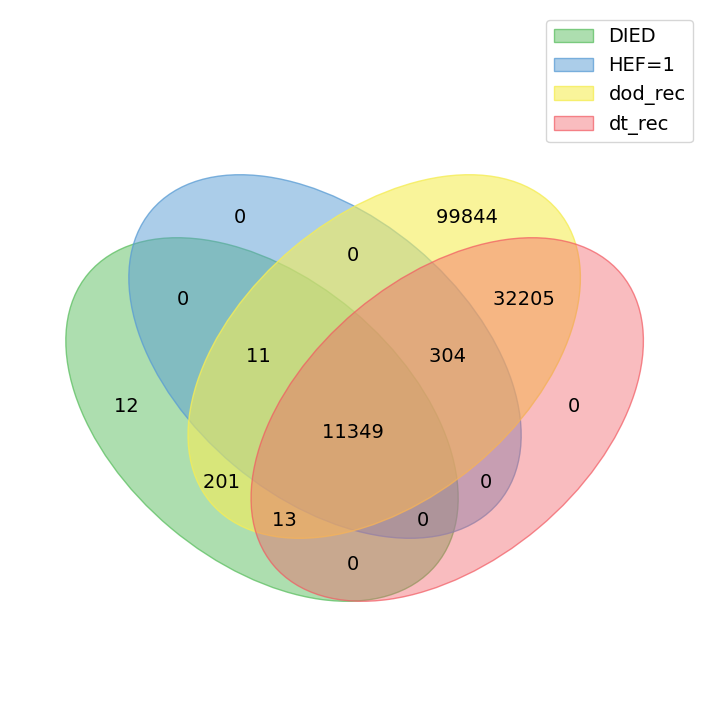

In [46]:
# 사망여부의 오류 확인 코드
def deathinfo_diagram(static_info):
    import venn 
    adms = static_info[['hadm_id', 'admittime', 'dischtime', 'dod', 'deathtime', 'discharge_location', 'hospital_expire_flag']].drop_duplicates()
    dloc = set(adms.index[adms["discharge_location"]=='DIED'])
    hef = set(adms.index[adms["hospital_expire_flag"]==1])
    dod = set(adms.index[~pd.isna(adms["dod"])])
    dt = set(adms.index[~pd.isna(adms["deathtime"])])

    labels = venn.get_labels([dloc, hef, dod, dt], fill=['number'])
    venn.venn4(labels, names=['DIED', 'HEF=1', 'dod_rec', 'dt_rec'])
    plt.show()

deathinfo_diagram(static_info)
plt.close()

In [47]:
tmp_df = static_info[['dod','deathtime']].dropna()
all(tmp_df['dod'].dt.date == tmp_df['deathtime'].dt.date)

True

In [48]:
'''시간오류 종류는 아래와 같음.(dht = deathtime으로 표기)
1. dod, dht < at 인 경우 => 오류이거나 이미 심정지 상태로 온 것을 나타낸다고 가정하더라도....
2. at < dod, dht 인데, dod나 dht 한참(3~4일) 뒤에 discharge 하는 경우 => 가능하지만, deathtime 혹은 dod까지의 기록만 사용해야 할 것으로 보임
3. dt < dod, dht 인경우: dod이면 out of hospital 가능/ dht면 시간오류 
    3.1 dod인데 max_df+1year 보다 이후: 오류

따라서 아래와 같이 코딩함.
=> dht와 dod 정보를 기반으로 죽음에 대한 정보를 나타내고, 아래와 같은 column을 이용해 표기함.

=> deathtype: survived, in, out, out_in_24hr, out_after_365d, error
=> death_adm: 이 admission에서 사망했는지 의미
=> deathtime: 가능한 경우, 시간까지 기록된 deathtime
=> is_dht_date: deathtime이 date까지만 신뢰할지 말지
=> certainty: certain, likely, even, unlikely, error ==> 오류가 없음 ~ 오류임
'''
def death_error_handling(x):
    import pandas as pd
    import datetime
    # static_info should be sorted in admittime
    adms = x[['hadm_id', 'admittime', 'dischtime', 'dod', 'deathtime', 'died', 'hospital_expire_flag']].drop_duplicates().sort_values('admittime').reset_index(drop=True)
    adms.columns = ['id', 'at', 'dt', 'dod', 'dht', 'died', 'hef']
    dod, dht = adms.loc[0, ['dod', 'dht']].values
    dod = pd.Timestamp(dod.date())
    hour = datetime.timedelta(hours=1)
    day = datetime.timedelta(days=1)
    
    return_df = pd.DataFrame(columns=['hadm_id', 'deathtype', 'death_adm', 'deathtime', 'is_dht_date', 'certainty'])
    return_df['hadm_id'] = adms['id'].copy()
    return_df['death_adm'] = 0

    try:
        if pd.isna(dod):
            return_df['deathtype'] = 'survived'
            if adms['died'].sum() >= 1 : 
                return_df['certainty'] = 'likely'
            else: 
                return_df['certainty'] = 'certain'

            return return_df
        
        elif pd.notna(dht):
            return_df['is_dht_date'] = 0
            return_df['deathtime'] = dht
            if (dht <= adms['at']).any(): 
                return_df['deathtype'] = 'error'
                return_df['certainty'] = 'error'

                return return_df
            
            else: 
                in_death = (adms['at'] < dht) & (dht <= adms['dt'])
                
                last_dt = adms['dt'].iloc[-1]
                out_death = ((last_dt+24*hour) < dht) & (dht <= (last_dt+365*day)) 
                out_in_24hr = (last_dt < dht) & (dht <= (last_dt+24*hour))
                out_after_365d = (last_dt+365*day) < dht

                if in_death.sum() >= 1: 
                    return_df['deathtype'] = 'in'
                    return_df.loc[in_death, 'death_adm'] = 1
                    
                    if in_death.sum() > 1:
                        return_df['certainty'] = 'error'
                    else:
                        died, hef = adms.loc[in_death, ['died', 'hef']].values.ravel()
                        
                        if (hef+died) == 2: 
                            return_df['certainty'] = 'certain'
                        elif (hef+died) == 1 :
                            return_df['certainty'] = 'likely'
                        else:
                            return_df['certainty'] = 'even'

                    return return_df
                    
                elif out_death:
                    return_df['deathtype'] = 'out'
                    errors = adms[['died', 'hef']].values.sum()

                    if errors >= 2: 
                        return_df['certainty'] = 'unlikely'
                    elif errors == 1 :
                        return_df['certainty'] = 'even'
                    else:
                        return_df['certainty'] = 'likely'

                    return return_df
                
                elif out_in_24hr:
                    return_df['deathtype'] = 'out_in_24hr'
                    errors = adms[['died', 'hef']].values.sum()
                    return_df['certainty'] = errors/(adms.shape[0]*2)

                    return return_df
                    
                elif out_after_365d:
                    return_df['deathtype'] = 'out_after_365d'
                    errors = adms[['died', 'hef']].values.sum()
                    return_df['certainty'] = errors/(adms.shape[0]*2)

                    return return_df
                
                else: 
                    raise LookupError
                
        else:
            return_df['is_dht_date'] = 1
            return_df['deathtime'] = dod
            adms['at'] = pd.to_datetime(adms['at'].dt.date)
            adms['dt'] = pd.to_datetime(adms['dt'].dt.date)

            if (dod < adms['at']).any(): 
                return_df['deathtype'] = 'error'
                return_df['certainty'] = 'error'

                return return_df
            
            else: 
                in_death = (adms['at'] <= dod) & (dod <= adms['dt'])
                
                last_dt = adms['dt'].iloc[-1]
                out_death = ((last_dt+day) < dod) & (dod <= (last_dt+365*day)) 
                out_in_24hr = (last_dt+day == dod)
                out_after_365d = (last_dt+365*day) < dod

                if in_death.sum() >= 1: 
                    return_df['deathtype'] = 'in'
                    return_df.loc[in_death, 'death_adm'] = 1
                    
                    if in_death.sum() > 1:
                        return_df['certainty'] = 'error'
                    else:
                        died, hef = adms.loc[in_death, ['died', 'hef']].values.ravel()
                        
                        if (hef+died) == 2: 
                            return_df['certainty'] = 'likely'
                        elif (hef+died) == 1 :
                            return_df['certainty'] = 'even'
                        else:
                            return_df['certainty'] = 'unlikely'

                    return return_df
                    
                elif out_death:
                    return_df['deathtype'] = 'out'
                    errors = adms[['died', 'hef']].values.sum()

                    if errors >= 2: 
                        return_df['certainty'] = 'even'
                    elif errors == 1 :
                        return_df['certainty'] = 'likely'
                    else:
                        return_df['certainty'] = 'certain'

                    return return_df
                
                elif out_in_24hr:
                    return_df['deathtype'] = 'out_in_24hr'
                    errors = adms[['died', 'hef']].values.sum()
                    return_df['certainty'] = errors/(adms.shape[0]*2)

                    return return_df
                    
                elif out_after_365d:
                    return_df['deathtype'] = 'out_after_365d'
                    errors = adms[['died', 'hef']].values.sum()
                    return_df['certainty'] = errors/(adms.shape[0]*2)

                    return return_df
                
                else: 
                    raise LookupError
    except:
        print(x['subject_id'].iloc[0])
        raise LookupError
tmp_df = static_info.groupby('subject_id').parallel_apply(death_error_handling)
tmp_df

/home/DAHS1/anaconda3/envs/backup_06/lib/python3.10/site-packages/pandarallel/data_types/dataframe_groupby.py:81: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  return df_groupby._wrap_applied_output(*args, not_indexed_same=mutated)


hadm_id deathtype  death_adm           deathtime is_dht_date  \
subject_id                                                                      
10000032   0  22595853.0       out          0 2180-09-09 00:00:00           1   
           1  22841357.0       out          0 2180-09-09 00:00:00           1   
           2  29079034.0       out          0 2180-09-09 00:00:00           1   
           3  25742920.0       out          0 2180-09-09 00:00:00           1   
10000068   0  25022803.0  survived          0                 NaT         NaN   
...                  ...       ...        ...                 ...         ...   
19999828   0  29734428.0  survived          0                 NaT         NaN   
           1  25744818.0  survived          0                 NaT         NaN   
19999840   0  26071774.0        in          0 2164-09-17 13:42:00           0   
           1  21033226.0        in          1 2164-09-17 13:42:00           0   
19999987   0  23865745.0  survived          0                 NaT         NaN   

             certainty  
subject_id              
10000032   0   certain  
           1   certain  
           2   certain  
           3   certain  
10000068   0   certain  
...                ...  
19999828   0   certain  
           1   certain  
19999840   0   certain  
           1   certain  
19999987   0   certain  

[543628 rows x 6 columns]

In [49]:
for col in tmp_df.columns:
    print(f'{col}: {(tmp_df.fillna(0).groupby("subject_id")[col].apply(np.unique).apply(len)>1).sum()}')

/tmp/ipykernel_2435937/3113233692.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  print(f'{col}: {(tmp_df.fillna(0).groupby("subject_id")[col].apply(np.unique).apply(len)>1).sum()}')


hadm_id: 99984


/tmp/ipykernel_2435937/3113233692.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  print(f'{col}: {(tmp_df.fillna(0).groupby("subject_id")[col].apply(np.unique).apply(len)>1).sum()}')


deathtype: 0


/tmp/ipykernel_2435937/3113233692.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  print(f'{col}: {(tmp_df.fillna(0).groupby("subject_id")[col].apply(np.unique).apply(len)>1).sum()}')


...

deathtime: 0


/tmp/ipykernel_2435937/3113233692.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  print(f'{col}: {(tmp_df.fillna(0).groupby("subject_id")[col].apply(np.unique).apply(len)>1).sum()}')


is_dht_date: 0


/tmp/ipykernel_2435937/3113233692.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  print(f'{col}: {(tmp_df.fillna(0).groupby("subject_id")[col].apply(np.unique).apply(len)>1).sum()}')


certainty: 0


In [50]:
static_info = static_info.drop(columns=['deathtime', 'dod', 'hospital_expire_flag', 'died']).set_index(['hadm_id']).join(tmp_df.reset_index(drop=True).set_index(['hadm_id']), how='left').reset_index()

## Race Handling

In [51]:
# races
tmp_df = static_info.groupby('subject_id')['race'].value_counts().unstack()
tmp_df = tmp_df[tmp_df>=1]
tmp_df.loc[pd.isna(tmp_df).sum(axis=1)<32] # 이런 케이스가 대체 왜 있는거지?

race,AMERICAN INDIAN/ALASKA NATIVE,ASIAN,ASIAN - ASIAN INDIAN,ASIAN - CHINESE,ASIAN - KOREAN,ASIAN - SOUTH EAST ASIAN,BLACK/AFRICAN,BLACK/AFRICAN AMERICAN,BLACK/CAPE VERDEAN,BLACK/CARIBBEAN ISLAND,HISPANIC OR LATINO,HISPANIC/LATINO - CENTRAL AMERICAN,HISPANIC/LATINO - COLUMBIAN,HISPANIC/LATINO - CUBAN,HISPANIC/LATINO - DOMINICAN,HISPANIC/LATINO - GUATEMALAN,HISPANIC/LATINO - HONDURAN,HISPANIC/LATINO - MEXICAN,HISPANIC/LATINO - PUERTO RICAN,HISPANIC/LATINO - SALVADORAN,MULTIPLE RACE/ETHNICITY,NATIVE HAWAIIAN OR OTHER PACIFIC ISLANDER,OTHER,PATIENT DECLINED TO ANSWER,PORTUGUESE,SOUTH AMERICAN,UNABLE TO OBTAIN,UNKNOWN,WHITE,WHITE - BRAZILIAN,WHITE - EASTERN EUROPEAN,WHITE - OTHER EUROPEAN,WHITE - RUSSIAN
subject_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
10002013,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,16.0,NaN,NaN,NaN,NaN
10002869,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,2.0,NaN,NaN,NaN,NaN
10003502,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,NaN,NaN,NaN,4.0
10003731,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,1.0,NaN
10004457,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19994379,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,3.0,NaN,NaN,NaN,NaN
19994592,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
19995320,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,1.0,NaN


In [52]:
# 이 환자들의 인종 정보는 명확하게 결정할 수 없다고 가정
# 더불어, AKI의 보수적 판단(쉽게 AKI로 평가)을 위해서 흑인 포함 다인종이더라도 흑인이 아니라고 하는 것이 더 타당하다고 결론지음
# 이에 하기 규칙 5.와 같이 판단함

In [53]:
race_mapping = {
    'ASIAN': 'ASIAN',
    'ASIAN - ASIAN INDIAN': 'ASIAN',
    'ASIAN - CHINESE': 'ASIAN', 
    'ASIAN - KOREAN': 'ASIAN', 
    'ASIAN - SOUTH EAST ASIAN': 'ASIAN',

    'BLACK/AFRICAN': 'BLACK', 
    'BLACK/AFRICAN AMERICAN': 'BLACK',
    'BLACK/CAPE VERDEAN': 'BLACK',
    'BLACK/CARIBBEAN ISLAND': 'BLACK', 

    'HISPANIC OR LATINO': 'HISPANIC/LATINO',
    'HISPANIC/LATINO - CENTRAL AMERICAN': 'HISPANIC/LATINO',
    'HISPANIC/LATINO - COLUMBIAN': 'HISPANIC/LATINO', 
    'HISPANIC/LATINO - CUBAN': 'HISPANIC/LATINO',
    'HISPANIC/LATINO - DOMINICAN': 'HISPANIC/LATINO', 
    'HISPANIC/LATINO - GUATEMALAN': 'HISPANIC/LATINO', 
    'HISPANIC/LATINO - HONDURAN': 'HISPANIC/LATINO',
    'HISPANIC/LATINO - MEXICAN': 'HISPANIC/LATINO', 
    'HISPANIC/LATINO - PUERTO RICAN': 'HISPANIC/LATINO', 
    'HISPANIC/LATINO - SALVADORAN': 'HISPANIC/LATINO',
    'PORTUGUESE': 'HISPANIC/LATINO',
    'SOUTH AMERICAN': 'HISPANIC/LATINO', 

    'WHITE': 'WHITE', 
    'WHITE - BRAZILIAN': 'WHITE', 
    'WHITE - EASTERN EUROPEAN': 'WHITE', 
    'WHITE - OTHER EUROPEAN': 'WHITE',
    'WHITE - RUSSIAN': 'WHITE', 

    'OTHER': 'OTHER',
    'AMERICAN INDIAN/ALASKA NATIVE': 'OTHER', 
    'MULTIPLE RACE/ETHNICITY': 'OTHER',
    'NATIVE HAWAIIAN OR OTHER PACIFIC ISLANDER': 'OTHER',

    'UNKNOWN': 'UNKNOWN',
    'UNABLE TO OBTAIN': 'UNKNOWN', 
    'PATIENT DECLINED TO ANSWER': 'UNKNOWN'
}

static_info['race'] = static_info['race'].map(race_mapping)

# 규칙 5 적용
tmp_df = static_info.groupby('subject_id')['race'].value_counts().unstack()
tmp_df = tmp_df[tmp_df>=1]
race_error_subjects = tmp_df.loc[pd.isna(tmp_df).sum(axis=1)<=(6-2)].index.tolist()# race가 여러개 기록된 환자들의 subject id
static_info.loc[static_info['subject_id'].isin(race_error_subjects), 'race'] = 'OTHER'

In [54]:
tmp_df = static_info.groupby('subject_id')['race'].value_counts().unstack()
tmp_df = tmp_df[tmp_df>=1]
tmp_df.loc[pd.notna(tmp_df).sum(axis=1)!=1] # 해결

race,ASIAN,BLACK,HISPANIC/LATINO,OTHER,UNKNOWN,WHITE
subject_id,,,,,,


## Age

In [55]:
# age missing value
pd.isna(static_info['anchor_age']).sum()

0

In [56]:
# intime 및 admittime에서의 나이를 계산함.
static_info.anchor_year = pd.to_datetime(static_info.anchor_year.astype(str)+'-01-01') # assume that all patients were born at Jan 1st
static_info['age_at_intime'] = (static_info['intime'] - static_info['anchor_year'])/datetime.timedelta(days = 365) + static_info['anchor_age']
static_info['age_at_admittime'] = (static_info['admittime'] - static_info['anchor_year'])/datetime.timedelta(days = 365) + static_info['anchor_age']

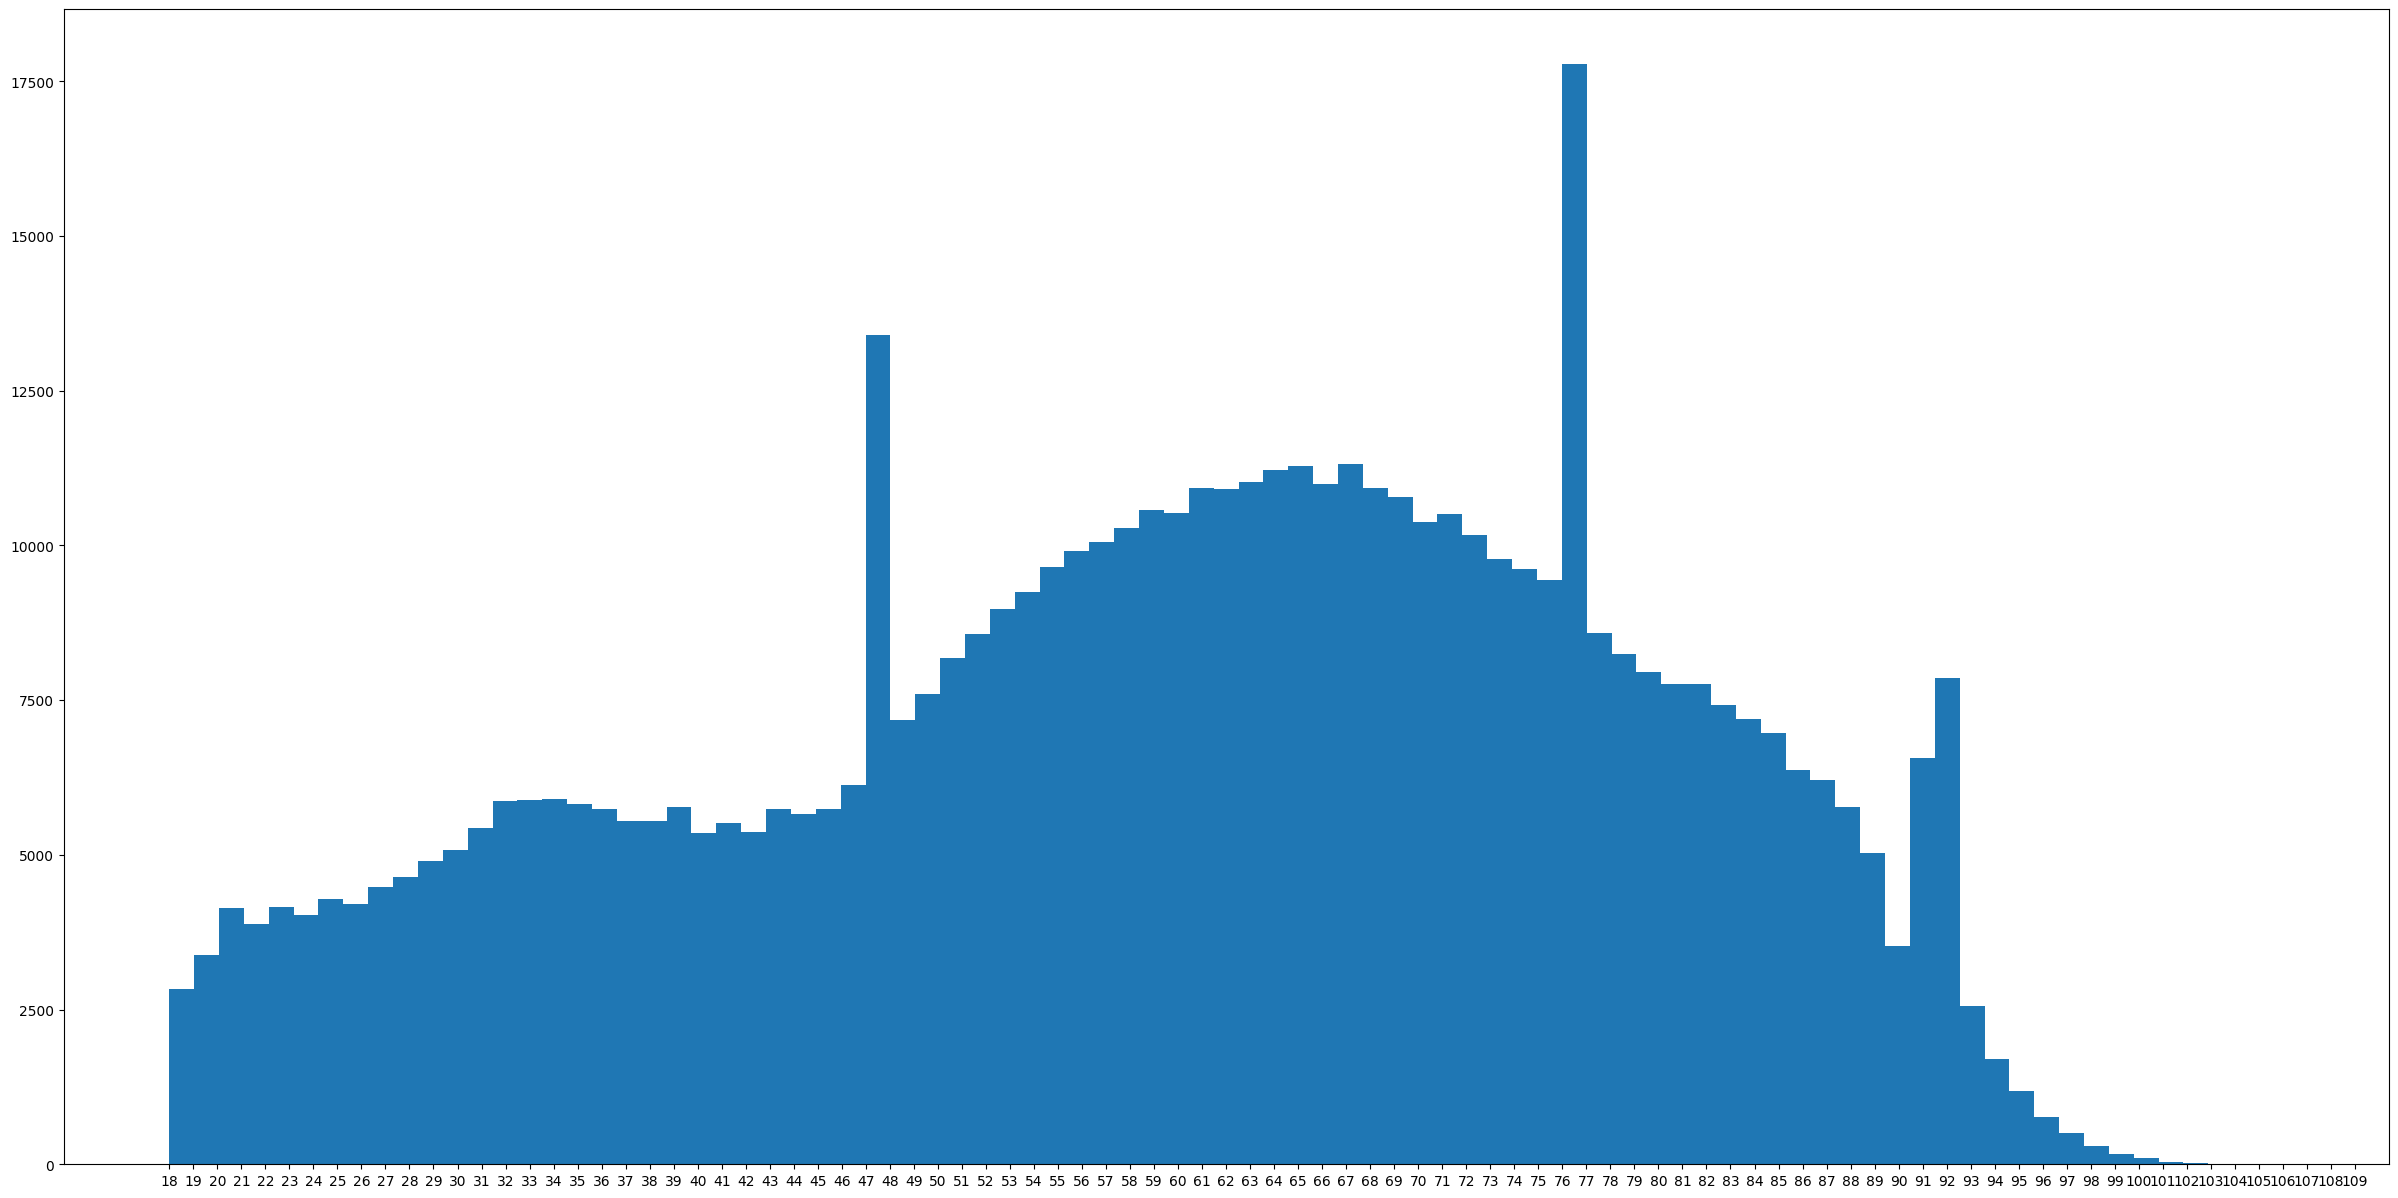

In [57]:
# age distribution
plt.figure(figsize=(30, 15))
plt.hist(round(static_info.age_at_admittime),85)
plt.xticks(np.arange(18, 110, 1))
plt.show()

In [58]:
col_names = ['stay_id', 'hadm_id', 'subject_id', 'intime', 'outtime', 'admittime', 'dischtime', 'edregtime', 'edouttime', 
             'first_careunit', 'last_careunit', 'admission_location', 'discharge_location', 
             'admission_type', 'insurance', 'language', 'marital_status', 
             'los', 'gender', 'anchor_age', 'anchor_year', 'anchor_year_group', 'age_at_intime', 'age_at_admittime', 'race', 
             'deathtype', 'death_adm', 'deathtime', 'is_dht_date', 'certainty']

static_info = static_info.sort_values(['subject_id', 'admittime', 'intime']).reset_index()

static_info = static_info[col_names]

In [59]:
# LOS check
a = ((static_info['outtime'].dropna()-static_info['intime']).dropna()/datetime.timedelta(days=1))
all(static_info['los'].dropna()-a < 1e-7)

True

In [ ]:
# static_info.to_csv('/home/DAHS1/gangmin/my_research/clinical_multimodal_learning/data/mimic/physionet.org/files/mimiciv/3.1/hosp/static_info.csv', index=False)

In [61]:
static_info

,stay_id,hadm_id,subject_id,intime,outtime,admittime,dischtime,edregtime,edouttime,first_careunit,last_careunit,admission_location,discharge_location,admission_type,insurance,language,marital_status,los,gender,anchor_age,anchor_year,anchor_year_group,age_at_intime,age_at_admittime,race,deathtype,death_adm,deathtime,is_dht_date,certainty
0,NaN,22595853.0,10000032,NaT,NaT,2180-05-06 22:23:00,2180-05-07 17:15:00,2180-05-06 19:17:00,2180-05-06 23:30:00,NaN,NaN,TRANSFER FROM HOSPITAL,HOME,URGENT,Medicaid,English,WIDOWED,NaN,F,52,2180-01-01,2014 - 2016,NaN,52.347761,WHITE,out,0,2180-09-09 00:00:00,1,certain
1,NaN,22841357.0,10000032,NaT,NaT,2180-06-26 18:27:00,2180-06-27 18:49:00,2180-06-26 15:54:00,2180-06-26 21:31:00,NaN,NaN,EMERGENCY ROOM,HOME,EW EMER.,Medicaid,English,WIDOWED,NaN,F,52,2180-01-01,2014 - 2016,NaN,52.487038,WHITE,out,0,2180-09-09 00:00:00,1,certain
2,39553978.0,29079034.0,10000032,2180-07-23 14:00:00,2180-07-23 23:50:47,2180-07-23 12:35:00,2180-07-25 17:55:00,2180-07-23 05:54:00,2180-07-23 14:00:00,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),EMERGENCY ROOM,HOME,EW EMER.,Medicaid,English,WIDOWED,0.410266,F,52,2180-01-01,2014 - 2016,52.560502,52.560341,WHITE,out,0,2180-09-09 00:00:00,1,certain
3,NaN,25742920.0,10000032,NaT,NaT,2180-08-05 23:44:00,2180-08-07 17:50:00,2180-08-05 20:58:00,2180-08-06 01:44:00,NaN,NaN,EMERGENCY ROOM,HOSPICE,EW EMER.,Medicaid,English,WIDOWED,NaN,F,52,2180-01-01,2014 - 2016,NaN,52.597230,WHITE,out,0,2180-09-09 00:00:00,1,certain
4,NaN,25022803.0,10000068,NaT,NaT,2160-03-03 23:16:00,2160-03-04 06:26:00,2160-03-03 21:55:00,2160-03-04 06:26:00,NaN,NaN,EMERGENCY ROOM,None,EU OBSERVATION,None,English,SINGLE,NaN,F,19,2160-01-01,2008 - 2010,NaN,19.172519,WHITE,survived,0,NaT,NaN,certain
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
552824,NaN,29734428.0,19999828,NaT,NaT,2147-07-18 16:23:00,2147-08-04 18:10:00,2147-07-17 17:18:00,2147-07-18 17:34:00,NaN,NaN,PHYSICIAN REFERRAL,HOME HEALTH CARE,EW EMER.,Medicaid,English,SINGLE,NaN,F,46,2147-01-01,2017 - 2019,NaN,46.544336,WHITE,survived,0,NaT,NaN,certain
552825,36075953.0,25744818.0,19999828,2149-01-08 18:12:00,2149-01-10 13:11:02,2149-01-08 16:44:00,2149-01-18 17:00:00,2149-01-08 09:11:00,2149-01-08 18:12:00,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),TRANSFER FROM HOSPITAL,HOME HEALTH CARE,EW EMER.,Medicaid,English,SINGLE,1.790995,F,46,2147-01-01,2017 - 2019,48.023995,48.023828,WHITE,survived,0,NaT,NaN,certain
552826,NaN,26071774.0,19999840,NaT,NaT,2164-07-25 00:27:00,2164-07-28 12:15:00,2164-07-24 21:16:00,2164-07-25 01:20:00,NaN,NaN,EMERGENCY ROOM,HOME,EW EMER.,Private,English,WIDOWED,NaN,M,58,2164-01-01,2008 - 2010,NaN,58.564435,WHITE,in,0,2164-09-17 13:42:00,0,certain
552827,38978960.0,21033226.0,19999840,2164-09-12 09:26:28,2164-09-17 16:35:15,2164-09-10 13:47:00,2164-09-17 16:35:15,2164-09-10 11:09:00,2164-09-10 14:46:00,Surgical Intensive Care Unit (SICU),Surgical Intensive Care Unit (SICU),EMERGENCY ROOM,DIED,EW EMER.,Private,English,WIDOWED,5.297766,M,58,2164-01-01,2008 - 2010,58.699708,58.694724,WHITE,in,1,2164-09-17 13:42:00,0,certain


In [62]:
static_info['death_adm'].value_counts()

death_adm
0    539239
1     13590
Name: count, dtype: int64

In [63]:
static_info.columns

Index(['stay_id', 'hadm_id', 'subject_id', 'intime', 'outtime', 'admittime',
       'dischtime', 'edregtime', 'edouttime', 'first_careunit',
       'last_careunit', 'admission_location', 'discharge_location',
       'admission_type', 'insurance', 'language', 'marital_status', 'los',
       'gender', 'anchor_age', 'anchor_year', 'anchor_year_group',
       'age_at_intime', 'age_at_admittime', 'race', 'deathtype', 'death_adm',
       'deathtime', 'is_dht_date', 'certainty'],
      dtype='object')

---

- CXR 이미지 한 장마다 “이 이미지가 어느 환자의 어느 입원 중, 가능하면 어느 ICU stay 중에 찍혔는지”를 시간 기준으로 붙이는 방식

In [10]:
static_info = pd.read_csv('/home/DAHS1/gangmin/my_research/clinical_multimodal_learning/data/mimic/physionet.org/files/mimiciv/3.1/hosp/static_info.csv')
static_info

,stay_id,hadm_id,subject_id,intime,outtime,admittime,dischtime,edregtime,edouttime,first_careunit,last_careunit,admission_location,discharge_location,admission_type,insurance,language,marital_status,los,gender,anchor_age,anchor_year,anchor_year_group,age_at_intime,age_at_admittime,race,deathtype,death_adm,deathtime,is_dht_date,certainty
0,NaN,22595853.0,10000032,NaN,NaN,2180-05-06 22:23:00,2180-05-07 17:15:00,2180-05-06 19:17:00,2180-05-06 23:30:00,NaN,NaN,TRANSFER FROM HOSPITAL,HOME,URGENT,Medicaid,English,WIDOWED,NaN,F,52,2180-01-01,2014 - 2016,NaN,52.347761,WHITE,out,0,2180-09-09 00:00:00,1.0,certain
1,NaN,22841357.0,10000032,NaN,NaN,2180-06-26 18:27:00,2180-06-27 18:49:00,2180-06-26 15:54:00,2180-06-26 21:31:00,NaN,NaN,EMERGENCY ROOM,HOME,EW EMER.,Medicaid,English,WIDOWED,NaN,F,52,2180-01-01,2014 - 2016,NaN,52.487038,WHITE,out,0,2180-09-09 00:00:00,1.0,certain
2,39553978.0,29079034.0,10000032,2180-07-23 14:00:00,2180-07-23 23:50:47,2180-07-23 12:35:00,2180-07-25 17:55:00,2180-07-23 05:54:00,2180-07-23 14:00:00,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),EMERGENCY ROOM,HOME,EW EMER.,Medicaid,English,WIDOWED,0.410266,F,52,2180-01-01,2014 - 2016,52.560502,52.560341,WHITE,out,0,2180-09-09 00:00:00,1.0,certain
3,NaN,25742920.0,10000032,NaN,NaN,2180-08-05 23:44:00,2180-08-07 17:50:00,2180-08-05 20:58:00,2180-08-06 01:44:00,NaN,NaN,EMERGENCY ROOM,HOSPICE,EW EMER.,Medicaid,English,WIDOWED,NaN,F,52,2180-01-01,2014 - 2016,NaN,52.597230,WHITE,out,0,2180-09-09 00:00:00,1.0,certain
4,NaN,25022803.0,10000068,NaN,NaN,2160-03-03 23:16:00,2160-03-04 06:26:00,2160-03-03 21:55:00,2160-03-04 06:26:00,NaN,NaN,EMERGENCY ROOM,NaN,EU OBSERVATION,NaN,English,SINGLE,NaN,F,19,2160-01-01,2008 - 2010,NaN,19.172519,WHITE,survived,0,NaN,NaN,certain
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
552824,NaN,29734428.0,19999828,NaN,NaN,2147-07-18 16:23:00,2147-08-04 18:10:00,2147-07-17 17:18:00,2147-07-18 17:34:00,NaN,NaN,PHYSICIAN REFERRAL,HOME HEALTH CARE,EW EMER.,Medicaid,English,SINGLE,NaN,F,46,2147-01-01,2017 - 2019,NaN,46.544336,WHITE,survived,0,NaN,NaN,certain
552825,36075953.0,25744818.0,19999828,2149-01-08 18:12:00,2149-01-10 13:11:02,2149-01-08 16:44:00,2149-01-18 17:00:00,2149-01-08 09:11:00,2149-01-08 18:12:00,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),TRANSFER FROM HOSPITAL,HOME HEALTH CARE,EW EMER.,Medicaid,English,SINGLE,1.790995,F,46,2147-01-01,2017 - 2019,48.023995,48.023828,WHITE,survived,0,NaN,NaN,certain
552826,NaN,26071774.0,19999840,NaN,NaN,2164-07-25 00:27:00,2164-07-28 12:15:00,2164-07-24 21:16:00,2164-07-25 01:20:00,NaN,NaN,EMERGENCY ROOM,HOME,EW EMER.,Private,English,WIDOWED,NaN,M,58,2164-01-01,2008 - 2010,NaN,58.564435,WHITE,in,0,2164-09-17 13:42:00,0.0,certain
552827,38978960.0,21033226.0,19999840,2164-09-12 09:26:28,2164-09-17 16:35:15,2164-09-10 13:47:00,2164-09-17 16:35:15,2164-09-10 11:09:00,2164-09-10 14:46:00,Surgical Intensive Care Unit (SICU),Surgical Intensive Care Unit (SICU),EMERGENCY ROOM,DIED,EW EMER.,Private,English,WIDOWED,5.297766,M,58,2164-01-01,2008 - 2010,58.699708,58.694724,WHITE,in,1,2164-09-17 13:42:00,0.0,certain


In [11]:
admission_intervals = (
    static_info[
        ['subject_id', 'hadm_id', 'admittime', 'dischtime']
    ]
    .drop_duplicates()
    .dropna(subset=['subject_id', 'hadm_id', 'admittime', 'dischtime'])
    .copy()
)

icu_intervals = (
    static_info[
        ['subject_id', 'hadm_id', 'stay_id', 'intime', 'outtime']
    ]
    .drop_duplicates()
    .dropna(subset=['subject_id', 'hadm_id', 'stay_id', 'intime', 'outtime'])
    .copy()
)

In [12]:
# # hadm 할당 함수
# def assign_hadm_id(row, df):
#     hadm_records = df[df['subject_id'] == row['subject_id']]

#     for idx, record in hadm_records.iterrows():
#         if record['admittime'] <= row['cxrtime'] < record['dischtime']:
#             return record['hadm_id']
#     return None

def assign_hadm_id(row, admission_intervals):
    records = admission_intervals[
        admission_intervals['subject_id'] == row['subject_id']
    ]

    matched = records[
        (records['admittime'] <= row['cxrtime']) &
        (row['cxrtime'] < records['dischtime'])
    ]

    if len(matched) == 0:
        return None

    if len(matched) > 1:
        return matched.iloc[0]['hadm_id']

    return matched.iloc[0]['hadm_id']

In [13]:
# # stay_id 할당 함수
# def assign_stay_id(row, df):
#     icu_records = df[(df['subject_id'] == row['subject_id']) & (df['hadm_id']==row['hadm_id'])]
    
#     for idx, record in icu_records.iterrows():
#         if record['intime'] <= row['cxrtime'] < record['outtime']: # icu니까 intime, outime 기준
#             return record['stay_id'] 
#     return None

def assign_stay_id(row, icu_intervals):
    if pd.isna(row['hadm_id']):
        return None

    records = icu_intervals[
        (icu_intervals['subject_id'] == row['subject_id']) &
        (icu_intervals['hadm_id'] == row['hadm_id'])
    ]

    matched = records[
        (records['intime'] <= row['cxrtime']) &
        (row['cxrtime'] < records['outtime'])
    ]

    if len(matched) == 0:
        return None

    if len(matched) > 1:
        return matched.iloc[0]['stay_id']

    return matched.iloc[0]['stay_id']

# 1. Extract ICU data with CXR

In [14]:
df_meta = df_mimic_cxr_metadata.copy()

df_meta['StudyDateForm'] = pd.to_datetime(df_meta['StudyDate'], format='%Y%m%d')
df_meta['StudyTimeForm'] = df_meta.apply(lambda x : '%#010.3f' % x['StudyTime'] ,1)
df_meta['StudyTimeForm'] = pd.to_datetime(df_meta['StudyTimeForm'], format='%H%M%S.%f').dt.time
df_meta['cxrtime'] = df_meta.apply(lambda r : dt.datetime.combine(r['StudyDateForm'],r['StudyTimeForm']), 1)

In [15]:
# cxr 파일별 경로 담겨 있음.
cxr_txt_path = pd.read_parquet("/home/DAHS1/gangmin/my_research/clinical_multimodal_learning/data/image_filenames.parquet")

In [16]:
cxr_txt_path.rename(columns={'text': 'file_path'}, inplace=True)

# dicom_id 추출: 마지막 '/' 이후 문자열
cxr_txt_path['dicom_id'] = cxr_txt_path['file_path'].str.extract(r'/([^/]+)\.jpg$')

In [17]:
cxr_txt_path

,file_path,dicom_id
0,files/p10/p10000032/s50414267/02aa804e-bde0afd...,02aa804e-bde0afdd-112c0b34-7bc16630-4e384014
1,files/p10/p10000032/s50414267/174413ec-4ec4c1f...,174413ec-4ec4c1f7-34ea26b7-c5f994f8-79ef1962
2,files/p10/p10000032/s53189527/2a2277a9-b0ded15...,2a2277a9-b0ded155-c0de8eb9-c124d10e-82c5caab
3,files/p10/p10000032/s53189527/e084de3b-be89b11...,e084de3b-be89b11e-20fe3f9f-9c8d8dfe-4cfd202c
4,files/p10/p10000032/s53911762/68b5c4b1-227d048...,68b5c4b1-227d0485-9cc38c3f-7b84ab51-4b472714
...,...,...
377105,files/p19/p19999733/s57132437/428e2c18-5721d8f...,428e2c18-5721d8f3-35a05001-36f3d080-9053b83c
377106,files/p19/p19999733/s57132437/58c403aa-35ff8bd...,58c403aa-35ff8bd9-73e39f54-8dc9cc5d-e0ec3fa9
377107,files/p19/p19999987/s55368167/58766883-376a15c...,58766883-376a15ce-3b323a28-6af950a0-16b793bd
377108,files/p19/p19999987/s58621812/7ba273af-3d290f8...,7ba273af-3d290f8d-e28d0ab4-484b7a86-7fc12b08


In [18]:
df_cxr = pd.merge(cxr_txt_path, df_meta, on='dicom_id')

In [19]:
df_cxr['ViewPosition'].value_counts()

ViewPosition
AP                147173
PA                 96161
LATERAL            82853
LL                 35133
PA LLD                 4
LAO                    3
RAO                    3
AP AXIAL               2
AP LLD                 2
XTABLE LATERAL         2
AP RLD                 2
SWIMMERS               1
PA RLD                 1
LPO                    1
Name: count, dtype: int64

In [20]:
df_cxr = df_cxr[['dicom_id', 'subject_id', 'study_id', 'ViewPosition', 'cxrtime']]
df_cxr = df_cxr[(df_cxr['ViewPosition']=='PA') | (df_cxr['ViewPosition']=='AP')].reset_index(drop=True) # ICU 환자는 AP만 사용하기도 하지만 일단 PA도 포함시킴. (24만장)

In [21]:
df_cxr

,dicom_id,subject_id,study_id,ViewPosition,cxrtime
0,02aa804e-bde0afdd-112c0b34-7bc16630-4e384014,10000032,50414267,PA,2180-05-06 21:30:14.531
1,2a2277a9-b0ded155-c0de8eb9-c124d10e-82c5caab,10000032,53189527,PA,2180-06-26 16:55:00.312
2,68b5c4b1-227d0485-9cc38c3f-7b84ab51-4b472714,10000032,53911762,AP,2180-07-23 08:05:56.875
3,fffabebf-74fd3a1f-673b6b41-96ec0ac9-2ab69818,10000032,53911762,AP,2180-07-23 08:05:56.875
4,ea030e7a-2e3b1346-bc518786-7a8fd698-f673b44c,10000032,56699142,AP,2180-08-05 23:44:24.765
...,...,...,...,...,...
243329,3fcd0406-9b111603-feae7033-96632b3a-111333e5,19999733,57132437,PA,2152-07-08 22:45:50.171
243330,428e2c18-5721d8f3-35a05001-36f3d080-9053b83c,19999733,57132437,PA,2152-07-08 22:45:50.171
243331,58766883-376a15ce-3b323a28-6af950a0-16b793bd,19999987,55368167,AP,2145-11-04 05:14:48.218
243332,7ba273af-3d290f8d-e28d0ab4-484b7a86-7fc12b08,19999987,58621812,AP,2145-11-02 20:28:09.234


In [22]:
df_mimic_cxr_image = pd.read_parquet("/home/DAHS1/gangmin/my_research/clinical_multimodal_learning/data/image_filenames.parquet")

In [23]:
if 'file_path' in df_mimic_cxr_image.columns:
    # 경로에서 폴더와 파일명 분리
    df_mimic_cxr_image['Img_Folder'] = df_mimic_cxr_image['file_path'].str.rsplit('/', n=1).str[0]
    df_mimic_cxr_image['Img_Filename'] = df_mimic_cxr_image['file_path'].str.rsplit('/', n=1).str[1]

    # dicom_id 추출
    df_mimic_cxr_image['dicom_id'] = df_mimic_cxr_image['Img_Filename'].str.split('.').str[0]
df_mimic_cxr_image['dicom_id'].duplicated().sum()

0

In [24]:
df_mimic_cxr_image

,file_path,Img_Folder,Img_Filename,dicom_id
0,files/p10/p10000032/s50414267/02aa804e-bde0afd...,files/p10/p10000032/s50414267,02aa804e-bde0afdd-112c0b34-7bc16630-4e384014.jpg,02aa804e-bde0afdd-112c0b34-7bc16630-4e384014
1,files/p10/p10000032/s50414267/174413ec-4ec4c1f...,files/p10/p10000032/s50414267,174413ec-4ec4c1f7-34ea26b7-c5f994f8-79ef1962.jpg,174413ec-4ec4c1f7-34ea26b7-c5f994f8-79ef1962
2,files/p10/p10000032/s53189527/2a2277a9-b0ded15...,files/p10/p10000032/s53189527,2a2277a9-b0ded155-c0de8eb9-c124d10e-82c5caab.jpg,2a2277a9-b0ded155-c0de8eb9-c124d10e-82c5caab
3,files/p10/p10000032/s53189527/e084de3b-be89b11...,files/p10/p10000032/s53189527,e084de3b-be89b11e-20fe3f9f-9c8d8dfe-4cfd202c.jpg,e084de3b-be89b11e-20fe3f9f-9c8d8dfe-4cfd202c
4,files/p10/p10000032/s53911762/68b5c4b1-227d048...,files/p10/p10000032/s53911762,68b5c4b1-227d0485-9cc38c3f-7b84ab51-4b472714.jpg,68b5c4b1-227d0485-9cc38c3f-7b84ab51-4b472714
...,...,...,...,...
377105,files/p19/p19999733/s57132437/428e2c18-5721d8f...,files/p19/p19999733/s57132437,428e2c18-5721d8f3-35a05001-36f3d080-9053b83c.jpg,428e2c18-5721d8f3-35a05001-36f3d080-9053b83c
377106,files/p19/p19999733/s57132437/58c403aa-35ff8bd...,files/p19/p19999733/s57132437,58c403aa-35ff8bd9-73e39f54-8dc9cc5d-e0ec3fa9.jpg,58c403aa-35ff8bd9-73e39f54-8dc9cc5d-e0ec3fa9
377107,files/p19/p19999987/s55368167/58766883-376a15c...,files/p19/p19999987/s55368167,58766883-376a15ce-3b323a28-6af950a0-16b793bd.jpg,58766883-376a15ce-3b323a28-6af950a0-16b793bd
377108,files/p19/p19999987/s58621812/7ba273af-3d290f8...,files/p19/p19999987/s58621812,7ba273af-3d290f8d-e28d0ab4-484b7a86-7fc12b08.jpg,7ba273af-3d290f8d-e28d0ab4-484b7a86-7fc12b08


- 13만장이 어디서 사라진건지 확인하기

In [25]:
icu_intervals.intime =  pd.to_datetime(icu_intervals.intime)
icu_intervals.outtime =  pd.to_datetime(icu_intervals.outtime)
admission_intervals.admittime =  pd.to_datetime(admission_intervals.admittime)
admission_intervals.dischtime =  pd.to_datetime(admission_intervals.dischtime)

In [26]:
if 'file_path' in df_mimic_cxr_image.columns:
    # 경로에서 폴더와 파일명 분리
    df_mimic_cxr_image['Img_Folder'] = df_mimic_cxr_image['file_path'].str.rsplit('/', n=1).str[0]
    df_mimic_cxr_image['Img_Filename'] = df_mimic_cxr_image['file_path'].str.rsplit('/', n=1).str[1]

    # dicom_id 추출
    df_mimic_cxr_image['dicom_id'] = df_mimic_cxr_image['Img_Filename'].str.split('.').str[0]

# 병합 및 후처리 
hosp_icu_cxr = df_cxr.merge(df_mimic_cxr_image[['Img_Folder', 'Img_Filename', 'dicom_id']], how='left', on='dicom_id')

# hadm_id, stay_id 할당
# hosp_icu_cxr['hadm_id'] = hosp_icu_cxr.apply(lambda row: assign_hadm_id(row, df_admissions), axis=1)
# hosp_icu_cxr['stay_id'] = hosp_icu_cxr.apply(lambda row: assign_stay_id(row, df_icustays), axis=1)
hosp_icu_cxr['hadm_id'] = hosp_icu_cxr.apply(lambda row: assign_hadm_id(row, admission_intervals), axis=1)
hosp_icu_cxr['stay_id'] = hosp_icu_cxr.apply(lambda row: assign_stay_id(row, icu_intervals), axis=1)


hosp_icu_cxr = hosp_icu_cxr.sort_values(by=['subject_id', 'hadm_id', 'stay_id'])

order = ['subject_id', 'hadm_id', 'stay_id', 'cxrtime', 'ViewPosition', 'dicom_id', 'Img_Folder', 'Img_Filename', 'study_id']
hosp_icu_cxr = hosp_icu_cxr[order]
hosp_icu_cxr = hosp_icu_cxr.reset_index(drop=True)

In [27]:
# after
hosp_icu_cxr

,subject_id,hadm_id,stay_id,cxrtime,ViewPosition,dicom_id,Img_Folder,Img_Filename,study_id
0,10000032,25742920.0,NaN,2180-08-05 23:44:24.765,AP,ea030e7a-2e3b1346-bc518786-7a8fd698-f673b44c,files/p10/p10000032/s56699142,ea030e7a-2e3b1346-bc518786-7a8fd698-f673b44c.jpg,56699142
1,10000032,NaN,NaN,2180-05-06 21:30:14.531,PA,02aa804e-bde0afdd-112c0b34-7bc16630-4e384014,files/p10/p10000032/s50414267,02aa804e-bde0afdd-112c0b34-7bc16630-4e384014.jpg,50414267
2,10000032,NaN,NaN,2180-06-26 16:55:00.312,PA,2a2277a9-b0ded155-c0de8eb9-c124d10e-82c5caab,files/p10/p10000032/s53189527,2a2277a9-b0ded155-c0de8eb9-c124d10e-82c5caab.jpg,53189527
3,10000032,NaN,NaN,2180-07-23 08:05:56.875,AP,68b5c4b1-227d0485-9cc38c3f-7b84ab51-4b472714,files/p10/p10000032/s53911762,68b5c4b1-227d0485-9cc38c3f-7b84ab51-4b472714.jpg,53911762
4,10000032,NaN,NaN,2180-07-23 08:05:56.875,AP,fffabebf-74fd3a1f-673b6b41-96ec0ac9-2ab69818,files/p10/p10000032/s53911762,fffabebf-74fd3a1f-673b6b41-96ec0ac9-2ab69818.jpg,53911762
...,...,...,...,...,...,...,...,...,...
243329,19999733,NaN,NaN,2152-07-08 22:45:50.171,PA,3fcd0406-9b111603-feae7033-96632b3a-111333e5,files/p19/p19999733/s57132437,3fcd0406-9b111603-feae7033-96632b3a-111333e5.jpg,57132437
243330,19999733,NaN,NaN,2152-07-08 22:45:50.171,PA,428e2c18-5721d8f3-35a05001-36f3d080-9053b83c,files/p19/p19999733/s57132437,428e2c18-5721d8f3-35a05001-36f3d080-9053b83c.jpg,57132437
243331,19999987,23865745.0,36195440.0,2145-11-04 05:14:48.218,AP,58766883-376a15ce-3b323a28-6af950a0-16b793bd,files/p19/p19999987/s55368167,58766883-376a15ce-3b323a28-6af950a0-16b793bd.jpg,55368167
243332,19999987,23865745.0,36195440.0,2145-11-03 05:05:07.625,AP,1a1fe7e3-cbac5d93-b339aeda-86bb86b5-4f31e82e,files/p19/p19999987/s58971208,1a1fe7e3-cbac5d93-b339aeda-86bb86b5-4f31e82e.jpg,58971208


In [28]:
# hosp_icu_cxr.to_feather("/home/DAHS1/gangmin/my_research/clinical_multimodal_learning/data/full_data/mimic_3_1/hosp_icu_cxr.ftr")

In [29]:
hosp_icu_cxr = pd.read_feather("/home/DAHS1/gangmin/my_research/clinical_multimodal_learning/data/full_data/mimic_3_1/hosp_icu_cxr.ftr")

In [30]:
df_mimic_cxr_chexpert

,subject_id,study_id,Atelectasis,Cardiomegaly,Consolidation,Edema,Enlarged Cardiomediastinum,Fracture,Lung Lesion,Lung Opacity,No Finding,Pleural Effusion,Pleural Other,Pneumonia,Pneumothorax,Support Devices
0,10000032,50414267,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN
1,10000032,53189527,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN
2,10000032,53911762,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN
3,10000032,56699142,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN
4,10000764,57375967,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
227822,19999442,58708861,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,1.0
227823,19999733,57132437,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN
227824,19999987,55368167,1.0,-1.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,0.0,NaN,NaN,0.0,NaN
227825,19999987,58621812,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0


In [31]:
print(df_mimic_cxr_chexpert['study_id'].nunique()) # label data
print(df_mimic_cxr_metadata['study_id'].nunique()) # metadata 원래는 37만 장인데, study_id 기준으로는 227835장임.
# 즉 하나의 study_id에 중복되는 이미지가 여러 장 촬영되어 있음 (이 부분에서 13만 장 사라짐)

227827
227835


In [32]:
# 라벨 붙이기
hosp_icu_cxr = hosp_icu_cxr.merge(df_mimic_cxr_chexpert, on=['subject_id', 'study_id'], how='left')
hosp_icu_cxr

,subject_id,hadm_id,stay_id,cxrtime,ViewPosition,dicom_id,Img_Folder,Img_Filename,study_id,Atelectasis,Cardiomegaly,Consolidation,Edema,Enlarged Cardiomediastinum,Fracture,Lung Lesion,Lung Opacity,No Finding,Pleural Effusion,Pleural Other,Pneumonia,Pneumothorax,Support Devices
0,10000032,25742920.0,NaN,2180-08-05 23:44:24.765,AP,ea030e7a-2e3b1346-bc518786-7a8fd698-f673b44c,files/p10/p10000032/s56699142,ea030e7a-2e3b1346-bc518786-7a8fd698-f673b44c.jpg,56699142,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN
1,10000032,NaN,NaN,2180-05-06 21:30:14.531,PA,02aa804e-bde0afdd-112c0b34-7bc16630-4e384014,files/p10/p10000032/s50414267,02aa804e-bde0afdd-112c0b34-7bc16630-4e384014.jpg,50414267,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN
2,10000032,NaN,NaN,2180-06-26 16:55:00.312,PA,2a2277a9-b0ded155-c0de8eb9-c124d10e-82c5caab,files/p10/p10000032/s53189527,2a2277a9-b0ded155-c0de8eb9-c124d10e-82c5caab.jpg,53189527,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN
3,10000032,NaN,NaN,2180-07-23 08:05:56.875,AP,68b5c4b1-227d0485-9cc38c3f-7b84ab51-4b472714,files/p10/p10000032/s53911762,68b5c4b1-227d0485-9cc38c3f-7b84ab51-4b472714.jpg,53911762,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN
4,10000032,NaN,NaN,2180-07-23 08:05:56.875,AP,fffabebf-74fd3a1f-673b6b41-96ec0ac9-2ab69818,files/p10/p10000032/s53911762,fffabebf-74fd3a1f-673b6b41-96ec0ac9-2ab69818.jpg,53911762,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
243329,19999733,NaN,NaN,2152-07-08 22:45:50.171,PA,3fcd0406-9b111603-feae7033-96632b3a-111333e5,files/p19/p19999733/s57132437,3fcd0406-9b111603-feae7033-96632b3a-111333e5.jpg,57132437,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN
243330,19999733,NaN,NaN,2152-07-08 22:45:50.171,PA,428e2c18-5721d8f3-35a05001-36f3d080-9053b83c,files/p19/p19999733/s57132437,428e2c18-5721d8f3-35a05001-36f3d080-9053b83c.jpg,57132437,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN
243331,19999987,23865745.0,36195440.0,2145-11-04 05:14:48.218,AP,58766883-376a15ce-3b323a28-6af950a0-16b793bd,files/p19/p19999987/s55368167,58766883-376a15ce-3b323a28-6af950a0-16b793bd.jpg,55368167,1.0,-1.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,0.0,NaN,NaN,0.0,NaN
243332,19999987,23865745.0,36195440.0,2145-11-03 05:05:07.625,AP,1a1fe7e3-cbac5d93-b339aeda-86bb86b5-4f31e82e,files/p19/p19999987/s58971208,1a1fe7e3-cbac5d93-b339aeda-86bb86b5-4f31e82e.jpg,58971208,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


- stay_id 비어있는 경우 버렸는데, assign stay_id 함수가 원활하게 작동한 것이 아닌지에 대해서도 확인을 해야함. 5만장대로 줄어버리니까

- Sample check 1

In [33]:
hosp_icu_cxr[hosp_icu_cxr['subject_id']==10000032]

,subject_id,hadm_id,stay_id,cxrtime,ViewPosition,dicom_id,Img_Folder,Img_Filename,study_id,Atelectasis,Cardiomegaly,Consolidation,Edema,Enlarged Cardiomediastinum,Fracture,Lung Lesion,Lung Opacity,No Finding,Pleural Effusion,Pleural Other,Pneumonia,Pneumothorax,Support Devices
0,10000032,25742920.0,NaN,2180-08-05 23:44:24.765,AP,ea030e7a-2e3b1346-bc518786-7a8fd698-f673b44c,files/p10/p10000032/s56699142,ea030e7a-2e3b1346-bc518786-7a8fd698-f673b44c.jpg,56699142,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN
1,10000032,NaN,NaN,2180-05-06 21:30:14.531,PA,02aa804e-bde0afdd-112c0b34-7bc16630-4e384014,files/p10/p10000032/s50414267,02aa804e-bde0afdd-112c0b34-7bc16630-4e384014.jpg,50414267,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN
2,10000032,NaN,NaN,2180-06-26 16:55:00.312,PA,2a2277a9-b0ded155-c0de8eb9-c124d10e-82c5caab,files/p10/p10000032/s53189527,2a2277a9-b0ded155-c0de8eb9-c124d10e-82c5caab.jpg,53189527,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN
3,10000032,NaN,NaN,2180-07-23 08:05:56.875,AP,68b5c4b1-227d0485-9cc38c3f-7b84ab51-4b472714,files/p10/p10000032/s53911762,68b5c4b1-227d0485-9cc38c3f-7b84ab51-4b472714.jpg,53911762,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN
4,10000032,NaN,NaN,2180-07-23 08:05:56.875,AP,fffabebf-74fd3a1f-673b6b41-96ec0ac9-2ab69818,files/p10/p10000032/s53911762,fffabebf-74fd3a1f-673b6b41-96ec0ac9-2ab69818.jpg,53911762,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN


In [34]:
# static_info에서 stay_id 비교하면서 직접 확인할 것
static_info[static_info['subject_id']==10000032]
# 9시간 정도 입실했는데 cxrtime이랑은 불일치하는군 -> good!

,stay_id,hadm_id,subject_id,intime,outtime,admittime,dischtime,edregtime,edouttime,first_careunit,last_careunit,admission_location,discharge_location,admission_type,insurance,language,marital_status,los,gender,anchor_age,anchor_year,anchor_year_group,age_at_intime,age_at_admittime,race,deathtype,death_adm,deathtime,is_dht_date,certainty
0,NaN,22595853.0,10000032,NaN,NaN,2180-05-06 22:23:00,2180-05-07 17:15:00,2180-05-06 19:17:00,2180-05-06 23:30:00,NaN,NaN,TRANSFER FROM HOSPITAL,HOME,URGENT,Medicaid,English,WIDOWED,NaN,F,52,2180-01-01,2014 - 2016,NaN,52.347761,WHITE,out,0,2180-09-09 00:00:00,1.0,certain
1,NaN,22841357.0,10000032,NaN,NaN,2180-06-26 18:27:00,2180-06-27 18:49:00,2180-06-26 15:54:00,2180-06-26 21:31:00,NaN,NaN,EMERGENCY ROOM,HOME,EW EMER.,Medicaid,English,WIDOWED,NaN,F,52,2180-01-01,2014 - 2016,NaN,52.487038,WHITE,out,0,2180-09-09 00:00:00,1.0,certain
2,39553978.0,29079034.0,10000032,2180-07-23 14:00:00,2180-07-23 23:50:47,2180-07-23 12:35:00,2180-07-25 17:55:00,2180-07-23 05:54:00,2180-07-23 14:00:00,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),EMERGENCY ROOM,HOME,EW EMER.,Medicaid,English,WIDOWED,0.410266,F,52,2180-01-01,2014 - 2016,52.560502,52.560341,WHITE,out,0,2180-09-09 00:00:00,1.0,certain
3,NaN,25742920.0,10000032,NaN,NaN,2180-08-05 23:44:00,2180-08-07 17:50:00,2180-08-05 20:58:00,2180-08-06 01:44:00,NaN,NaN,EMERGENCY ROOM,HOSPICE,EW EMER.,Medicaid,English,WIDOWED,NaN,F,52,2180-01-01,2014 - 2016,NaN,52.597230,WHITE,out,0,2180-09-09 00:00:00,1.0,certain


- Sample check 2

In [35]:
hosp_icu_cxr[hosp_icu_cxr['stay_id']==36195440]

,subject_id,hadm_id,stay_id,cxrtime,ViewPosition,dicom_id,Img_Folder,Img_Filename,study_id,Atelectasis,Cardiomegaly,Consolidation,Edema,Enlarged Cardiomediastinum,Fracture,Lung Lesion,Lung Opacity,No Finding,Pleural Effusion,Pleural Other,Pneumonia,Pneumothorax,Support Devices
243331,19999987,23865745.0,36195440.0,2145-11-04 05:14:48.218,AP,58766883-376a15ce-3b323a28-6af950a0-16b793bd,files/p19/p19999987/s55368167,58766883-376a15ce-3b323a28-6af950a0-16b793bd.jpg,55368167,1.0,-1.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,0.0,NaN,NaN,0.0,NaN
243332,19999987,23865745.0,36195440.0,2145-11-03 05:05:07.625,AP,1a1fe7e3-cbac5d93-b339aeda-86bb86b5-4f31e82e,files/p19/p19999987/s58971208,1a1fe7e3-cbac5d93-b339aeda-86bb86b5-4f31e82e.jpg,58971208,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [36]:
static_info[static_info['subject_id']==19999987]
# stay_id는 멀쩡하게 할당된 듯?

,stay_id,hadm_id,subject_id,intime,outtime,admittime,dischtime,edregtime,edouttime,first_careunit,last_careunit,admission_location,discharge_location,admission_type,insurance,language,marital_status,los,gender,anchor_age,anchor_year,anchor_year_group,age_at_intime,age_at_admittime,race,deathtype,death_adm,deathtime,is_dht_date,certainty
552828,36195440.0,23865745.0,19999987,2145-11-02 22:59:00,2145-11-04 21:29:30,2145-11-02 21:38:00,2145-11-11 12:57:00,2145-11-02 19:28:00,2145-11-02 22:59:00,Trauma SICU (TSICU),Trauma SICU (TSICU),EMERGENCY ROOM,REHAB,EW EMER.,Medicaid,English,NaN,1.937847,F,57,2145-01-01,2011 - 2013,57.83824,57.838086,UNKNOWN,survived,0,NaN,NaN,certain


In [37]:
# 다행히도 intime이 결측인데 stay_id가 할당된 경우는 없음
static_info[(static_info['intime'].isnull()) & (static_info['stay_id'].notnull())]

,stay_id,hadm_id,subject_id,intime,outtime,admittime,dischtime,edregtime,edouttime,first_careunit,last_careunit,admission_location,discharge_location,admission_type,insurance,language,marital_status,los,gender,anchor_age,anchor_year,anchor_year_group,age_at_intime,age_at_admittime,race,deathtype,death_adm,deathtime,is_dht_date,certainty


In [38]:
# 반대도 마찬가지임
static_info[(static_info['intime'].notnull()) & (static_info['stay_id'].isnull())]

,stay_id,hadm_id,subject_id,intime,outtime,admittime,dischtime,edregtime,edouttime,first_careunit,last_careunit,admission_location,discharge_location,admission_type,insurance,language,marital_status,los,gender,anchor_age,anchor_year,anchor_year_group,age_at_intime,age_at_admittime,race,deathtype,death_adm,deathtime,is_dht_date,certainty


In [39]:
# stay_id가 정상적으로 할당된 것으로 봐야할 듯!
hosp_icu_cxr

,subject_id,hadm_id,stay_id,cxrtime,ViewPosition,dicom_id,Img_Folder,Img_Filename,study_id,Atelectasis,Cardiomegaly,Consolidation,Edema,Enlarged Cardiomediastinum,Fracture,Lung Lesion,Lung Opacity,No Finding,Pleural Effusion,Pleural Other,Pneumonia,Pneumothorax,Support Devices
0,10000032,25742920.0,NaN,2180-08-05 23:44:24.765,AP,ea030e7a-2e3b1346-bc518786-7a8fd698-f673b44c,files/p10/p10000032/s56699142,ea030e7a-2e3b1346-bc518786-7a8fd698-f673b44c.jpg,56699142,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN
1,10000032,NaN,NaN,2180-05-06 21:30:14.531,PA,02aa804e-bde0afdd-112c0b34-7bc16630-4e384014,files/p10/p10000032/s50414267,02aa804e-bde0afdd-112c0b34-7bc16630-4e384014.jpg,50414267,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN
2,10000032,NaN,NaN,2180-06-26 16:55:00.312,PA,2a2277a9-b0ded155-c0de8eb9-c124d10e-82c5caab,files/p10/p10000032/s53189527,2a2277a9-b0ded155-c0de8eb9-c124d10e-82c5caab.jpg,53189527,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN
3,10000032,NaN,NaN,2180-07-23 08:05:56.875,AP,68b5c4b1-227d0485-9cc38c3f-7b84ab51-4b472714,files/p10/p10000032/s53911762,68b5c4b1-227d0485-9cc38c3f-7b84ab51-4b472714.jpg,53911762,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN
4,10000032,NaN,NaN,2180-07-23 08:05:56.875,AP,fffabebf-74fd3a1f-673b6b41-96ec0ac9-2ab69818,files/p10/p10000032/s53911762,fffabebf-74fd3a1f-673b6b41-96ec0ac9-2ab69818.jpg,53911762,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
243329,19999733,NaN,NaN,2152-07-08 22:45:50.171,PA,3fcd0406-9b111603-feae7033-96632b3a-111333e5,files/p19/p19999733/s57132437,3fcd0406-9b111603-feae7033-96632b3a-111333e5.jpg,57132437,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN
243330,19999733,NaN,NaN,2152-07-08 22:45:50.171,PA,428e2c18-5721d8f3-35a05001-36f3d080-9053b83c,files/p19/p19999733/s57132437,428e2c18-5721d8f3-35a05001-36f3d080-9053b83c.jpg,57132437,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN
243331,19999987,23865745.0,36195440.0,2145-11-04 05:14:48.218,AP,58766883-376a15ce-3b323a28-6af950a0-16b793bd,files/p19/p19999987/s55368167,58766883-376a15ce-3b323a28-6af950a0-16b793bd.jpg,55368167,1.0,-1.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,0.0,NaN,NaN,0.0,NaN
243332,19999987,23865745.0,36195440.0,2145-11-03 05:05:07.625,AP,1a1fe7e3-cbac5d93-b339aeda-86bb86b5-4f31e82e,files/p19/p19999987/s58971208,1a1fe7e3-cbac5d93-b339aeda-86bb86b5-4f31e82e.jpg,58971208,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [40]:
# 병원 입원 안한 촬영 이력 모두 합쳐서 24만 장
print(len(hosp_icu_cxr[hosp_icu_cxr['subject_id'].notnull()]))

# 병동 입원하고 나서 11만 장. 즉 입원 안하고 13만 여 장 촬영한 것으로 보임
print(len(hosp_icu_cxr[hosp_icu_cxr['hadm_id'].notnull()]))

243334
119108


In [41]:
# 여기서 stay_id 없는 경우는 제외하고 이미지 추출하면 icu cxr 촬영만 추출 가능
df_cxr = hosp_icu_cxr[hosp_icu_cxr['stay_id'].notnull()].reset_index(drop=True)
df_cxr

,subject_id,hadm_id,stay_id,cxrtime,ViewPosition,dicom_id,Img_Folder,Img_Filename,study_id,Atelectasis,Cardiomegaly,Consolidation,Edema,Enlarged Cardiomediastinum,Fracture,Lung Lesion,Lung Opacity,No Finding,Pleural Effusion,Pleural Other,Pneumonia,Pneumothorax,Support Devices
0,10001884,26184834.0,37510196.0,2131-01-15 04:45:09.078,AP,469d0d94-3dad5068-efac76ef-a28cc502-68fe6275,files/p10/p10001884/s50376803,469d0d94-3dad5068-efac76ef-a28cc502-68fe6275.jpg,50376803,NaN,1.0,-1.0,NaN,NaN,NaN,NaN,-1.0,NaN,NaN,NaN,NaN,0.0,1.0
1,10001884,26184834.0,37510196.0,2131-01-12 04:56:56.359,AP,7b25b3ed-e780a527-319cb7b3-02d5d071-f1cddee9,files/p10/p10001884/s50712381,7b25b3ed-e780a527-319cb7b3-02d5d071-f1cddee9.jpg,50712381,NaN,1.0,NaN,1.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,0.0,1.0
2,10001884,26184834.0,37510196.0,2131-01-13 04:49:18.484,AP,c1ad3e27-62d05ef8-95018fe3-b8bcfe4b-bbba0e1f,files/p10/p10001884/s56722923,c1ad3e27-62d05ef8-95018fe3-b8bcfe4b-bbba0e1f.jpg,56722923,NaN,1.0,NaN,1.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,0.0,1.0
3,10001884,26184834.0,37510196.0,2131-01-14 10:34:28.765,AP,9b1a8a51-2b8e4a04-1719059d-aa6bc888-7ace612b,files/p10/p10001884/s59305618,9b1a8a51-2b8e4a04-1719059d-aa6bc888-7ace612b.jpg,59305618,NaN,NaN,NaN,-1.0,NaN,NaN,NaN,1.0,NaN,-1.0,NaN,-1.0,NaN,1.0
4,10002428,23473524.0,35479615.0,2156-05-18 02:47:37.203,AP,7f51d06c-dad16fe6-ff21a632-edc5a3e6-ffa387bf,files/p10/p10002428/s50292543,7f51d06c-dad16fe6-ff21a632-edc5a3e6-ffa387bf.jpg,50292543,1.0,NaN,NaN,1.0,NaN,NaN,NaN,1.0,NaN,1.0,NaN,NaN,NaN,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
57930,19999287,20175828.0,35165301.0,2197-08-07 09:06:37.796,AP,f7e95a22-cb958055-47114ddf-38532ef4-b4c172d5,files/p19/p19999287/s52519175,f7e95a22-cb958055-47114ddf-38532ef4-b4c172d5.jpg,52519175,0.0,NaN,1.0,NaN,NaN,NaN,1.0,1.0,NaN,NaN,NaN,NaN,0.0,1.0
57931,19999287,20175828.0,35165301.0,2197-08-05 09:37:46.343,AP,2eb70dfe-52fa728e-a36e09be-ec0ed3cf-0a2ea7f0,files/p19/p19999287/s58938059,2eb70dfe-52fa728e-a36e09be-ec0ed3cf-0a2ea7f0.jpg,58938059,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN
57932,19999442,26785317.0,32336619.0,2148-11-19 22:47:03.375,AP,16b6c70f-6d36bd77-89d2fef4-9c4b8b0a-79c69135,files/p19/p19999442/s58708861,16b6c70f-6d36bd77-89d2fef4-9c4b8b0a-79c69135.jpg,58708861,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,1.0
57933,19999987,23865745.0,36195440.0,2145-11-04 05:14:48.218,AP,58766883-376a15ce-3b323a28-6af950a0-16b793bd,files/p19/p19999987/s55368167,58766883-376a15ce-3b323a28-6af950a0-16b793bd.jpg,55368167,1.0,-1.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,0.0,NaN,NaN,0.0,NaN


In [42]:
print("ICU 체류 내 활용 가능 cxr 수: ", len(df_cxr))
print("ICU 체류 중 cxr 촬영 이력 있는 subject_id 수: ", df_cxr['subject_id'].nunique())
print("ICU 체류 중 cxr 촬영 이력 있는 stay_id 수: ", df_cxr['stay_id'].nunique())

print("\nICU 체류 중 cxr 촬영 viewpoint 분포: ", df_cxr['ViewPosition'].value_counts())
# ICU 내 촬영은 57935장으로 급감. 아쉽게 적긴 함

ICU 체류 내 활용 가능 cxr 수:  57935
ICU 체류 중 cxr 촬영 이력 있는 subject_id 수:  10863
ICU 체류 중 cxr 촬영 이력 있는 stay_id 수:  14144

ICU 체류 중 cxr 촬영 viewpoint 분포:  ViewPosition
AP    57690
PA      245
Name: count, dtype: int64


In [43]:
backup_cxr = df_cxr.copy()

<!-- --- -->

# 2. Past History

In [44]:
# diagnoses_icd_df = pd.read_parquet("C:/Users/gangmin/dahs/data/mimic/hosp/parquet/diagnoses_icd.parquet")
# d_icd_diagnoses_df = pd.read_parquet("C:/Users/gangmin/dahs/data/mimic/hosp/parquet/d_icd_diagnoses.parquet")

In [45]:
# d_icd_diagnoses_df[d_icd_diagnoses_df['icd_code']=='J80']

In [46]:
# d_icd_diagnoses_df[d_icd_diagnoses_df['icd_code']=='51882']

In [47]:
# print(d_icd_diagnoses_df[d_icd_diagnoses_df['icd_code']=='51882']['long_title'])

In [48]:
# df = diagnoses_icd_df.copy()
# df['icd_code'] = df['icd_code'].str.upper()

<!-- | CM         | Disease Category                  | ICD-9 | ICD-10  |
|------------|-----------------------------------|-------|---------|
| Circulatory| Chronic rheumatic heart diseases | 393-398 | I05–I09 |
| Circulatory| Ischemic heart diseases          | 410-414 | I20–I25 |
| Circulatory| Other forms of heart disease     | 420-429 | I30–I5A |
| Respiratory| Other respiratory diseases principally affecting the interstitium | 516, 518 | J80-J84 |
| Respiratory| Influenza and pneumonia | 480-488 | J09-J18 |
| Respiratory| Suppurative and necrotic conditions of the lower respiratory tract | 510, 513 | J85-J86 | -->

In [49]:
# CIRCULATORY_PREFIX = {
#     9: [
#         '393', '394', '395', '396', '397', '398',
#         '410', '411', '412', '413', '414',
#         '420', '421', '422', '423', '424', '425', '426', '427', '428', '429'
#     ],

#     10: [
#         'I05', 'I06', 'I07', 'I08', 'I09',
#         'I20', 'I21', 'I22', 'I23', 'I24', 'I25',
#         'I30', 'I31', 'I32', 'I33', 'I34', 'I35', 'I36', 'I37',
#         'I40', 'I41', 'I42', 'I43', 'I44', 'I45', 'I46', 'I47', 'I48', 'I49',
#         'I50', 'I51', 'I52', 'I5A'
#     ]
# }

# RESPIRATORY_PREFIX = {
#     9: [
#         '516', '518'
#         '480', '481', '482', '483', '484', '485', '486', '487', '488',
#         '510', '513'
#     ],

#     10: [
#         'J80', 'J81', 'J82', 'J83', 'J84',
#         'J09', 'J10', 'J11', 'J12', 'J13', 'J14', 'J15', 'J16', 'J17', 'J18',
#         'J85', 'J86'
#     ]
# }

In [50]:
# def make_icd_mask(df, prefix_dict):
#     mask = False
#     for version, prefixes in prefix_dict.items():
#         version_mask = (df['icd_version'] == version)
#         prefix_mask = df['icd_code'].str.startswith(tuple(prefixes))
#         mask |= (version_mask & prefix_mask)
#     return mask

In [51]:
# circulatory_mask = make_icd_mask(df, CIRCULATORY_PREFIX)
# respiratory_mask = make_icd_mask(df, RESPIRATORY_PREFIX)

In [52]:
# df_diag_flags = df.groupby('hadm_id').agg(
#     has_circulatory=('icd_code', lambda x: circulatory_mask.loc[x.index].any()),
#     has_respiratory=('icd_code', lambda x: respiratory_mask.loc[x.index].any())
# ).reset_index()

In [53]:
# circulatory_mask = ((df['icd_version']==9)  & df['icd_code'].str.startswith('428')) | \
#         ((df['icd_version']==10) & df['icd_code'].str.startswith('I50'))

# respiratory_mask = ((df['icd_version']==9)  &
#             (df['icd_code'].str.startswith('51882') | df['icd_code'].str.startswith('486'))) | \
#             ((df['icd_version']==10) &
#             (df['icd_code'].str.startswith('J80') | df['icd_code'].str.startswith('J18')))

# df_diag_flags = df.groupby('hadm_id').agg(
#     has_heart_failure=('icd_code', lambda x: hf_mask.loc[x.index].any()),
#     has_ards_or_pneumonia=('icd_code', lambda x: ards_mask.loc[x.index].any())
# ).reset_index()

In [54]:
# df_diag_flags

<!-- [Old Circulatory Condition] False: 369911, True: 60941
[Old Respiratory Condition] False: 413350, True: 17502 -->

In [55]:
# df_diag_flags['has_circulatory'].value_counts()

In [56]:
# df_diag_flags['has_respiratory'].value_counts()

In [57]:
# df_merged = df_cxr.merge(df_diag_flags, on='hadm_id', how='left').fillna(False)

In [58]:
# conditions = [
#     # 1) Negative
#     (df_merged['Edema'] == 0),

#     # 2) Cardiogenic edema
#     (df_merged['Edema'].isin([1,-1]) & df_merged['has_circulatory'] & ~ df_merged['has_respiratory']),

#     # 3) Non-cardiogenic edema
#     (df_merged['Edema'].isin([1,-1]) & df_merged['has_respiratory'] & ~ df_merged['has_circulatory']),

#     # 4) Re Cardiogenic edema
#     (df_merged['Edema'].isin([1,-1]) &
#         ((df_merged['Cardiomegaly'] == 1) | (df_merged['Pleural Effusion'] == 1)))
# ]

# values = [0.0, 2.0, 1.0, 2.0]

# # df_merged['edema_pathophysiology'] = np.select(conditions, values, default=1.0)

# # More conservative
# df_merged['edema_pathophysiology'] = np.select(conditions, values, default=np.nan)

<!-- | Old CXR Label distribution | Counts |
|--------------------------- |--------|
| 0.0 | 39,700 |
| 1.0 | 4,962 |
| 2.0 | 13,252 | -->

In [59]:
# # Filtering 결과 Non-cardio 빈도가 더 낮아짐.
# df_merged['edema_pathophysiology'].value_counts()

<!-- --- -->

<!-- --- -->

<!-- ## 복귀 -->

In [60]:
# print(len(df_cxr['stay_id']))
# print(df_cxr['stay_id'].nunique())

<!-- # 2. Data validation -->

<!-- - 시간(admittime, dischtime, intime, outtime)의 선행관계에 문제가 있는 경우 해당 행을 삭제함. -->

# 3. Data Validation

In [61]:
print(len(hosp_icu_cxr))
print(hosp_icu_cxr['subject_id'].nunique())
print(hosp_icu_cxr['hadm_id'].nunique())
print(hosp_icu_cxr['stay_id'].nunique())

243334
63945
38748
14144


In [62]:
key_id = df_cxr[['subject_id', 'hadm_id', 'stay_id']].drop_duplicates().reset_index(drop=True)
key_id

,subject_id,hadm_id,stay_id
0,10001884,26184834.0,37510196.0
1,10002428,23473524.0,35479615.0
2,10002428,28662225.0,33987268.0
3,10002428,28662225.0,38875437.0
4,10003400,20214994.0,32128372.0
...,...,...,...
14139,19998330,24096838.0,33428243.0
14140,19998843,24842066.0,30988867.0
14141,19999287,20175828.0,35165301.0
14142,19999442,26785317.0,32336619.0


<!-- ## Step 1. 입원 시간이 퇴원 시간보다 늦은 입원 기록은 제외됨. -->

In [63]:
print("전처리 이전, 입원 시간이 퇴원 시간보다 늦은 입원 기록 행수: ", len(df_admissions[df_admissions['admittime'] > df_admissions['dischtime']]))

전처리 이전, 입원 시간이 퇴원 시간보다 늦은 입원 기록 행수:  175


In [64]:
df1 = key_id[['subject_id', 'hadm_id']]
df1 = df1.merge(df_admissions, on=['subject_id', 'hadm_id'], how='left') # admission에는 stay_id 없는데 병합했음(hadm_id 같고 stay_id 다른 경우 붙음)

filtered_df1 = df1[df1['admittime'] > df1['dischtime']]
print("key_id 추출 시 Step 1에서 삭제 대상 행수: ", len(filtered_df1))

drop_rows = filtered_df1[['subject_id', 'hadm_id']]
key_id = key_id[~key_id[['subject_id', 'hadm_id']].isin(drop_rows).all(axis=1)]
print("삭제처리 완료 후 key_id 행수: ", len(key_id))

key_id 추출 시 Step 1에서 삭제 대상 행수:  0
삭제처리 완료 후 key_id 행수:  14144


<!-- ## Step 2. 시작 시간이 종료 시간보다 늦은 약물, 또는 약물 시작 시간이 환자 퇴원 이후인 약물도 제거됨. -->

In [65]:
key_id.stay_id.nunique()

14144

In [66]:
df_adm = key_id.merge(df_admissions, on=['subject_id', 'hadm_id'], how='left')
df1 = df_input.merge(key_id, how='right', on=['subject_id', 'hadm_id', 'stay_id'])

In [67]:
print("기존 inputevents 행수: ", len(df_input))
print("cxr 확보 inputevents 행수: ", len(df1))

기존 inputevents 행수:  10953713
cxr 확보 inputevents 행수:  2596632


In [68]:
# Step 2-1. 약물 시작 시간이 종료 시간보다 늦은 약물
print("약물 시작 시간이 종료 시간보다 늦은 약물 행수: ", len(df1[df1['starttime'] > df1['endtime']]))

# Step 2-1 처리
df1 = df1[df1['starttime'] <= df1['endtime']]

약물 시작 시간이 종료 시간보다 늦은 약물 행수:  4


In [69]:
# Step 2-2. 약물의 amount가 음수인 경우
print("약물의 amount가 음수인 경우: ", len(df1[df1['amount'] < 0]))

# Step 2-2 처리
df1 = df1[df1['amount'] >= 0]

약물의 amount가 음수인 경우:  2


<!-- - df_admissions: 전체 데이터셋의 demograpic info
- df_adm: cxr이 있는 경우에 한해서 demograpic info -->

In [70]:
df_adm.stay_id.nunique()

14144

In [71]:
df_adm = df_adm[['stay_id', 'admittime', 'dischtime']]

# input event가 없는 경우를 삭제해서 key_id를 재편함.
key_id = df1[['stay_id']].drop_duplicates().reset_index(drop=True)
print(len(key_id))

14129


In [72]:
df_adm = key_id.merge(df_adm, on='stay_id')

In [73]:
# Step 2-3. 약물 시작 시간이 환자 퇴원 이후인 경우
df2 = df1.merge(df_adm, how='left', on='stay_id')

# Step 2-3 처리
df2 = df2[df2['starttime'] < df2['dischtime']]

# Step 2-4. 약물 투여 종료 시간이 입원 이전인 경우도 삭제
df2 = df2[df2['endtime'] > df2['admittime']]

<!-- ## Step 3. 약물 투여 시간이 일관되도록 하기 위해, *입원 이전에 투여된 약물이 입원 기간 동안 계속되는 경우 약물 시작 시간을 입원 시간으로 조정하며*, 약물 종료 시간이 퇴원 시간 이후인 경우 종료 시간을 퇴원 시간으로 조정함. -->

In [74]:
print("약물 투여 시작 시간이 입원 시간보다 빠른 경우: : ", len(df2[df2['starttime'] < df2['admittime']]))

약물 투여 시작 시간이 입원 시간보다 빠른 경우: :  46


In [75]:
df2['admittime'] = pd.to_datetime(df2['admittime'])
df2['dischtime'] = pd.to_datetime(df2['dischtime'])

In [76]:
def adjust_times(row): 
   start = row['starttime']
   end = row['endtime']
   adm = row['admittime']
   disch = row['dischtime']

   # 약물 투여 시작 시간이 admittime 이전이면 starttime -> admittime
   if start < adm:
      start = max(row['starttime'], row['admittime'])

   # 약물 투여 종료 시간이 dischtime 이후이면 endtime -> dischtime
   if end > disch:
      end = min(row['endtime'], row['dischtime'])
   return pd.Series([start, end])

df2 = df2.copy()
df2[['starttime', 'endtime']] = df2.apply(adjust_times, axis=1)

In [77]:
df_input = df2.drop(columns=['admittime', 'dischtime']).reset_index(drop=True)

In [78]:
key_id = df_input[['subject_id', 'hadm_id', 'stay_id']].drop_duplicates().reset_index(drop=True)

In [79]:
key_id

,subject_id,hadm_id,stay_id
0,10001884,26184834.0,37510196.0
1,10002428,23473524.0,35479615.0
2,10002428,28662225.0,33987268.0
3,10002428,28662225.0,38875437.0
4,10003400,20214994.0,32128372.0
...,...,...,...
14122,19998330,24096838.0,33428243.0
14123,19998843,24842066.0,30988867.0
14124,19999287,20175828.0,35165301.0
14125,19999442,26785317.0,32336619.0


# 3. Detailed Preprocessing

In [80]:
my_query_dict = {
    'specimen': [52033],
    
    # vital signs
    'heart_rate': [220045],
    'sbp': [220050, 225309, 220179],
    'dbp': [220051, 225310 , 220180],
    'map': [220052, 220181, 225312],                                                                # MAP 220181, 225312 누락되어 있었어서 다시 확인 필요함.
    'temperature': [50825, 223761, 223762],
    'gcs': [220739, 223900, 223901],

    # =============================================================================================
    # respiratory
    'resp_rate': [224690, 220210],
    'o2sat': [50817, 220277, 220227], # spo2
    'pao2': [50821, 220224], 
    'fio2': [50816, 223835],
    'paco2': [50818, 52040, 220235],

    # =============================================================================================
    # lab - CBC & Coagulation
    'wbc': [51300, 51301, 51755, 51756, 220546],
    'platelets': [51265, 51704, 227457],
    'hematocrit' : [51221, 51638, 51639, 52028, 50810, 226540, 220545],
    'hemoglobin': [50811, 51222, 51640, 220228],
    'pt_inr': [51237, 51675, 227467],                                                               # Prothrombin Time
    'ptt': [51275, 52923, 227466],                                                                  # 52923 깡통
    'd-dimer': [52551, 51196, 50915, 225636],

    # lab - Electrolytes & Acid-Base
    'sodium': [50983, 52623, 50824, 52455, 220645, 228389, 226534, 228390],
    'potassium': [50971, 52610, 50822, 52452, 227442, 227464],
    'chloride': [220367, 220602, 225166, 226536, 228385, 228386, 229618],                           # 220602, 226536 빼고는 전부 깡통
    'ca_ion': [50808, 51624, 225667],  # ionized calcium (uom: mmol/L)
    'glucose': [50809, 50931, 52569, 52027, 220621, 225664, 226537, 228338],
    'art_ph' : [50820, 223830],
    'base_excess': [50802, 224828],
    'anion_gap': [50868, 52500, 227073],
    'lactate' : [50813, 52442, 225668],

    # lab - Renal & Hepatic / Nutritional
    'bilirubin': [50885, 53089, 225690],
    'creatinine': [50912, 52546, 52024, 220615],
    'bun': [51006, 52647, 225624],
    'albumin': [50862, 52022, 53085, 53138, 227456],
    'ast': [53088, 50878, 220587],
    'alt': [50861, 53084, 220644],
    
    # lab - Cardiac Markers
    'troponin-T': [51003, 227429],
    'Brain Natiuretic Peptide': [227446],
    'NTproBNP': [50963],
    'ck_mb': [50911, 227445],
    'ck_mb_frac': [50908, 225628],
    
    # =============================================================================================
    # urine
    'urine': [226557, 226558, 226559, 226560, 226561, 226563, 226564, 226565, 226567, 226584, 227488, 227489],

    # =============================================================================================
    # fluid (과도한 수액 투여에 의한 NCPE 악화 인자) + 누적해서 하나의 변수로 만들 예정
    'fluid_alb': [220862, 220864],
    'fluid_cyst': [
        220949, 220950, 220952, 225158, 225159, 225161, 225828, 225797, 225799, 225823, 225825, 225827, 225830, 226089, 225941,
        225943, 225944, 226361, 226363, 226364, 226375, 226377, 226452, 226453, 227533, 228140, 228141, 228142, 228341, 220955,
        220967, 220968, 220953
    ],


    # height, weight
    'weight': [224639],
    'height': [226707, 226730],

    # Medication은 사용 안함.
    # # vasopressor
    # 'vasopressor': [221289, 221662, 221653, 221906, 221749, 229630, 229632, 222315, 221986],
    # 'epinephrine': [221289],
    # 'dopamine': [221662],
    # 'dobutamine': [221653],
    # 'norepinephrine': [221906],
    # 'phenylephrine': [221749, 229630, 229632],
    # 'vasopressin': [222315],
    # 'milrinone': [221986],

    # # diuretics
    # 'diuretics': [228340, 221794, 229639],
    # 'furosemide': [228340, 221794],
    # 'bumetanide': [229639], 

    # # ventilator
    # 'ventilator': [225792, 225794],

    # # blood culture
    # 'blood_culture': [225401],
}

In [81]:
# # patient static information dataframe 만들기
# ## admission 결합하기
# df_adm = df_admissions[['subject_id', 'hadm_id', 'admittime', 'dischtime', 'edregtime', 'edouttime','admission_type', 'admission_location', 'discharge_location', 'insurance', 'language', 'marital_status', 'race']]
# key_id_adm = key_id.merge(df_adm, on = ['subject_id', 'hadm_id'])

# 현재 static_info로 대체하여 사용하고 있음

In [82]:
static_info

,stay_id,hadm_id,subject_id,intime,outtime,admittime,dischtime,edregtime,edouttime,first_careunit,last_careunit,admission_location,discharge_location,admission_type,insurance,language,marital_status,los,gender,anchor_age,anchor_year,anchor_year_group,age_at_intime,age_at_admittime,race,deathtype,death_adm,deathtime,is_dht_date,certainty
0,NaN,22595853.0,10000032,NaN,NaN,2180-05-06 22:23:00,2180-05-07 17:15:00,2180-05-06 19:17:00,2180-05-06 23:30:00,NaN,NaN,TRANSFER FROM HOSPITAL,HOME,URGENT,Medicaid,English,WIDOWED,NaN,F,52,2180-01-01,2014 - 2016,NaN,52.347761,WHITE,out,0,2180-09-09 00:00:00,1.0,certain
1,NaN,22841357.0,10000032,NaN,NaN,2180-06-26 18:27:00,2180-06-27 18:49:00,2180-06-26 15:54:00,2180-06-26 21:31:00,NaN,NaN,EMERGENCY ROOM,HOME,EW EMER.,Medicaid,English,WIDOWED,NaN,F,52,2180-01-01,2014 - 2016,NaN,52.487038,WHITE,out,0,2180-09-09 00:00:00,1.0,certain
2,39553978.0,29079034.0,10000032,2180-07-23 14:00:00,2180-07-23 23:50:47,2180-07-23 12:35:00,2180-07-25 17:55:00,2180-07-23 05:54:00,2180-07-23 14:00:00,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),EMERGENCY ROOM,HOME,EW EMER.,Medicaid,English,WIDOWED,0.410266,F,52,2180-01-01,2014 - 2016,52.560502,52.560341,WHITE,out,0,2180-09-09 00:00:00,1.0,certain
3,NaN,25742920.0,10000032,NaN,NaN,2180-08-05 23:44:00,2180-08-07 17:50:00,2180-08-05 20:58:00,2180-08-06 01:44:00,NaN,NaN,EMERGENCY ROOM,HOSPICE,EW EMER.,Medicaid,English,WIDOWED,NaN,F,52,2180-01-01,2014 - 2016,NaN,52.597230,WHITE,out,0,2180-09-09 00:00:00,1.0,certain
4,NaN,25022803.0,10000068,NaN,NaN,2160-03-03 23:16:00,2160-03-04 06:26:00,2160-03-03 21:55:00,2160-03-04 06:26:00,NaN,NaN,EMERGENCY ROOM,NaN,EU OBSERVATION,NaN,English,SINGLE,NaN,F,19,2160-01-01,2008 - 2010,NaN,19.172519,WHITE,survived,0,NaN,NaN,certain
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
552824,NaN,29734428.0,19999828,NaN,NaN,2147-07-18 16:23:00,2147-08-04 18:10:00,2147-07-17 17:18:00,2147-07-18 17:34:00,NaN,NaN,PHYSICIAN REFERRAL,HOME HEALTH CARE,EW EMER.,Medicaid,English,SINGLE,NaN,F,46,2147-01-01,2017 - 2019,NaN,46.544336,WHITE,survived,0,NaN,NaN,certain
552825,36075953.0,25744818.0,19999828,2149-01-08 18:12:00,2149-01-10 13:11:02,2149-01-08 16:44:00,2149-01-18 17:00:00,2149-01-08 09:11:00,2149-01-08 18:12:00,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),TRANSFER FROM HOSPITAL,HOME HEALTH CARE,EW EMER.,Medicaid,English,SINGLE,1.790995,F,46,2147-01-01,2017 - 2019,48.023995,48.023828,WHITE,survived,0,NaN,NaN,certain
552826,NaN,26071774.0,19999840,NaN,NaN,2164-07-25 00:27:00,2164-07-28 12:15:00,2164-07-24 21:16:00,2164-07-25 01:20:00,NaN,NaN,EMERGENCY ROOM,HOME,EW EMER.,Private,English,WIDOWED,NaN,M,58,2164-01-01,2008 - 2010,NaN,58.564435,WHITE,in,0,2164-09-17 13:42:00,0.0,certain
552827,38978960.0,21033226.0,19999840,2164-09-12 09:26:28,2164-09-17 16:35:15,2164-09-10 13:47:00,2164-09-17 16:35:15,2164-09-10 11:09:00,2164-09-10 14:46:00,Surgical Intensive Care Unit (SICU),Surgical Intensive Care Unit (SICU),EMERGENCY ROOM,DIED,EW EMER.,Private,English,WIDOWED,5.297766,M,58,2164-01-01,2008 - 2010,58.699708,58.694724,WHITE,in,1,2164-09-17 13:42:00,0.0,certain


In [83]:
df_adm = static_info[['subject_id', 'hadm_id', 'stay_id', 'admittime', 'dischtime', 'intime', 'outtime', 'los', 'edregtime', 'edouttime','admission_type', 'admission_location', 'discharge_location', 'insurance', 'language', 'marital_status', 'race']]
key_id_icu = key_id.merge(df_adm, on = ['subject_id', 'hadm_id', 'stay_id'])

In [84]:
key_id_icu

,subject_id,hadm_id,stay_id,admittime,dischtime,intime,outtime,los,edregtime,edouttime,admission_type,admission_location,discharge_location,insurance,language,marital_status,race
0,10001884,26184834.0,37510196.0,2131-01-07 20:39:00,2131-01-20 08:27:30,2131-01-11 04:20:05,2131-01-20 08:27:30,9.171817,2131-01-07 13:36:00,2131-01-07 22:13:00,OBSERVATION ADMIT,EMERGENCY ROOM,DIED,Medicare,English,MARRIED,BLACK
1,10002428,23473524.0,35479615.0,2156-05-11 14:49:00,2156-05-22 14:16:46,2156-05-11 14:49:34,2156-05-22 14:16:46,10.977222,2156-05-11 11:29:00,2156-05-11 16:53:00,EW EMER.,EMERGENCY ROOM,CHRONIC/LONG TERM ACUTE CARE,Medicare,English,WIDOWED,WHITE
2,10002428,28662225.0,33987268.0,2156-04-12 14:16:00,2156-04-29 16:26:00,2156-04-12 16:24:18,2156-04-17 15:57:08,4.981134,2156-04-12 09:56:00,2156-04-12 17:11:00,EW EMER.,EMERGENCY ROOM,SKILLED NURSING FACILITY,Medicare,English,WIDOWED,WHITE
3,10002428,28662225.0,38875437.0,2156-04-12 14:16:00,2156-04-29 16:26:00,2156-04-19 18:11:19,2156-04-26 18:58:41,7.032894,2156-04-12 09:56:00,2156-04-12 17:11:00,EW EMER.,EMERGENCY ROOM,SKILLED NURSING FACILITY,Medicare,English,WIDOWED,WHITE
4,10003400,20214994.0,32128372.0,2137-02-24 10:00:00,2137-03-19 15:45:00,2137-02-25 23:37:19,2137-03-10 21:29:36,12.911308,NaN,NaN,URGENT,TRANSFER FROM SKILLED NURSING FACILITY,CHRONIC/LONG TERM ACUTE CARE,Medicare,English,MARRIED,BLACK
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14122,19998330,24096838.0,33428243.0,2178-11-27 21:51:00,2178-12-01 17:10:00,2178-11-27 22:53:00,2178-11-29 21:29:39,1.942118,2178-11-27 19:21:00,2178-11-27 22:53:00,EW EMER.,EMERGENCY ROOM,HOME HEALTH CARE,Medicare,English,MARRIED,BLACK
14123,19998843,24842066.0,30988867.0,2187-02-05 09:27:00,2187-02-08 18:19:39,2187-02-05 10:12:00,2187-02-08 18:19:39,3.338646,2187-02-05 08:44:00,2187-02-05 10:12:00,EW EMER.,EMERGENCY ROOM,DIED,Medicaid,NaN,SINGLE,UNKNOWN
14124,19999287,20175828.0,35165301.0,2197-08-03 20:58:00,2197-08-18 15:37:00,2197-08-04 00:02:00,2197-08-08 16:58:17,4.705752,2197-08-03 19:34:00,2197-08-04 00:02:00,EW EMER.,EMERGENCY ROOM,HOSPICE,Medicare,English,SINGLE,OTHER
14125,19999442,26785317.0,32336619.0,2148-11-19 10:00:00,2148-12-04 16:25:00,2148-11-19 14:23:43,2148-11-26 13:12:15,6.950370,NaN,NaN,ELECTIVE,PHYSICIAN REFERRAL,REHAB,Medicaid,English,DIVORCED,WHITE


In [85]:
# 응급실 입실 안했다거나 보험, 결혼 정보 등 누락된 기초 정보는 다소 있음
key_id_icu.isnull().sum()

subject_id               0
hadm_id                  0
stay_id                  0
admittime                0
dischtime                0
intime                   0
outtime                  0
los                      0
edregtime             3091
edouttime             3091
admission_type           0
admission_location       0
discharge_location      45
insurance              186
language                29
marital_status         956
race                     0
dtype: int64

In [86]:
print(key_id_icu.stay_id.nunique()) # 14127

14127


In [87]:
key_id_static = key_id_icu.copy()

In [88]:
key_id_static.to_feather(store_dir + "key_id_static.ftr")

In [89]:
# identifier datatype 호환가능하게 만들기 (문자열인 열들이 있을 수 있기에 type 변환 필요)
# df_static
key_id_static['subject_id'] = key_id_static['subject_id'].astype(int)
key_id_static['hadm_id'] = key_id_static['hadm_id'].astype(int)
key_id_static.loc[key_id_static['stay_id'].notna(), 'stay_id'] = key_id_static.loc[key_id_static['stay_id'].notna()]['stay_id'].astype(int).copy()

# df_chart, df_input, df_output, df_proc
for idtype in ['subject_id', 'hadm_id', 'stay_id']:
    df_chart[idtype] = df_chart[idtype].astype(float).astype(int).copy()
    df_input[idtype] = df_input[idtype].astype(float).astype(int).copy()
    df_output[idtype] = df_output[idtype].astype(float).astype(int).copy()
    df_proc[idtype] = df_proc[idtype].astype(float).astype(int).copy()

# df_diagicd, df_procicd, df_lab, df_prscr, df_micro, df_omr
for idtype in ['subject_id', 'hadm_id']:
    df_diagicd[idtype] = df_diagicd[idtype].astype(float).copy()
    df_procicd[idtype] = df_procicd[idtype].astype(float).copy()
    df_lab[idtype] = df_lab[idtype].astype(float).copy()
    df_prscr[idtype] = df_prscr[idtype].astype(float).copy()
    
    cond = df_micro[idtype] == 'nan'
    df_micro.loc[cond, idtype] = None
    df_micro[idtype] = df_micro[idtype].astype(float).copy()
    
    if idtype == 'subject_id':
        df_omr[idtype] = df_omr[idtype].astype(float).copy()

# itemid also needs such conversion
idtype = 'itemid'
df_chart[idtype] = df_chart[idtype].astype(float).astype(int).copy()
df_input[idtype] = df_input[idtype].astype(float).astype(int).copy()
df_output[idtype] = df_output[idtype].astype(float).astype(int).copy()
df_proc[idtype] = df_proc[idtype].astype(float).astype(int).copy()
df_lab[idtype] = df_lab[idtype].astype(float).astype(int).copy()

In [90]:
# cohort defining
sty_ids = key_id_static['stay_id'].unique()
adm_ids = key_id_static['hadm_id'].unique()
sub_ids = key_id_static['subject_id'].unique()

In [91]:
# 1, 2 과정을 통해 전처리된 cohort의 데이터만 사용함.
cond = df_chart['subject_id'].isin(sub_ids)
df_chart = df_chart.loc[cond].reset_index(drop=True) # 예시로 chart event는 기존 313645063행에서 104822866행으로 감소함.

cond = df_input['subject_id'].isin(sub_ids)
df_input = df_input.loc[cond].reset_index(drop=True)

cond = df_output['subject_id'].isin(sub_ids)
df_output = df_output.loc[cond].reset_index(drop=True)

cond = df_proc['subject_id'].isin(sub_ids)
df_proc = df_proc.loc[cond].reset_index(drop=True)

# df_diagicd, df_procicd, df_lab, df_prscr, df_micro, df_omr
cond = df_diagicd['subject_id'].isin(sub_ids)
df_diagicd = df_diagicd.loc[cond].reset_index(drop=True)

cond = df_procicd['subject_id'].isin(sub_ids)
df_procicd = df_procicd.loc[cond].reset_index(drop=True)

cond = df_lab['subject_id'].isin(sub_ids)
df_lab = df_lab.loc[cond].reset_index(drop=True)

cond = df_prscr['subject_id'].isin(sub_ids)
df_prscr = df_prscr.loc[cond].reset_index(drop=True)

cond = df_micro['subject_id'].isin(sub_ids)
df_micro = df_micro.loc[cond].reset_index(drop=True)

cond = df_omr['subject_id'].isin(sub_ids)
df_omr = df_omr.loc[cond].reset_index(drop=True)

<!-- ## 3.1 Missing value handling -->

In [92]:
# df_names = ['key_id_static', 'df_chart', 'df_input', 'df_output', 'df_proc', 'df_diagicd', 'df_procicd', 'df_lab', 'df_prscr', 'df_micro', 'df_omr']
# df_list = [key_id_static, df_chart, df_input, df_output, df_proc, df_diagicd, df_procicd, df_lab, df_prscr, df_micro, df_omr]

# for df_name, df in zip(df_names, df_list):
#     print(f'{df_name}에서 결측치가 존재하는 column')
#     for col in df.columns:
#         if df[col].isna().sum() > 0:
#             print(f'{col}')
#     print('==================================================')

In [93]:
# print("df_lab에서 hadm_id의 결측치 비율: ", round(df_lab.hadm_id.isnull().sum() / len(df_lab.hadm_id), 2))

In [94]:
# df_lab에 hadm_id 할당
def fill_adm_id(x, key_id_static=key_id_static):
    sub_id = x['subject_id'].values[0]
    admatdts = key_id_static.query(f'subject_id == {sub_id}').loc[:, ['hadm_id', 'admittime', 'dischtime']].values
    for adm_id, at, dt in admatdts:
        cond = (x['charttime'] >= at) & (x['charttime'] <= dt) # 현재 환자의 charttime이 입퇴원 시간 사이에 있는지 여부를 확인하는 조건을 생성함
        x.loc[cond, 'hadm_id'] = adm_id if cond.sum() > 0 else None # 조건이 참인 행의 hadm_id를 adm_id로 설정함, 조건 불충시 None
    return x

len_ = 8000
subjectids = df_lab['subject_id'].unique()
tmp_dfs = []
for idx in tqdm(range(0, len(subjectids)//len_+1)): #subjectids를 len_ 크기씩 나눠서 한번에 처리함
    tmp = df_lab.loc[df_lab['subject_id'].isin(subjectids[idx*len_:(idx+1)*len_])]
    tmp = tmp.groupby('subject_id').parallel_apply(fill_adm_id).reset_index(drop=True)
    tmp_dfs.append(tmp)

# 여러 개의 데이터프레임을 담고 있는 리스트를 행 방향으로 붙임
df_lab = pd.concat(tmp_dfs).reset_index(drop=True)

  0%|          | 0/2 [00:00<?, ?it/s]

In [95]:
# hadm_id가 없다 -> 전처리 된 데이터셋상에서 입원하지 않은 시점의 lab data
df_lab = df_lab.dropna(subset=['hadm_id'])

In [96]:
# df_prescription
## 결측치가 두행 모두인 경우를 drop함.
cond = df_prscr[['starttime', 'endtime']].isna().all(axis=1)
tmp_idx = cond[cond].index
df_prscr = df_prscr.drop(tmp_idx).reset_index(drop=True)

## 둘 중 하나만 결측치인 경우 나머지 열을 +1분 해서 채워줌
df_prscr.loc[df_prscr['starttime'].isna(), 'starttime'] = df_prscr.loc[df_prscr['starttime'].isna(), 'endtime'].copy() - datetime.timedelta(minutes=1)
df_prscr.loc[df_prscr['endtime'].isna(), 'endtime'] = df_prscr.loc[df_prscr['endtime'].isna(), 'starttime'].copy() + datetime.timedelta(minutes=1)

In [97]:
# df_micro
## hadm_id가 없는 경우는 시간을 이용해서 채워넣고, charttime이 없는 경우에는 사용이 불가능하므로 drop함.
cond = df_micro['charttime'].isna()
tmp_idx = cond[cond].index
df_micro = df_micro.drop(tmp_idx).reset_index(drop=True)

# hadm_id 채워넣기
df_micro = df_micro.groupby('subject_id').parallel_apply(fill_adm_id).reset_index(drop=True)

In [98]:
# hadm_id가 없다 -> 전처리 된 데이터셋상에서 입원하지 않은 시점의 microbiology data
df_micro = df_micro.dropna(subset=['hadm_id'])

In [99]:
# df_chart
## df_chart valuenum이 없는 경우 모두 제거
df_chart = df_chart.dropna(subset='valuenum').reset_index(drop=True)

# df_lab
## df_lab의 정보 중 itemid가 specimen이 아닌 경우 valuenum이 결측치면 제거
cond = (~df_lab['itemid'].isin(my_query_dict['specimen'])) & df_lab['valuenum'].isna()
tmp_idx = cond[cond].index
df_lab = df_lab.drop(tmp_idx).reset_index(drop=True)

In [100]:
# # df_input의 정보중 vasopressor나 fluid 정보인데 amount가 없는 경우 모두 제거
# cond = df_input['itemid'].isin(my_query_dict['vasopressor'] + my_query_dict['fluid_cyst'] + my_query_dict['fluid_alb']) & df_input['amount'].isna()
# tmp_idx = cond[cond].index
# df_input = df_input.drop(tmp_idx).reset_index(drop=True)

## 3.2 Unit Standardization

In [101]:
# 단위가 서로 다른 경우 찾아내기
for key, itemids in my_query_dict.items():
    # key가 blood_culture or ventilator 목록에 있거나, antibiotic, rrt_, k_trns str을 포함할 경우 continue
    if key in ['blood_culture', 'ventilator'] or any([key.__contains__(s) for s in ['antibiotic', 'rrt_', 'k_trns']]):
        continue
        
    print(f'<{key}>')
    if key in ['vasopressor', 'epinephrine', 'dopamine', 'dobutamine', 'norepinephrine', 'phenylephrine', 'vasopressin', 'milrinone', 'fluid']:
        print(f'df_input')
        cond = df_input['itemid'].isin(itemids)
        print(f'amount: {df_input.loc[cond]["amountuom"].unique()}')
    
    elif key in ['urine']:
        print(f'df_output:', end=' ')
        cond = df_output['itemid'].isin(itemids)
        print(f'{df_output.loc[cond]["valueuom"].unique()}')

    else:
        print(f'df_chart:', end=' ')
        cond = df_chart['itemid'].isin(itemids)
        if cond.sum() > 0:
            print(f'{df_chart.loc[cond]["valueuom"].unique()}')
        else:
            print()
            
        print(f'df_lab:', end=' ')
        cond = df_lab['itemid'].isin(itemids)
        if cond.sum() > 0:
            print(f'{df_lab.loc[cond]["valueuom"].unique()}')
        else:
            print()

    print()

<specimen>
df_chart: 
df_lab: [None]

<heart_rate>
df_chart: ['bpm']
df_lab: 

<sbp>
df_chart: ['mmHg']
df_lab: 

<dbp>
df_chart: ['mmHg']
df_lab: 

<map>
df_chart: ['mmHg']
df_lab: 

<temperature>
df_chart: ['°C' '°F']
df_lab: [None]

<gcs>
df_chart: [None]
df_lab: 

<resp_rate>
df_chart: ['insp/min']
df_lab: 

<o2sat>
df_chart: ['%']
df_lab: ['%']

<pao2>
df_chart: ['mmHg']
df_lab: ['mm Hg']

<fio2>
df_chart: [None]
df_lab: ['%']

<paco2>
df_chart: ['mmHg']
df_lab: ['mm Hg']

<wbc>
df_chart: ['K/uL' None]
df_lab: ['K/uL']

<platelets>
df_chart: ['K/uL' None]
df_lab: ['K/uL']

<hematocrit>
df_chart: ['%' None]
df_lab: ['%']

<hemoglobin>
df_chart: ['g/dl']
df_lab: ['g/dL']

<pt_inr>
df_chart: [None]
df_lab: [None]

<ptt>
df_chart: ['sec' None]
df_lab: ['sec']

<d-dimer>
df_chart: ['ng/mL']
df_lab: ['ng/mL' 'ng/mL FEU']

<sodium>
df_chart: ['mEq/L' None]
df_lab: ['mEq/L']

<potassium>
df_chart: ['mEq/L' None]
df_lab: ['mEq/L']

<chloride>
df_chart: ['mEq/L' None]
df_lab: 

<ca_ion>
df_

In [102]:
def get_clean_units(series_or_array):
    """
    None, NaN, 빈 문자열(''), 'None' 문자열을 제외하고 
    실제 유의미한 단위만 set 형태로 반환합니다.
    """
    if series_or_array is None or len(series_or_array) == 0:
        return set()
    
    # NaN 처리를 위해 pd.Series로 변환 후 dropna
    s = pd.Series(series_or_array).dropna()
    
    # 공백 제거 및 문자열화 후, 제외할 값들 필터링
    clean_set = set()
    for x in s:
        if x is None:
            continue
        x_str = str(x).strip()
        if x_str and x_str.lower() != 'none' and x_str.lower() != 'nan':
            clean_set.add(x_str)
            
    return clean_set

# 단위가 서로 다른 경우 찾아내기
for key, itemids in my_query_dict.items():
    # key가 blood_culture or ventilator 목록에 있거나, antibiotic, rrt_, k_trns str을 포함할 경우 continue
    if key in ['blood_culture', 'ventilator'] or any([key.__contains__(s) for s in ['antibiotic', 'rrt_', 'k_trns']]):
        continue
        
    if key in ['vasopressor', 'epinephrine', 'dopamine', 'dobutamine', 'norepinephrine', 'phenylephrine', 'vasopressin', 'milrinone', 'fluid']:
        print(f'<{key}>')
        print(f'df_input')
        cond = df_input['itemid'].isin(itemids)
        print(f'amount: {df_input.loc[cond]["amountuom"].unique()}')
        print()
    
    elif key in ['urine']:
        print(f'<{key}>')
        print(f'df_output:', end=' ')
        cond = df_output['itemid'].isin(itemids)
        print(f'{df_output.loc[cond]["valueuom"].unique()}')
        print()

    else:
        # 1. 고유 단위 배열 가져오기
        cond_chart = df_chart['itemid'].isin(itemids)
        cond_lab = df_lab['itemid'].isin(itemids)
        
        chart_raw = df_chart.loc[cond_chart, "valueuom"].unique() if cond_chart.sum() > 0 else []
        lab_raw = df_lab.loc[cond_lab, "valueuom"].unique() if cond_lab.sum() > 0 else []
        
        # 2. 유의미한 단위만 정제
        chart_units = get_clean_units(chart_raw)
        lab_units = get_clean_units(lab_raw)
        
        # 3. 양쪽 모두에 최소 하나 이상의 유의미한 단위가 존재하면서, 두 집합이 일치하지 않는 경우만 출력
        # (한쪽에만 단위가 있고 다른 쪽은 아예 비어있는 heart_rate 같은 케이스는 제외됨)
        if chart_units and lab_units and (chart_units != lab_units):
            print(f'<{key}>')
            print(f'df_chart: {list(chart_raw)}')
            print(f'df_lab: {list(lab_raw)}')
            print()

<pao2>
df_chart: ['mmHg']
df_lab: ['mm Hg']

<paco2>
df_chart: ['mmHg']
df_lab: ['mm Hg']

<hemoglobin>
df_chart: ['g/dl']
df_lab: ['g/dL']

<d-dimer>
df_chart: ['ng/mL']
df_lab: ['ng/mL', 'ng/mL FEU']

<urine>
df_output: ['mL']



- albumin

In [103]:
# albumin
## mg/dl 단위가 없으며, 별도의 전처리 불필요
df_lab[df_lab['itemid'].isin(my_query_dict['albumin'])].valueuom.value_counts()

# cond = df_lab.itemid.isin(query_dict['albumin']) & (df_lab['valueuom'] == 'mg/dL')
# df_lab = df_lab.drop(cond[cond].index).reset_index(drop=True)

valueuom
g/dL    61302
Name: count, dtype: int64

- Creatine Kinase-MB: 주로 심근에 존재하는 근육과 뇌를 포함한 조직에서 발견되는 효소, 크레아틴을 크레아틴 인산으로 변환하여 에너지 저장과 전달에 기여함. 심장 관련 손상 평가에 중요함.

In [104]:
# 단위가 %인 ck_mb
print(df_chart[df_chart['itemid'].isin(my_query_dict['ck_mb'])].valueuom.value_counts())
cond = df_chart['itemid'].isin(my_query_dict['ck_mb']) & (df_chart["valueuom"] == '%') # 5.0ng/ml인 경우 심근경색을 의심해야 함.
tmp_idx = cond[cond].index
df_chart = df_chart.drop(tmp_idx).reset_index(drop=True) # % 단위는 삭제

valueuom
ng/mL    16676
Name: count, dtype: int64


- Temperature (섭씨 화씨 통일)

In [105]:
# temperature / 체온 단위가 화씨인 경우 섭씨로 변경함
print(df_chart[df_chart['itemid'].isin(my_query_dict['temperature'])].valueuom.value_counts())
cond = df_chart.itemid.isin(my_query_dict['temperature']) & (df_chart['valueuom'] == '°F')
df_chart.loc[cond, 'valuenum'] = (df_chart.loc[cond, 'valuenum'].copy()-32) * 5/9
df_chart.loc[cond, 'valueuom'] = '°C'

df_chart['itemid'] = df_chart['itemid'].replace({223762:223761})

valueuom
°F    523978
°C     83196
Name: count, dtype: int64


In [106]:
df_chart[df_chart.itemid.isin(my_query_dict['temperature'])].valueuom.value_counts()

valueuom
°C    607174
Name: count, dtype: int64

<!-- - Height -->

- d-dimer: 혈전이 형성되어 용해될 때까지 체내에서 생성되는 단백질 조각, 혈전증 의심 환자에서 측정하는 검사 항목(정상 범위는 0.5 mg/L 이하)

In [107]:
my_query_dict['d-dimer']

[52551, 51196, 50915, 225636]

In [108]:
# d-dimer distribution
a = df_lab[df_lab['itemid'].isin(my_query_dict['d-dimer'])].copy()
b = df_chart[df_chart['itemid'].isin(my_query_dict['d-dimer'])].copy()

pd.concat([a[a['valueuom'] == 'ng/mL DDU']['valuenum'].describe(), # ng/mL DDU은 본 데이터셋에는 없음.
        a[a['valueuom'] == 'ng/mL FEU']['valuenum'].describe(), 
        a[a['valueuom'] == 'ng/mL']['valuenum'].describe(),
        b['valuenum'].describe()], axis=1)

,valuenum,valuenum,valuenum,valuenum
count,0.0,543.000000,622.000000,466.000000
mean,NaN,2481.721915,2841.760450,6078.884120
std,NaN,3193.921077,3925.296811,46369.932166
min,NaN,121.000000,151.000000,150.000000
25%,NaN,732.500000,597.750000,1129.750000
50%,NaN,1285.000000,1372.000000,2093.500000
75%,NaN,3079.000000,3039.750000,4645.000000
max,NaN,21327.000000,20764.000000,999999.000000


In [109]:
# d-dimer ddu to FEU
# cond = df_lab.itemid.isin(my_query_dict['d-dimer']) & (df_lab['valueuom'] == 'ng/mL DDU')
# df_lab.loc[cond, 'valuenum'] = df_lab.loc[cond, 'valuenum'] / 2

print(df_lab[df_lab['itemid'].isin(my_query_dict['d-dimer'])].valueuom.value_counts())

# FEU to ng/ml
cond = df_lab.itemid.isin(my_query_dict['d-dimer']) & (df_lab['valueuom'] != 'ng/mL')
df_lab.loc[cond, 'valueuom'] = 'ng/mL'

valueuom
ng/mL        622
ng/mL FEU    543
Name: count, dtype: int64


In [110]:
temp_cond = df_lab.itemid.isin(my_query_dict['d-dimer'])
df_lab.loc[cond]['valueuom'].value_counts()
# 단위 통일 완료

valueuom
ng/mL    543
Name: count, dtype: int64

- calcium

In [111]:
df_chart[df_chart.itemid.isin(my_query_dict['ca_ion'])].valueuom.value_counts()

valueuom
mmol/L    69181
Name: count, dtype: int64

In [112]:
df_lab[df_lab.itemid.isin(my_query_dict['ca_ion'])].valueuom.value_counts()

valueuom
mmol/L    77051
Name: count, dtype: int64

In [113]:
# ca_ion(칼슘 이온)
cond = df_chart.itemid.isin(my_query_dict['ca_ion']) & (df_chart['valueuom'] == 'mmol/L')

## mg/dL로 단위 통일 -> 어차피 mmol/L 단위 밖에 없어서 굳이 통일할 필요 없음!
# df_chart.loc[cond, 'valuenum'] = df_chart.loc[cond, 'valuenum'].copy() * 4
# df_chart.loc[cond, 'valueuom'] = 'mg/dL'

- Height

In [114]:
# height: inch to cm / 신장 단위가 인치인 경우 cm로 변경함
print(df_chart[df_chart['itemid'].isin(my_query_dict['height'])].valueuom.value_counts())
cond = df_chart.itemid.isin(my_query_dict['height']) & (df_chart['valueuom'] =='Inch')
df_chart.loc[cond, 'valuenum'] = df_chart.loc[cond, 'valuenum'].copy() * 2.54 # cm로 단위 통일
df_chart.loc[cond, 'valueuom'] = 'cm'

valueuom
Inch    9484
cm      9484
Name: count, dtype: int64


In [115]:
print(df_chart[df_chart['itemid'].isin(my_query_dict['height'])].valueuom.value_counts())

valueuom
cm    18968
Name: count, dtype: int64


- Diuretics

In [116]:
# # 이뇨제는 단위 통일 불필요
# df_input[df_input['itemid'].isin(my_query_dict['diuretics'])].amountuom.value_counts()

In [117]:
# dose_cond = (df_input['itemid'].isin(my_query_dict['diuretics'])) & (df_input['amountuom'] == 'dose')
# df_input = df_input[~dose_cond]

In [118]:
# df_input[df_input['itemid'].isin(my_query_dict['diuretics'])].amountuom.value_counts()

- Vasopressor

In [119]:
# print(df_input[df_input['itemid'].isin(my_query_dict['vasopressor'])].amountuom.value_counts())

# cond = df_input['itemid'].isin(my_query_dict['vasopressor']) & (df_input['amountuom'] == 'mcg')
# df_input.loc[cond, 'amount'] = df_input.loc[cond, 'amount'] / 1000
# df_input.loc[cond, 'amountuom'] = 'mg'

In [120]:
# # vasopressin(222315) 단위 변환
# cond = (df_input['itemid']==222315)
# df_input.loc[cond, 'amountuom'] = 'mg' # 1 unit은 1mg과 같다고 가정함.

In [121]:
# print(df_input[df_input['itemid'].isin(my_query_dict['vasopressor'])].amountuom.value_counts())

- Fluid

In [122]:
# fluid preprocessing
cond = df_input.itemid.isin(my_query_dict['fluid_cyst']) 
tmp_cond = cond&(df_input['amountuom'] == 'L')
df_input.loc[tmp_cond, 'amount'] = df_input.loc[tmp_cond, 'amount']*1000 # 리터는 밀리리터의 1,000배

tmp_cond = cond&(df_input['amountuom'] == 'nl')
df_input.loc[tmp_cond, 'amount'] = df_input.loc[tmp_cond, 'amount']*1e-6 # 나노리터(nl)는 밀리리터의 백만분의 일

tmp_cond = cond&(df_input['amountuom'] == 'mm^3')
df_input.loc[tmp_cond, 'amount'] = df_input.loc[tmp_cond, 'amount']*1e-3 # mm^3은 0.001 밀리리터

tmp_cond = cond&(df_input['amountuom'] == 'pl')
df_input.loc[tmp_cond, 'amount'] = df_input.loc[tmp_cond, 'amount']*1e-9 # 피코리터(pl)은 밀리리터의 10억 분의 1

df_input['amountuom'] = 'ml'

In [123]:
# fluid ml 단위로 통일 완료
df_input.loc[cond, 'amountuom'] = 'ml'
df_input.loc[cond, 'amountuom'].value_counts()

amountuom
ml    1191117
Name: count, dtype: int64

- df_omr

In [124]:
# # df_omr: 소변량, Draine 배출량, 모니터링 데이터 등
# df_omr = df_omr.loc[~(df_omr['result_value'] == '.')].reset_index(drop=True)

# df_omr 'Weight (Lbs)' to Weight
cond = df_omr['result_name'] == 'Weight (Lbs)'
df_omr.loc[cond, 'result_value'] = df_omr.loc[cond, 'result_value'].astype(float)/2.205 # lbs를 2.205로 나누면 근삿값 kg을 얻을 수 있음
df_omr.loc[cond, 'result_name'] = 'Weight'

In [125]:
# 딱 1개 점 찍어둔 데이터가 있어서 오류남
cond1 = df_omr['result_name'] == 'Height (Inches)'
cond2 = df_omr['result_value'] == '.'

df_omr[cond1 & cond2]

,subject_id,chartdate,seq_num,result_name,result_value


In [126]:
cond = df_omr['result_name'] == 'Height (Inches)'
df_omr = df_omr.drop(df_omr[cond & pd.to_numeric(df_omr['result_value'], errors='coerce').isna()].index)

In [127]:
# df_omr 'Height (Inches)' to Height
cond = df_omr['result_name'] == 'Height (Inches)'
df_omr.loc[cond, 'result_value'] = df_omr.loc[cond, 'result_value'].astype(float)*2.54 # inch에 2.54를 곱해주면 근삿값 cm를 얻을 수 있음
df_omr.loc[cond, 'result_name'] = 'Height'

## 3.2 Variable wise handling & Outlier handling

FiO2
- 지구 대기 기준이 0.21임

In [128]:
# df_lab fio2 범위 정정
cond = df_lab['itemid'].isin(my_query_dict['fio2']) & (df_lab['valuenum'] >= 0.21) & (df_lab['valuenum'] <= 1)
df_lab.loc[cond, 'valuenum'] = df_lab.loc[cond, 'valuenum'] * 100

In [129]:
# df_chart fio2 범위 정정
cond = df_chart['itemid'].isin(my_query_dict['fio2']) & (df_chart['valuenum'] >= 0.21) & (df_chart['valuenum'] <= 1)
df_chart.loc[cond, 'valuenum'] = df_chart.loc[cond, 'valuenum'] * 100

### 3.4 Outlier Handling

In [130]:
outlier_criteria = pd.read_excel("/home/DAHS1/gangmin/my_research/clinical_multimodal_learning/data/mimic-iv_items.xlsx", sheet_name='outlier criteria')
outlier_criteria

,variables,lb,ub,lb_inclusion,ub_inclusion
0,heart_rate,0.00,300.0,1,1
1,resp_rate,0.00,60.0,1,0
2,temperature,32.00,43.0,0,1
3,sbp,0.00,300.0,1,0
4,dbp,10.00,175.0,0,0
5,pao2,10.00,500.0,0,0
6,fio2,20.98,100.0,0,0
7,bilirubin,0.00,100.0,1,0
8,platelets,0.00,1500.0,0,0
9,creatinine,0.00,40.0,0,0


<!-- - 데이터의 극단값으로 이상치를 탐지함. -->

In [131]:
outlier_idx_chart = []
outlier_idx_lab = []
outlier_idx_input = []  # input도 삭제하기 위해 인덱스를 담을 리스트 활용
delete_outlier_in_input = 1

for item, itemids in tqdm(my_query_dict.items()):
    if item == 'gcs':
        # cond = (df_chart['itemid'] == 220739) & ((df_chart['valuenum'] > 4) | (df_chart['valuenum'] < 1)) # 1보다 작거나 4보다 클 경우 이상치로 간주해서 cond에 저장
        # cond = cond | (df_chart['itemid'] == 223900) & ((df_chart['valuenum'] > 5) | (df_chart['valuenum'] < 1)) # or 연산자로 앞서 정의한 이상치 조건을 추가함
        # cond = cond | (df_chart['itemid'] == 223901) & ((df_chart['valuenum'] > 6) | (df_chart['valuenum'] < 1))

        # # cond에서 하나라도 True인 값이 있다면, 해당 인덱스를 리스트화하여 outlier_idx_chart에 저장함
        # if cond.sum() > 0:
        #     outlier_idx_chart += cond[cond].index.tolist()

        gcs_sub_mapping = {
            220739: 'gcs_eye',
            223900: 'gcs_verbal',
            223901: 'gcs_motor'
        }

        gcs_cond = pd.Series(False, index=df_chart.index)

        for itemid, sub_var_name in gcs_sub_mapping.items():
            # outlier_criteria에서 각 하위 항목의 기준을 동적으로 가져옴
            criteria_match = outlier_criteria.query(f'variables=="{sub_var_name}"')
            
            if len(criteria_match) > 0:
                lb, ub, lb_incl, ub_incl = criteria_match[['lb', 'ub', 'lb_inclusion', 'ub_inclusion']].values.ravel()
                
                # 각 sub_itemid에 맞는 조건 계산 후 OR(|) 연산으로 누적
                sub_cond = (df_chart['itemid'] == itemid) & (
                    (df_chart['valuenum'] > ub) | 
                    (df_chart['valuenum'] < lb) | 
                    ub_incl * (df_chart['valuenum'] == ub) | 
                    lb_incl * (df_chart['valuenum'] == lb)
                )
                gcs_cond = gcs_cond | sub_cond

        if gcs_cond.sum() > 0:
            outlier_idx_chart += gcs_cond[gcs_cond].index.tolist()

    # 해당 item이 outlier_criteria 목록에 속한 경우
    elif len(outlier_criteria.query(f'variables=="{item}"')) > 0:
        lb, ub, lb_incl, ub_incl = outlier_criteria.query(f'variables=="{item}"')[['lb', 'ub', 'lb_inclusion', 'ub_inclusion']].values.ravel()

        # df_chart
        cond = (df_chart['itemid'].isin(itemids) & 
                ((df_chart['valuenum'] > ub) | (df_chart['valuenum'] < lb) | ub_incl*(df_chart['valuenum'] == ub) | lb_incl*(df_chart['valuenum'] == lb))
                )
        outlier_idx_chart += cond[cond].index.tolist()

        # df_lab
        cond = (df_lab['itemid'].isin(itemids) & 
                ((df_lab['valuenum'] > ub) | (df_lab['valuenum'] < lb) | ub_incl*(df_lab['valuenum'] == ub) | lb_incl*(df_lab['valuenum'] == lb))
                )
        outlier_idx_lab += cond[cond].index.tolist()

    else:
        if any([item.__contains__(s) for s in ['antibiotic', 'rrt_', 'k_trns']]): # ['antibiotic', 'rrt_', 'k_trns'] item 항목은 제외
            continue
        
        # Chart와 Lab은 상하위 2% 백분위수를 제거함.
        ## chartevents
        if df_chart['itemid'].isin(itemids).sum() > 0:
            cond = df_chart['itemid'].isin(itemids)

            high_bound = df_chart.loc[cond, 'valuenum'].quantile(0.98)
            low_bound = df_chart.loc[cond, 'valuenum'].quantile(0.02)

            print(f"[chart] item: {item}, itemids: {itemids}, 98%: {high_bound:.2f}, 2%: {low_bound:.2f}")
            
            # Removal
            drop_cond = cond & ((df_chart['valuenum'] > high_bound) | (df_chart['valuenum'] < low_bound))
            if drop_cond.sum() > 0:
                outlier_idx_chart += drop_cond[drop_cond].index.tolist()

        ## labevents
        if df_lab['itemid'].isin(itemids).sum() > 0:
            cond = df_lab['itemid'].isin(itemids)

            high_bound = df_lab.loc[cond, 'valuenum'].quantile(0.98)
            low_bound = df_lab.loc[cond, 'valuenum'].quantile(0.02)

            print(f"[lab] item: {item}, itemids: {itemids}, 98%: {high_bound:.2f}, 2%: {low_bound:.2f}")

            # Removal
            drop_cond = cond & ((df_lab['valuenum'] > high_bound) | (df_lab['valuenum'] < low_bound))
            if drop_cond.sum() > 0:
                outlier_idx_lab += drop_cond[drop_cond].index.tolist()
        
        # Inputevent의 drug infusion rate는 소량도 의미가 있을 수 있기에, implausible한 범주에서 자를 수 있도록 상위 2%의 백분위수를 제거함.
        if delete_outlier_in_input:
            if df_input['itemid'].isin(itemids).sum() > 0:
                cond = df_input['itemid'].isin(itemids)

                high_bound = df_input.loc[cond, 'amount'].quantile(0.98)
                print(f"[Medication] item: {item}, itemids: {itemids}, 98%: {high_bound:.2f}")

                # Removal
                drop_cond = cond & (df_input['amount'] > high_bound)
                if drop_cond.sum() > 0:
                    outlier_idx_input += drop_cond[drop_cond].index.tolist()


df_chart = df_chart.drop(outlier_idx_chart).reset_index(drop=True)
df_lab = df_lab.drop(outlier_idx_lab).reset_index(drop=True)

if delete_outlier_in_input and outlier_idx_input:
    df_input = df_input.drop(outlier_idx_input).reset_index(drop=True)

  0%|          | 0/44 [00:00<?, ?it/s]

[lab] item: specimen, itemids: [52033], 98%: nan, 2%: nan
[chart] item: map, itemids: [220052, 220181, 225312], 98%: 116.00, 2%: 51.00
[chart] item: pt_inr, itemids: [51237, 51675, 227467], 98%: 4.40, 2%: 1.00
[lab] item: pt_inr, itemids: [51237, 51675, 227467], 98%: 4.30, 2%: 0.90
[chart] item: ptt, itemids: [51275, 52923, 227466], 98%: 150.00, 2%: 23.70
[lab] item: ptt, itemids: [51275, 52923, 227466], 98%: 150.00, 2%: 23.80
[chart] item: d-dimer, itemids: [52551, 51196, 50915, 225636], 98%: 19285.70, 2%: 334.00
[lab] item: d-dimer, itemids: [52551, 51196, 50915, 225636], 98%: 16824.76, 2%: 227.64
[chart] item: base_excess, itemids: [50802, 224828], 98%: 12.00, 2%: -14.00
[lab] item: base_excess, itemids: [50802, 224828], 98%: 14.00, 2%: -14.00
[chart] item: troponin-T, itemids: [51003, 227429], 98%: 6.06, 2%: 0.01
[lab] item: troponin-T, itemids: [51003, 227429], 98%: 5.07, 2%: 0.01
[chart] item: Brain Natiuretic Peptide, itemids: [227446], 98%: 56391.14, 2%: 89.34
[lab] item: NTpro

In [132]:
# art ph check -> 직전에는 mean이 140대가 나왔음. outlier 포함되어 있다는 말임. 반면 median은 7.XX대로 정상 수치 출력
df_chart[df_chart['itemid']==223830]['valuenum'].mean()

7.379496257573373

In [133]:
df_chart[df_chart['itemid']==223830]['valuenum'].median()

7.39

In [134]:
# check
fio2_df = df_chart[df_chart['itemid']==223835]
fio2_df[fio2_df['valuenum'] <= 0]

,subject_id,hadm_id,stay_id,charttime,itemid,value,valuenum,valueuom


- Albumin (Fluid)

In [135]:
'''
fluid albumin corresponding itemids are:
220862: Albumin 25%
220864: Albumin 5%
we will convert the amount of 220864 into that of 220862 dividing 5
'''
cond = df_input['itemid'].isin([220864])
df_input.loc[cond, 'amount'] = df_input.loc[cond, 'amount'].copy()/5
df_input.loc[cond, 'itemid'] = 220862

- CK-MB

In [136]:
print(my_query_dict['ck_mb_frac'])
print(my_query_dict['ck_mb'])

[50908, 225628]
[50911, 227445]


In [137]:
# ck mb fraction specific activity requires assumption for every samples. 
print('exclude ck mb fraction from analysis')
cond = df_chart.itemid.isin(my_query_dict['ck_mb_frac'])
df_chart = df_chart.drop(cond[cond].index).reset_index(drop=True)

cond = df_lab.itemid.isin(my_query_dict['ck_mb_frac'])
df_lab = df_lab.drop(cond[cond].index).reset_index(drop=True)

exclude ck mb fraction from analysis


---

- Urine Output Calculation

In [138]:
cond = df_output['itemid'].isin(my_query_dict['urine'])
tmp = df_output.loc[cond].set_index(['subject_id', 'hadm_id', 'stay_id', 'charttime', 'itemid']).drop(columns=['valueuom'])
tmp = tmp.unstack().reset_index()

In [ ]:
print(my_query_dict['urine'])

[226557,
 226558,
 226559,
 226560,
 226561,
 226563,
 226564,
 226565,
 226567,
 226584,
 227488,
 227489]

In [140]:
# Urine Data Cleaning 
## 227488(Irrigant in): 부호 전환
## 음수 이상치 제거
tmp.columns = [b if a == 'value' else a for a, b in tmp.columns]
tmp[227488]= -tmp[227488] # irrigant in 
# except for 227488, there should be no minus urine value.
for i in my_query_dict['urine']:
    print(i, sum(tmp[i] < 0)) # but there is.

for i in my_query_dict['urine']:
    if i==227488:
        continue
    cond = tmp[i] < 0
    tmp.loc[cond, i] = np.nan # handle them as unknown values

226557 0
226558 0
226559 3
226560 1
226561 0
226563 0
226564 0
226565 0
226567 0
226584 0
227488 2188
227489 0


In [141]:
tmp['urine'] = tmp[my_query_dict['urine']].sum(axis=1, min_count=1)
df_urine = tmp.drop(columns=my_query_dict['urine'])

In [143]:
df_urine.dtypes

subject_id             int64
hadm_id                int64
stay_id                int64
charttime     datetime64[ns]
urine                float64
dtype: object

In [144]:
key_id_static.intime =  pd.to_datetime(key_id_static.intime)
key_id_static.outtime =  pd.to_datetime(key_id_static.outtime)

key_id_static.edregtime =  pd.to_datetime(key_id_static.edregtime)
key_id_static.edouttime =  pd.to_datetime(key_id_static.edouttime)

key_id_static.admittime =  pd.to_datetime(key_id_static.admittime)
key_id_static.dischtime =  pd.to_datetime(key_id_static.dischtime)

In [145]:
key_id_static.dtypes

subject_id                     int64
hadm_id                        int64
stay_id                      float64
admittime             datetime64[ns]
dischtime             datetime64[ns]
intime                datetime64[ns]
outtime               datetime64[ns]
los                          float64
edregtime             datetime64[ns]
edouttime             datetime64[ns]
admission_type                object
admission_location            object
discharge_location            object
insurance                     object
language                      object
marital_status                object
race                          object
dtype: object

In [146]:
# 소변백 이상이면 이상치니까 최대 3000ml로 컷하고 이후 이상치 처리
HARD_MAX_LIMIT = 3000
df_urine.loc[df_urine['urine'] > HARD_MAX_LIMIT, 'urine'] = np.nan

# offset urine 구하기
## offset_urine = (charttime - intime) / 1 hour
tmp = pd.merge(df_urine, key_id_static[['stay_id', 'intime', 'outtime']], on='stay_id', how='left')

tmp['offset_urine'] = (tmp['charttime'] - tmp['intime']) / np.timedelta64(1, 'h')
tmp = tmp[tmp['offset_urine'] >= -24].reset_index(drop=True)

tmp = tmp.sort_values(by=['stay_id', 'charttime']).reset_index(drop=True)

In [147]:
"""
1. 임상 특성 반영: 소변량은 '특정 시점'이 아니라 '일정 기간 누적되는 데이터'이므로, 불규칙한 기록들 사이에 억지로 시작 시간(starttime)과 종료 시간(endtime)을 만들어 구간 데이터로 바꿨습니다.
2. 시간 왜곡 방지: 공백이 길어도 강제로 1시간으로 제한하던 기존의 왜곡을 없애고, 실제 공백 시간(hr='full')을 온전히 보존했습니다.
3. 정교한 이상치 제거: 오래 모아서 값이 커진 정상 데이터가 억울하게 지워지는 것을 막기 위해, 단순 양이 아니라 '시간당 배출 속도(ml/hr)'를 계산하여 상위 2%의 진짜 outlier만 제거했습니다
"""
def add_urine_st_fixed(x):
    # 직전 기록의 종료 시간(charttime) 가져오기
    ct = x['charttime'].shift(1)

    # ICU에 입실하고 처음으로 기록된 소변량은 직전 기록이 없기 때문에, intime의 1시간 전으로 지정해 줌. 그렇게 안하면 ICU 들어오자마자 있는 소변량이 이상치로 오인될 수 있음.
    ct.iloc[0] = x['intime'].iloc[0] - np.timedelta64(60, 'm')

    # 직전 기록의 종료 시간과 다음 기록의 시작 시간이 완전히 겹치지 않도록 직전 charttime에 1분을 더함.
    ct.iloc[1:] += np.timedelta64(1, 'm')
    x['starttime'] = ct
    return x

# backup
tmp_2 = tmp.copy()

tmp_2 = (
    tmp_2.groupby('stay_id', group_keys=False)
    .progress_apply(add_urine_st_fixed)
    .reset_index(drop=True)
)

tmp_2['duration_hours'] = (tmp_2['charttime'] - tmp_2['starttime']) / np.timedelta64(1, 'h')

# 시간당 소변량 속도(ml/hr) 계산
tmp_2['urine_rate'] = tmp_2['urine'] / tmp_2['duration_hours']

# 시간당 소변량 속도의 상위 2% 임계값 계산 (NaN은 자동으로 제외됨)
urine_rate_cutoff = tmp_2['urine_rate'].quantile(0.98)
print(f"시간당 소변량 상위 2% 컷오프 임계치: {urine_rate_cutoff:.2f} ml/hr")

# 상위 2%를 초과하는 행의 urine 값을 NaN으로 처리
tmp_2.loc[tmp_2['urine_rate'] > urine_rate_cutoff, 'urine'] = np.nan

# 이상치 검사용으로 썼던 임시 속도 컬럼들 제거
tmp_2 = tmp_2.drop(columns=['duration_hours', 'urine_rate'])

  0%|          | 0/13781 [00:00<?, ?it/s]

시간당 소변량 상위 2% 컷오프 임계치: 447.46 ml/hr


/home/DAHS1/.local/lib/python3.10/site-packages/tqdm/std.py:917: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return getattr(df, df_function)(wrapper, **kwargs)


In [148]:
tmp_2[tmp_2['stay_id']==33676353]

,subject_id,hadm_id,stay_id,charttime,urine,intime,outtime,offset_urine,starttime
355584,13438658,25109712,33676353,2145-02-08 15:43:00,NaN,2145-02-08 14:35:38,2145-02-10 18:07:34,1.122778,2145-02-08 13:35:38
355585,13438658,25109712,33676353,2145-02-08 16:00:00,25.0,2145-02-08 14:35:38,2145-02-10 18:07:34,1.406111,2145-02-08 15:44:00
355586,13438658,25109712,33676353,2145-02-08 17:00:00,25.0,2145-02-08 14:35:38,2145-02-10 18:07:34,2.406111,2145-02-08 16:01:00
355587,13438658,25109712,33676353,2145-02-08 18:00:00,50.0,2145-02-08 14:35:38,2145-02-10 18:07:34,3.406111,2145-02-08 17:01:00
355588,13438658,25109712,33676353,2145-02-08 20:00:00,60.0,2145-02-08 14:35:38,2145-02-10 18:07:34,5.406111,2145-02-08 18:01:00
355589,13438658,25109712,33676353,2145-02-08 22:00:00,25.0,2145-02-08 14:35:38,2145-02-10 18:07:34,7.406111,2145-02-08 20:01:00
355590,13438658,25109712,33676353,2145-02-08 23:00:00,35.0,2145-02-08 14:35:38,2145-02-10 18:07:34,8.406111,2145-02-08 22:01:00
355591,13438658,25109712,33676353,2145-02-09 00:00:00,35.0,2145-02-08 14:35:38,2145-02-10 18:07:34,9.406111,2145-02-08 23:01:00
355592,13438658,25109712,33676353,2145-02-09 02:00:00,30.0,2145-02-08 14:35:38,2145-02-10 18:07:34,11.406111,2145-02-09 00:01:00
355593,13438658,25109712,33676353,2145-02-09 04:00:00,60.0,2145-02-08 14:35:38,2145-02-10 18:07:34,13.406111,2145-02-09 02:01:00


In [149]:
print(tmp['urine'].mean())
print(tmp['urine'].max())
print(tmp['urine'].min())

128.07285731365425
3000.0
-3000.0


In [150]:
print(tmp_2['urine'].mean())
print(tmp_2['urine'].max())
print(tmp_2['urine'].min())

119.6834297522858
3000.0
-3000.0


In [151]:
df_urine = tmp_2[['subject_id', 'hadm_id', 'stay_id', 'charttime', 'urine', 'intime', 'outtime', 'offset_urine', 'starttime']]

df_urine.columns = ['subject_id', 'hadm_id', 'stay_id', 'endtime', 'urine', 'intime', 'outtime', 'offset_urine', 'starttime']

In [152]:
df_urine.to_feather(store_dir + 'df_urine_20260706.ftr')

Weight
- 각 데이터셋에 흩어져있는 정보를 최대한 수집한다.

In [153]:
outlier_criteria.query('variables=="weight"')

,variables,lb,ub,lb_inclusion,ub_inclusion
20,weight,30.0,250.0,0,0


In [154]:
# chartevent에서 weight itemid 추출
df_weight = df_chart.loc[df_chart['itemid'].isin([224639])].drop(columns=['itemid', 'value', 'valueuom']).reset_index(drop=True)

In [155]:
# omr에서 weight itemid 추출
tmp = df_omr.loc[df_omr['result_name']=='Weight'].copy()
tmp['charttime'] = tmp['chartdate'] + datetime.timedelta(hours=24)
tmp['result_value'] = tmp['result_value'].astype(float)
tmp = tmp.drop(columns=['chartdate', 'seq_num', 'result_name'])
tmp = tmp.loc[((tmp['result_value'] >= 30) & (tmp['result_value'] <= 250))] # outlier

tmp = pd.merge(df_weight, tmp, how='outer', on=['subject_id', 'charttime'])

cond = tmp['valuenum'].isna()
tmp.loc[cond, 'valuenum'] = tmp.loc[cond, 'result_value']

df_weight = tmp.copy()
df_weight

,subject_id,hadm_id,stay_id,charttime,valuenum,result_value
0,10001884.0,NaN,NaN,2124-07-27 00:00:00,70.748299,70.748299
1,10001884.0,NaN,NaN,2125-01-25 00:00:00,70.294785,70.294785
2,10001884.0,NaN,NaN,2125-07-29 00:00:00,72.108844,72.108844
3,10001884.0,NaN,NaN,2125-11-04 00:00:00,72.108844,72.108844
4,10001884.0,NaN,NaN,2125-11-29 00:00:00,71.655329,71.655329
...,...,...,...,...,...,...
249241,19999442.0,NaN,NaN,2148-10-31 00:00:00,102.947846,102.947846
249242,19999442.0,26785317.0,32336619.0,2148-11-24 00:00:00,100.400000,NaN
249243,19999442.0,26785317.0,32336619.0,2148-11-25 00:00:00,99.500000,NaN
249244,19999987.0,23865745.0,36195440.0,2145-11-03 00:00:00,88.600000,NaN


In [156]:
# inputevent에서 weight itemid 추출
tmp = df_input[['subject_id', 'hadm_id', 'stay_id', 'starttime', 'patientweight']]
tmp.columns = ['subject_id', 'hadm_id', 'stay_id', 'charttime', 'weight_input']
tmp = tmp.loc[((tmp['weight_input'] >= 30) & (tmp['weight_input'] <= 250))] # outlier

tmp = pd.merge(df_weight, tmp, how='outer', on=['subject_id', 'hadm_id', 'stay_id', 'charttime'])

cond = tmp['valuenum'].isna()
tmp.loc[cond, 'valuenum'] = tmp.loc[cond, 'weight_input']

df_weight = tmp.copy()
df_weight

,subject_id,hadm_id,stay_id,charttime,valuenum,result_value,weight_input
0,10001884.0,26184834.0,37510196.0,2131-01-11 04:20:00,65.0,NaN,65.0
1,10001884.0,26184834.0,37510196.0,2131-01-11 04:30:00,65.0,NaN,65.0
2,10001884.0,26184834.0,37510196.0,2131-01-11 04:30:00,65.0,NaN,65.0
3,10001884.0,26184834.0,37510196.0,2131-01-11 04:30:00,65.0,NaN,65.0
4,10001884.0,26184834.0,37510196.0,2131-01-11 04:30:00,65.0,NaN,65.0
...,...,...,...,...,...,...,...
2801578,19999987.0,23865745.0,36195440.0,2145-11-04 08:00:00,94.0,NaN,94.0
2801579,19999987.0,23865745.0,36195440.0,2145-11-04 12:00:00,94.0,NaN,94.0
2801580,19999987.0,23865745.0,36195440.0,2145-11-04 14:00:00,94.0,NaN,94.0
2801581,19999987.0,23865745.0,36195440.0,2145-11-04 20:35:00,94.0,NaN,94.0


In [157]:
# procedureevent에서 weight itemid 추출
tmp = df_proc[['subject_id', 'hadm_id', 'stay_id', 'starttime', 'patientweight']]
tmp.columns = ['subject_id', 'hadm_id', 'stay_id', 'charttime', 'weight_proc']
tmp = tmp.loc[((tmp['weight_proc'] >= 30) & (tmp['weight_proc'] <= 250))] # outlier

tmp = pd.merge(df_weight, tmp, how='outer', on=['subject_id', 'hadm_id', 'stay_id', 'charttime'])

cond = tmp['valuenum'].isna()
tmp.loc[cond, 'valuenum'] = tmp.loc[cond, 'weight_proc']

df_weight = tmp.copy()
df_weight

,subject_id,hadm_id,stay_id,charttime,valuenum,result_value,weight_input,weight_proc
0,10001884.0,26184834.0,37510196.0,2131-01-11 04:20:00,65.0,NaN,65.0,NaN
1,10001884.0,26184834.0,37510196.0,2131-01-11 04:30:00,65.0,NaN,65.0,65.0
2,10001884.0,26184834.0,37510196.0,2131-01-11 04:30:00,65.0,NaN,65.0,65.0
3,10001884.0,26184834.0,37510196.0,2131-01-11 04:30:00,65.0,NaN,65.0,65.0
4,10001884.0,26184834.0,37510196.0,2131-01-11 04:30:00,65.0,NaN,65.0,65.0
...,...,...,...,...,...,...,...,...
3016683,19999987.0,23865745.0,36195440.0,2145-11-04 12:00:00,94.0,NaN,94.0,NaN
3016684,19999987.0,23865745.0,36195440.0,2145-11-04 14:00:00,94.0,NaN,94.0,NaN
3016685,19999987.0,23865745.0,36195440.0,2145-11-04 20:35:00,94.0,NaN,94.0,NaN
3016686,19999987.0,23865745.0,36195440.0,2145-11-04 20:47:00,94.0,NaN,94.0,NaN


In [158]:
# 각 데이터셋에서 수집한 weight를 평균해줌.
df_weight['valuenum'] = np.nanmean([df_weight['valuenum'], df_weight['result_value'], df_weight['weight_input'], df_weight['weight_proc']], axis=0)
df_weight = tmp[['subject_id', 'hadm_id', 'stay_id', 'charttime', 'valuenum']]

In [159]:
df_weight = df_weight.drop_duplicates().sort_values(['subject_id', 'hadm_id', 'stay_id', 'charttime']).reset_index(drop=True)

In [160]:
def fill_hadm_and_stay_id(x, key_id_static=key_id_static):
    if x['hadm_id'].isna().sum() == 0 and x['stay_id'].isna().sum() == 0:
        return x
    
    sub_id = x['subject_id'].values[0]
    adm_data = key_id_static.query(f'subject_id == {sub_id}').loc[:, ['hadm_id', 'stay_id', 'admittime', 'dischtime']].values

    for hadm_id, stay_id, admit, disch in adm_data:
        cond = (x['charttime'] >= admit) & (x['charttime'] <= disch)

        if 'hadm_id' in x.columns and x['hadm_id'].isna().sum() > 0:
            x.loc[cond, 'hadm_id'] = hadm_id if cond.sum() > 0 else None
        
        if 'stay_id' in x.columns and x['stay_id'].isna().sum() > 0:
            x.loc[cond, 'stay_id'] = stay_id if cond.sum() > 0 else None

    return x

df_weight = df_weight.groupby('subject_id').parallel_apply(fill_hadm_and_stay_id)
df_weight = df_weight.dropna(subset=['hadm_id', 'stay_id']).reset_index(drop=True)
df_weight

,subject_id,hadm_id,stay_id,charttime,valuenum
0,10001884.0,26184834.0,37510196.0,2131-01-11 04:20:00,65.0
1,10001884.0,26184834.0,37510196.0,2131-01-11 04:30:00,65.0
2,10001884.0,26184834.0,37510196.0,2131-01-11 04:40:00,65.0
3,10001884.0,26184834.0,37510196.0,2131-01-11 04:50:00,65.0
4,10001884.0,26184834.0,37510196.0,2131-01-11 04:52:00,65.0
...,...,...,...,...,...
1695935,19999987.0,23865745.0,36195440.0,2145-11-04 12:00:00,94.0
1695936,19999987.0,23865745.0,36195440.0,2145-11-04 14:00:00,94.0
1695937,19999987.0,23865745.0,36195440.0,2145-11-04 20:35:00,94.0
1695938,19999987.0,23865745.0,36195440.0,2145-11-04 20:47:00,94.0


In [161]:
df_weight.to_feather(store_dir + 'df_weight_20260706.ftr')

- height

In [162]:
outlier_criteria.query('variables=="height"')

,variables,lb,ub,lb_inclusion,ub_inclusion
19,height,140.0,240.0,0,0


In [163]:
df_height = df_chart.loc[df_chart['itemid'].isin([226707, 226730])].drop(columns=['itemid', 'value', 'valueuom']).reset_index(drop=True)

In [164]:
# omr에서 height itemid 추출
tmp = df_omr.loc[df_omr['result_name']=='Height'].copy()
tmp['charttime'] = tmp['chartdate'] + datetime.timedelta(hours=24)
tmp['result_value'] = tmp['result_value'].astype(float)
tmp = tmp.drop(columns=['chartdate', 'seq_num', 'result_name'])
tmp = tmp.loc[((tmp['result_value'] >= 140) & (tmp['result_value'] <= 240))]

tmp = pd.merge(df_height, tmp, how='outer', on=['subject_id', 'charttime'])

cond = tmp['valuenum'].isna()
tmp.loc[cond, 'valuenum'] = tmp.loc[cond, 'result_value']

df_height = tmp.copy()
df_height

,subject_id,hadm_id,stay_id,charttime,valuenum,result_value
0,10001884.0,NaN,NaN,2126-02-10 00:00:00,160.0200,160.0200
1,10001884.0,NaN,NaN,2126-12-26 00:00:00,159.2326,159.2326
2,10001884.0,NaN,NaN,2127-03-02 00:00:00,157.4800,157.4800
3,10001884.0,NaN,NaN,2127-03-16 00:00:00,157.4800,157.4800
4,10001884.0,NaN,NaN,2127-05-03 00:00:00,160.0200,160.0200
...,...,...,...,...,...,...
79427,19999287.0,20175828.0,35165301.0,2197-08-03 20:58:00,165.0000,NaN
79428,19999442.0,NaN,NaN,2148-05-02 00:00:00,191.7700,191.7700
79429,19999442.0,NaN,NaN,2148-10-31 00:00:00,193.0400,193.0400
79430,19999442.0,26785317.0,32336619.0,2148-11-19 14:23:00,193.0400,NaN


In [165]:
df_height['valuenum'] = np.nanmean([df_height['valuenum'], df_height['result_value']], axis=0)
df_height = df_height[['subject_id', 'hadm_id', 'stay_id', 'charttime', 'valuenum']]
df_height = df_height.drop_duplicates().sort_values(['subject_id', 'hadm_id', 'stay_id', 'charttime']).reset_index(drop=True)

In [166]:
def height_handling(x):
    median = x['valuenum'].median()
    cond = (x['valuenum'] <= median+3) & (x['valuenum'] >= median-3)
    
    return x.loc[cond, 'valuenum'].mean()

tmp = df_height.groupby('subject_id').parallel_apply(height_handling)
tmp = tmp.reset_index()
tmp.columns = ['subject_id', 'height']
df_height = tmp.dropna(subset=['height'])
df_height.loc[:, 'height'] = df_height.loc[:, 'height'].round(2)
df_height

,subject_id,height
0,10001884.0,158.16
1,10002428.0,149.90
2,10003400.0,165.66
3,10003502.0,157.32
4,10004235.0,182.92
...,...,...
9136,19997367.0,147.88
9137,19997473.0,157.68
9139,19998843.0,180.17
9140,19999287.0,167.11


In [167]:
df_height.to_feather(store_dir + 'df_height_20260706.ftr')

- SBP, DBP

In [168]:
my_query_dict['sbp'] + my_query_dict['dbp']

[220050, 225309, 220179, 220051, 225310, 220180]

In [169]:
df_ditems[df_ditems['itemid'].isin([220050, 225309, 220179, 220051, 225310, 220180])] # 220179, 220180: noninvasive

,itemid,label,abbreviation,linksto,category,unitname,param_type,lownormalvalue,highnormalvalue
6,220050,Arterial Blood Pressure systolic,ABPs,chartevents,Routine Vital Signs,mmHg,Numeric,90.0,140.0
7,220051,Arterial Blood Pressure diastolic,ABPd,chartevents,Routine Vital Signs,mmHg,Numeric,60.0,90.0
24,220179,Non Invasive Blood Pressure systolic,NBPs,chartevents,Routine Vital Signs,mmHg,Numeric,NaN,NaN
25,220180,Non Invasive Blood Pressure diastolic,NBPd,chartevents,Routine Vital Signs,mmHg,Numeric,NaN,NaN
1212,225309,ART BP Systolic,ART BP Systolic,chartevents,Routine Vital Signs,mmHg,Numeric,NaN,NaN
1213,225310,ART BP Diastolic,ART BP Diastolic,chartevents,Routine Vital Signs,mmHg,Numeric,NaN,NaN


In [170]:
"""
1. ABP를 NBP보다 우선시하여 처리함.
2. 220050과 225309 변수가 둘 다 있거나 하나라도 있으면 두 값의 평균값을 내어 sbp에 채움.
3. 아예 결측이면 비침습적 혈압인 220179값을 가져와 sbp 값을 보완함.
4. DBP도 SBP와 동일한 메커니즘으로 처리함.
"""

cond = df_chart['itemid'].isin([
    220050, 225309, 220179, # SBP
    220051, 225310, 220180, # DBP
    220052, 225312, 220181  # MAP
])

tmp = df_chart.loc[cond].pivot_table(
    index=['subject_id', 'hadm_id', 'stay_id', 'charttime'],
    columns='itemid',
    values='valuenum'
).reset_index()

def get_col_mean(df, cols):
    exist_cols = [c for c in cols if c in df.columns]
    if not exist_cols:
        return np.nan
    return df[exist_cols].mean(axis=1)

def get_col_first_valid(df, cols):
    exist_cols = [c for c in cols if c in df.columns]
    if not exist_cols:
        return pd.Series(np.nan, index=df.index)
    return df[exist_cols].bfill(axis=1).iloc[:, 0]

# SBP, DBP, MAP 처리 (컬럼이 없을 경우를 대비해 안전하게 연산)
tmp['sbp'] = get_col_mean(tmp, [220050, 225309])
tmp['sbp'] = tmp['sbp'].fillna(get_col_first_valid(tmp, [220179]))

tmp['dbp'] = get_col_mean(tmp, [220051, 225310])
tmp['dbp'] = tmp['dbp'].fillna(get_col_first_valid(tmp, [220180]))

tmp['map'] = get_col_mean(tmp, [220052, 225312])
tmp['map'] = tmp['map'].fillna(get_col_first_valid(tmp, [220181]))

# sbp dbp가 존재하는데 map가 결측인 경우 계산
cond_calc_map = tmp['map'].isna() & tmp['sbp'].notna() & tmp['dbp'].notna()
tmp.loc[cond_calc_map, 'map'] = (tmp.loc[cond_calc_map, 'sbp'] + 2 * tmp.loc[cond_calc_map, 'dbp']) / 3

df_sbpdbp = tmp[['subject_id', 'hadm_id', 'stay_id', 'charttime', 'sbp', 'dbp', 'map']].copy()

In [171]:
"""
ICU 차트에 없는 데이터 공백을 메우기 위해 hosp의 omr 기록을 가져옴.
1. Omr에는 chartdate만 있기 때문에 임의의 시간으로 통일해줌.
2. 120/80과 같이 슬래시 형태로 쪼개어져 있는 데이터는 sbp_omr과 dbp_omr로 변환함.
3. 생리학적으로 불가능한 이상치 제거함.
"""

# omr에서 sbp, dbp itemid 보완
df_omrsbpdbp = df_omr.loc[df_omr['result_name']=='Blood Pressure'].reset_index(drop=True)
df_omrsbpdbp['charttime'] = df_omrsbpdbp['chartdate'] + datetime.timedelta(hours=24)
tmp = pd.DataFrame(df_omrsbpdbp['result_value'].str.split('/').values.tolist())
df_omrsbpdbp = pd.concat([df_omrsbpdbp, tmp], axis=1)

df_omrsbpdbp = df_omrsbpdbp.drop(columns=['seq_num', 'result_value', 'chartdate', 'result_name'])

df_omrsbpdbp.columns = ['subject_id', 'charttime', 'sbp_omr', 'dbp_omr']
df_omrsbpdbp['sbp_omr'] = df_omrsbpdbp['sbp_omr'].astype(float)
df_omrsbpdbp['dbp_omr'] = df_omrsbpdbp['dbp_omr'].astype(float)
df_omrsbpdbp['map_omr'] = df_omrsbpdbp['dbp_omr'] + (df_omrsbpdbp['sbp_omr'] - df_omrsbpdbp['dbp_omr']) / 3

cond = ((df_omrsbpdbp['sbp_omr'] > 0) & (df_omrsbpdbp['sbp_omr'] <= 300) & 
        (df_omrsbpdbp['dbp_omr'] >= 10) & (df_omrsbpdbp['dbp_omr'] <= 175) & 
        (df_omrsbpdbp['map_omr'] >= 40) & (df_omrsbpdbp['map_omr'] <= 200))              # MAP 기준 신설함
df_omrsbpdbp = df_omrsbpdbp.loc[cond].reset_index(drop=True)

df_sbpdbp = pd.merge(df_sbpdbp, df_omrsbpdbp, how='outer', on=['subject_id', 'charttime'])

# 기존 df_sbpdbp에 NaN 값이 있을 경우 df_omr을 통해서 채움.
cond = df_sbpdbp['sbp'].isna()
df_sbpdbp.loc[cond, 'sbp'] = df_sbpdbp.loc[cond, 'sbp_omr']

cond = df_sbpdbp['dbp'].isna()
df_sbpdbp.loc[cond, 'dbp'] = df_sbpdbp.loc[cond, 'dbp_omr']

cond_map_na = df_sbpdbp['map'].isna()
df_sbpdbp.loc[cond_map_na, 'map'] = df_sbpdbp.loc[cond_map_na, 'map_omr']

df_sbpdbp = df_sbpdbp[df_sbpdbp['sbp'].notna() & df_sbpdbp['dbp'].notna()].copy()

cond_final_map_na = df_sbpdbp['map'].isna()
df_sbpdbp.loc[cond_final_map_na, 'map'] = (df_sbpdbp.loc[cond_final_map_na, 'sbp'] + 2 * df_sbpdbp.loc[cond_final_map_na, 'dbp']) / 3

# 이제 정상적으로 SBP, DBP, MAP가 올바른 자리에 있으므로 생리학적 검증 통과 비율이 정상화
correct_physiology = (df_sbpdbp['map'] >= df_sbpdbp['dbp']) & (df_sbpdbp['map'] <= df_sbpdbp['sbp'])
df_sbpdbp = df_sbpdbp[correct_physiology].reset_index(drop=True)

df_sbpdbp = df_sbpdbp[['subject_id', 'hadm_id', 'stay_id', 'charttime', 'sbp', 'dbp', 'map']].copy()

In [172]:
df_sbpdbp

,subject_id,hadm_id,stay_id,charttime,sbp,dbp,map
0,10001884.0,NaN,NaN,2124-07-27 00:00:00,120.0,80.0,93.333333
1,10001884.0,NaN,NaN,2125-01-25 00:00:00,140.0,70.0,93.333333
2,10001884.0,NaN,NaN,2125-07-29 00:00:00,130.0,80.0,96.666667
3,10001884.0,NaN,NaN,2125-11-04 00:00:00,160.0,70.0,100.000000
4,10001884.0,NaN,NaN,2125-11-29 00:00:00,150.0,50.0,83.333333
...,...,...,...,...,...,...,...
2396079,19999987.0,23865745.0,36195440.0,2145-11-04 09:00:00,117.0,52.0,60.000000
2396080,19999987.0,23865745.0,36195440.0,2145-11-04 13:48:00,121.0,72.0,84.000000
2396081,19999987.0,23865745.0,36195440.0,2145-11-04 16:53:00,152.0,92.0,102.000000
2396082,19999987.0,23865745.0,36195440.0,2145-11-04 19:31:00,163.0,120.0,134.333333


In [173]:
df_sbpdbp.to_feather(store_dir + 'df_sbpdbp_20260706.ftr')

In [174]:
print(df_sbpdbp['sbp'].isnull().sum())
print(df_sbpdbp['dbp'].isnull().sum())
print(df_sbpdbp['map'].isnull().sum())
print()
print(df_sbpdbp['sbp'].notnull().sum())
print(df_sbpdbp['dbp'].notnull().sum())
print(df_sbpdbp['map'].notnull().sum())

0
0
0

2396084
2396084
2396084


In [175]:
# 각각의 데이터셋에서 시간 범위(icu의 intime과 outtime)를 벗어나는 값들을 삭제함.
def del_rows_out_of_time(x, key_id_static=key_id_static):
    # hour_24 = np.timedelta64(24, 'h') # time margin 
    hadm_ids = x['hadm_id'].dropna().unique()
    time_error_idx = []

    # stay_id
    if 'stay_id' in x.columns:
        stay_ids = x['stay_id'].dropna().unique()
        for stay_id in stay_ids: 
            result = key_id_static.query(f'stay_id=={stay_id}')[['intime', 'outtime']].drop_duplicates()

            if result.empty or result.isna().any().any():
                continue

            intime, outtime = result.values.ravel()

            if 'charttime' in x.columns: 
                tmp_df = x.loc[x['stay_id'] == stay_id, ['charttime']]
                
                cond = (intime > tmp_df['charttime']) | (tmp_df['charttime'] > outtime)
                time_error_idx += cond[cond].index.tolist()

            elif 'endtime' in x.columns:
                tmp_df = x.loc[x['stay_id']==stay_id, ['starttime', 'endtime']]
                cond = (intime > tmp_df['endtime']) | (tmp_df['starttime'] > outtime)
                time_error_idx += cond[cond].index.tolist()

    # hadm_id
    elif 'hadm_id' in x.columns: 
        hadm_ids = x['hadm_id'].dropna().unique()
        for hadm_id in hadm_ids:
            result = key_id_static.query(f'hadm_id=={hadm_id}')[['admittime', 'dischtime']].drop_duplicates()

            if result.empty or result.isna().any().any():
                continue
            
            admit, disch = result.values.ravel()

            if 'charttime' in x.columns: 
                tmp_df = x.loc[x['hadm_id'] == hadm_id, ['charttime']]
                cond = (admit > tmp_df['charttime']) | (tmp_df['charttime'] > disch)
                time_error_idx += cond[cond].index.tolist()

            elif 'endtime' in x.columns:
                tmp_df = x.loc[x['hadm_id']==hadm_id, ['starttime', 'endtime']]
                cond = (admit > tmp_df['endtime']) | (tmp_df['starttime'] > disch)
                time_error_idx += cond[cond].index.tolist()
                
    return x.drop(time_error_idx).reset_index(drop=True)

In [176]:
df_cxr = df_cxr.groupby('subject_id').progress_apply(del_rows_out_of_time).reset_index(drop=True)

  0%|          | 0/10863 [00:00<?, ?it/s]

/home/DAHS1/.local/lib/python3.10/site-packages/tqdm/std.py:917: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return getattr(df, df_function)(wrapper, **kwargs)


In [177]:
df_chart = df_chart.groupby('subject_id').progress_apply(del_rows_out_of_time).reset_index(drop=True)

  0%|          | 0/10857 [00:00<?, ?it/s]

/home/DAHS1/.local/lib/python3.10/site-packages/tqdm/std.py:917: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return getattr(df, df_function)(wrapper, **kwargs)


In [178]:
df_lab = df_lab.groupby('subject_id').progress_apply(del_rows_out_of_time).reset_index(drop=True)

  0%|          | 0/10849 [00:00<?, ?it/s]

/home/DAHS1/.local/lib/python3.10/site-packages/tqdm/std.py:917: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return getattr(df, df_function)(wrapper, **kwargs)


In [179]:
df_prscr = df_prscr.groupby('subject_id').progress_apply(del_rows_out_of_time).reset_index(drop=True)

  0%|          | 0/10852 [00:00<?, ?it/s]

/home/DAHS1/.local/lib/python3.10/site-packages/tqdm/std.py:917: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return getattr(df, df_function)(wrapper, **kwargs)


In [180]:
df_micro = df_micro.groupby('subject_id').progress_apply(del_rows_out_of_time).reset_index(drop=True)

  0%|          | 0/10556 [00:00<?, ?it/s]

/home/DAHS1/.local/lib/python3.10/site-packages/tqdm/std.py:917: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return getattr(df, df_function)(wrapper, **kwargs)


In [181]:
df_input = df_input.groupby('subject_id').progress_apply(del_rows_out_of_time).reset_index(drop=True)

  0%|          | 0/10856 [00:00<?, ?it/s]

/home/DAHS1/.local/lib/python3.10/site-packages/tqdm/std.py:917: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return getattr(df, df_function)(wrapper, **kwargs)


In [182]:
df_proc = df_proc.groupby('subject_id').progress_apply(del_rows_out_of_time).reset_index(drop=True)

  0%|          | 0/10857 [00:00<?, ?it/s]

/home/DAHS1/.local/lib/python3.10/site-packages/tqdm/std.py:917: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return getattr(df, df_function)(wrapper, **kwargs)


In [183]:
df_sbpdbp = df_sbpdbp.groupby('subject_id').progress_apply(del_rows_out_of_time).reset_index(drop=True)

  0%|          | 0/10857 [00:00<?, ?it/s]

/home/DAHS1/.local/lib/python3.10/site-packages/tqdm/std.py:917: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return getattr(df, df_function)(wrapper, **kwargs)


In [184]:
df_urine = df_urine.groupby('subject_id').progress_apply(del_rows_out_of_time).reset_index(drop=True)

  0%|          | 0/10696 [00:00<?, ?it/s]

/home/DAHS1/.local/lib/python3.10/site-packages/tqdm/std.py:917: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return getattr(df, df_function)(wrapper, **kwargs)


In [185]:
# height는 subject_id별로 하나씩만 저장해둬서 별도의 적용 안해도 됨.
df_weight = df_weight.groupby('subject_id').progress_apply(del_rows_out_of_time).reset_index(drop=True)

  0%|          | 0/10851 [00:00<?, ?it/s]

/home/DAHS1/.local/lib/python3.10/site-packages/tqdm/std.py:917: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return getattr(df, df_function)(wrapper, **kwargs)


In [186]:
key_id_icu.columns

Index(['subject_id', 'hadm_id', 'stay_id', 'admittime', 'dischtime', 'intime',
       'outtime', 'los', 'edregtime', 'edouttime', 'admission_type',
       'admission_location', 'discharge_location', 'insurance', 'language',
       'marital_status', 'race'],
      dtype='object')

In [187]:
key_id_icu = key_id_icu.merge(df_height, on='subject_id', how='left')

for item, itemids in tqdm(my_query_dict.items()):
    if item in ['vasopressor', 'epinephrine', 'dopamine', 'dobutamine', 'norepinephrine', 'phenylephrine', 'vasopressin', 'milrinone', 'fluid_alb', 'fluid_cyst']:
        cond = df_input['itemid'].isin(itemids)
        hadmids = df_input.loc[cond, 'hadm_id'].unique()
    
    elif item in ['ventilator']:
        cond = df_proc['itemid'].isin(itemids)
        hadmids = df_proc.loc[cond, 'hadm_id'].unique()

    elif item in ['sbp', 'dbp']:
        hadmids = df_sbpdbp['hadm_id'].unique()

    elif item == 'urine':
        hadmids = df_urine['hadm_id'].unique()
        
    elif item == 'weight':
        hadmids = df_weight['hadm_id'].unique()

    elif item == 'height':
        cond = key_id_icu['height'].notna()
        hadmids = key_id_icu.loc[cond, 'hadm_id'].unique()

    elif item == 'blood_culture':
        cond = df_proc['itemid'].isin(my_query_dict['blood_culture'])
        hadmids = df_proc.loc[cond, 'hadm_id'].unique().tolist()
        hadmids += df_micro['hadm_id'].unique().tolist()
        item = 'pos_bc'

    else:
        cond = df_chart['itemid'].isin(itemids)
        hadmids = df_chart.loc[cond, 'hadm_id'].unique().tolist()
        
        cond = df_lab['itemid'].isin(itemids)
        hadmids = df_lab.loc[cond, 'hadm_id'].unique().tolist()+hadmids

        hadmids = list(set(hadmids))

    cond = key_id_icu['hadm_id'].isin(hadmids)
    key_id_icu.loc[cond, item+'_p'] = 1

  0%|          | 0/44 [00:00<?, ?it/s]

In [188]:
key_id_icu.head()

,subject_id,hadm_id,stay_id,admittime,dischtime,intime,outtime,los,edregtime,edouttime,admission_type,admission_location,discharge_location,insurance,language,marital_status,race,height,specimen_p,heart_rate_p,sbp_p,dbp_p,map_p,temperature_p,gcs_p,resp_rate_p,o2sat_p,pao2_p,fio2_p,paco2_p,wbc_p,platelets_p,hematocrit_p,hemoglobin_p,pt_inr_p,ptt_p,d-dimer_p,sodium_p,potassium_p,chloride_p,ca_ion_p,glucose_p,art_ph_p,base_excess_p,anion_gap_p,lactate_p,bilirubin_p,creatinine_p,bun_p,albumin_p,ast_p,alt_p,troponin-T_p,Brain Natiuretic Peptide_p,NTproBNP_p,ck_mb_p,ck_mb_frac_p,urine_p,fluid_alb_p,fluid_cyst_p,weight_p,height_p
0,10001884,26184834.0,37510196.0,2131-01-07 20:39:00,2131-01-20 08:27:30,2131-01-11 04:20:05,2131-01-20 08:27:30,9.171817,2131-01-07 13:36:00,2131-01-07 22:13:00,OBSERVATION ADMIT,EMERGENCY ROOM,DIED,Medicare,English,MARRIED,BLACK,158.16,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,NaN,1.0,NaN,1.0,NaN,1.0,1.0,1.0
1,10002428,23473524.0,35479615.0,2156-05-11 14:49:00,2156-05-22 14:16:46,2156-05-11 14:49:34,2156-05-22 14:16:46,10.977222,2156-05-11 11:29:00,2156-05-11 16:53:00,EW EMER.,EMERGENCY ROOM,CHRONIC/LONG TERM ACUTE CARE,Medicare,English,WIDOWED,WHITE,149.90,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,NaN,1.0,NaN,NaN,1.0,NaN,1.0,NaN,1.0,1.0,1.0
2,10002428,28662225.0,33987268.0,2156-04-12 14:16:00,2156-04-29 16:26:00,2156-04-12 16:24:18,2156-04-17 15:57:08,4.981134,2156-04-12 09:56:00,2156-04-12 17:11:00,EW EMER.,EMERGENCY ROOM,SKILLED NURSING FACILITY,Medicare,English,WIDOWED,WHITE,149.90,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,NaN,1.0,NaN,1.0,1.0,1.0,1.0,1.0
3,10002428,28662225.0,38875437.0,2156-04-12 14:16:00,2156-04-29 16:26:00,2156-04-19 18:11:19,2156-04-26 18:58:41,7.032894,2156-04-12 09:56:00,2156-04-12 17:11:00,EW EMER.,EMERGENCY ROOM,SKILLED NURSING FACILITY,Medicare,English,WIDOWED,WHITE,149.90,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,NaN,1.0,NaN,1.0,1.0,1.0,1.0,1.0
4,10003400,20214994.0,32128372.0,2137-02-24 10:00:00,2137-03-19 15:45:00,2137-02-25 23:37:19,2137-03-10 21:29:36,12.911308,NaN,NaN,URGENT,TRANSFER FROM SKILLED NURSING FACILITY,CHRONIC/LONG TERM ACUTE CARE,Medicare,English,MARRIED,BLACK,165.66,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,1.0,1.0,1.0,1.0,1.0


In [189]:
df_cxr.to_feather(store_dir + 'subject_df_cxr.ftr')
df_chart.to_feather(store_dir + 'subject_df_chart.ftr')
df_lab.to_feather(store_dir + 'subject_df_lab.ftr')
df_input.to_feather(store_dir + 'subject_df_input.ftr')
df_urine.to_feather(store_dir + 'subject_df_urine.ftr')
df_sbpdbp.to_feather(store_dir + 'subject_df_sbpdbp.ftr')
df_weight.to_feather(store_dir + 'subject_df_weight.ftr')

# 안 쓰긴 함
df_proc.to_feather(store_dir + 'subject_df_proc.ftr')
df_prscr.to_feather(store_dir + 'subject_df_prscr.ftr')
df_micro.to_feather(store_dir + 'subject_df_micro.ftr')

---

# 4. Resampling

In [190]:
my_query_dict = {
    'specimen': [52033],
    
    # vital signs
    'heart_rate': [220045],
    'sbp': [220050, 225309, 220179],
    'dbp': [220051, 225310 , 220180],
    'map': [220052, 220181, 225312],                                                                # MAP 220181, 225312 누락되어 있었어서 다시 확인 필요함.
    'temperature': [50825, 223761, 223762],
    'gcs': [220739, 223900, 223901],

    # =============================================================================================
    # respiratory
    'resp_rate': [224690, 220210],
    'o2sat': [50817, 220277, 220227], # spo2
    'pao2': [50821, 220224], 
    'fio2': [50816, 223835],
    'paco2': [50818, 52040, 220235],

    # =============================================================================================
    # lab - CBC & Coagulation
    'wbc': [51300, 51301, 51755, 51756, 220546],
    'platelets': [51265, 51704, 227457],
    'hematocrit' : [51221, 51638, 51639, 52028, 50810, 226540, 220545],
    'hemoglobin': [50811, 51222, 51640, 220228],
    'pt_inr': [51237, 51675, 227467],                                                               # Prothrombin Time
    'ptt': [51275, 52923, 227466],                                                                  # 52923 깡통
    'd-dimer': [52551, 51196, 50915, 225636],

    # lab - Electrolytes & Acid-Base
    'sodium': [50983, 52623, 50824, 52455, 220645, 228389, 226534, 228390],
    'potassium': [50971, 52610, 50822, 52452, 227442, 227464],
    'chloride': [220367, 220602, 225166, 226536, 228385, 228386, 229618],                           # 220602, 226536 빼고는 전부 깡통
    'ca_ion': [50808, 51624, 225667],  # ionized calcium (uom: mmol/L)
    'glucose': [50809, 50931, 52569, 52027, 220621, 225664, 226537, 228338],
    'art_ph' : [50820, 223830],
    'base_excess': [50802, 224828],
    'anion_gap': [50868, 52500, 227073],
    'lactate' : [50813, 52442, 225668],

    # lab - Renal & Hepatic / Nutritional
    'bilirubin': [50885, 53089, 225690],
    'creatinine': [50912, 52546, 52024, 220615],
    'bun': [51006, 52647, 225624],
    'albumin': [50862, 52022, 53085, 53138, 227456],
    'ast': [53088, 50878, 220587],
    'alt': [50861, 53084, 220644],
    
    # lab - Cardiac Markers
    'troponin-T': [51003, 227429],
    'Brain Natiuretic Peptide': [227446],
    'NTproBNP': [50963],
    'ck_mb': [50911, 227445],
    'ck_mb_frac': [50908, 225628],
    
    # =============================================================================================
    # urine
    'urine': [226557, 226558, 226559, 226560, 226561, 226563, 226564, 226565, 226567, 226584, 227488, 227489],

    # =============================================================================================
    # fluid (과도한 수액 투여에 의한 NCPE 악화 인자) + 누적해서 하나의 변수로 만들 예정
    'fluid_alb': [220862, 220864],
    'fluid_cyst': [
        220949, 220950, 220952, 225158, 225159, 225161, 225828, 225797, 225799, 225823, 225825, 225827, 225830, 226089, 225941,
        225943, 225944, 226361, 226363, 226364, 226375, 226377, 226452, 226453, 227533, 228140, 228141, 228142, 228341, 220955,
        220967, 220968, 220953
    ],


    # height, weight
    'weight': [224639],
    'height': [226707, 226730],

    # Medication은 사용 안함.
    # # vasopressor
    # 'vasopressor': [221289, 221662, 221653, 221906, 221749, 229630, 229632, 222315, 221986],
    # 'epinephrine': [221289],
    # 'dopamine': [221662],
    # 'dobutamine': [221653],
    # 'norepinephrine': [221906],
    # 'phenylephrine': [221749, 229630, 229632],
    # 'vasopressin': [222315],
    # 'milrinone': [221986],

    # # diuretics
    # 'diuretics': [228340, 221794, 229639],
    # 'furosemide': [228340, 221794],
    # 'bumetanide': [229639], 

    # # ventilator
    # 'ventilator': [225792, 225794],

    # # blood culture
    # 'blood_culture': [225401],
}

In [191]:
core_mimiciv_path = "/home/DAHS1/gangmin/my_research/data/mimic-iv/"

key_id_icu = pd.read_feather(store_dir + 'key_id_static.ftr')
df_cxr = pd.read_feather(store_dir + 'subject_df_cxr.ftr')
df_chart = pd.read_feather(store_dir + 'subject_df_chart.ftr')
df_lab = pd.read_feather(store_dir + 'subject_df_lab.ftr')
df_input = pd.read_feather(store_dir + 'subject_df_input.ftr')
df_urine = pd.read_feather(store_dir + 'subject_df_urine.ftr')
df_sbpdbp = pd.read_feather(store_dir + 'subject_df_sbpdbp.ftr')
df_weight = pd.read_feather(store_dir + 'subject_df_weight.ftr')

df_ditems = pd.read_parquet(core_mimiciv_path + "/icu/parquet/d_items.parquet")
df_dlabitems = pd.read_parquet(core_mimiciv_path + "/hosp/parquet/d_labitems.parquet")

df_chart = df_chart.drop(columns=['value'])
df_lab = df_lab.drop(columns=['value'])

In [192]:
key_id_icu.intime =  pd.to_datetime(key_id_icu.intime)
key_id_icu.outtime =  pd.to_datetime(key_id_icu.outtime)
key_id_icu.admittime =  pd.to_datetime(key_id_icu.admittime)
key_id_icu.dischtime =  pd.to_datetime(key_id_icu.dischtime)

In [193]:
def calculate_statistical_hour_los(icustays_df):
    icustays_df['los_hours'] = (icustays_df['outtime'] - icustays_df['intime']).dt.total_seconds() / 3600
    average_los = icustays_df['los_hours'].mean()
    max_los = icustays_df['los_hours'].max()
    min_los = icustays_df['los_hours'].min()
    median_los = icustays_df['los_hours'].median()
    return average_los, max_los, min_los, median_los, icustays_df

average_los, max_los, min_los, median_los, updated_df_icustays = calculate_statistical_hour_los(key_id_icu)

print(f"시간 단위 los 평균: {average_los} hour")
print(f"시간 단위 los 최대값: {max_los} hour")
print(f"시간 단위 los 최소값: {min_los} hour")
print(f"시간 단위 los 중앙값: {median_los} hour")

시간 단위 los 평균: 114.02692273660367 hour
시간 단위 los 최대값: 2391.322777777778 hour
시간 단위 los 최소값: 0.5875 hour
시간 단위 los 중앙값: 69.55083333333333 hour


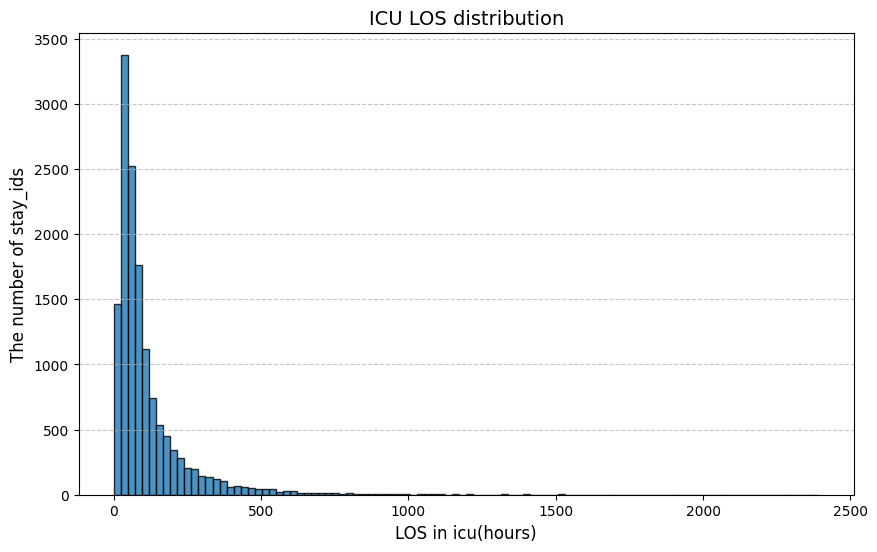

In [194]:
plt.figure(figsize=(10, 6))
plt.hist(updated_df_icustays['los_hours'], bins=100, edgecolor='black', alpha=0.8)
plt.xlabel('LOS in icu(hours)', fontsize=12)
plt.ylabel('The number of stay_ids', fontsize=12)
plt.title('ICU LOS distribution', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [195]:
print("상위 90%: ", np.percentile(updated_df_icustays['los_hours'], 90))
print("상위 95%: ", np.percentile(updated_df_icustays['los_hours'], 95))
print("상위 99%: ", np.percentile(updated_df_icustays['los_hours'], 99))

상위 90%:  254.0394444444444
상위 95%:  363.1015833333333
상위 99%:  695.6246777777777


In [196]:
print("check: ", len(updated_df_icustays[updated_df_icustays['los_hours'] > 1000]))

check:  37


In [197]:
def create_dynamic_hr_timeslots(icustays_df, freq_minutes=60): 
    time_slots_list = []

    for idx, row in icustays_df.iterrows():
        subject_id = row['subject_id']
        hadm_id = row['hadm_id']
        stay_id = row['stay_id']
        intime = row['intime']
        outtime = row['outtime']

        slot_idx = 0
        slot_start = intime
        delta = pd.Timedelta(minutes=freq_minutes)

        while slot_start < outtime: 
            slot_end = slot_start + delta

            time_slots_list.append({
                'subject_id': subject_id,
                'hadm_id': hadm_id,
                'stay_id': stay_id,
                'slot_idx': slot_idx,
                'slot_start': slot_start,
                'slot_end': slot_end
            })

            slot_idx += 1
            slot_start = slot_end

    time_slots_df = pd.DataFrame(time_slots_list)

    time_slots_df['subject_id'] = time_slots_df['subject_id'].astype(int)
    time_slots_df['hadm_id'] = time_slots_df['hadm_id'].astype(int)
    time_slots_df['stay_id'] = time_slots_df['stay_id'].astype(int)

    return time_slots_df

    # ######################################## 필터링 ########################################
    # orig_stay_count = time_slots_df['stay_id'].nunique()
    # orig_row_count = len(time_slots_df)
    
    # stay_counts = time_slots_df.groupby('stay_id')['slot_idx'].max() + 1
    
    # # min_slots = 4                                  # [조건 1] 2시간 이하 제외: 30분 단위이므로 총 슬롯 개수가 4개 미만인 것 제외 (즉, >= 4인 것만 유지)
    # max_slots_threshold = stay_counts.quantile(0.95) # [조건 2] 상위 5% 제외: 전체 stay들의 슬롯 개수 중 95분위수

    # # under_2h_stays = stay_counts[stay_counts < min_slots].index
    # top_5_percent_stays = stay_counts[stay_counts > max_slots_threshold].index
    
    # # valid_stays = stay_counts[(stay_counts >= min_slots) & (stay_counts <= max_slots_threshold)].index
    # valid_stays = stay_counts[(stay_counts <= max_slots_threshold)].index
    # filtered_time_slots_df = time_slots_df[time_slots_df['stay_id'].isin(valid_stays)].reset_index(drop=True)

    # final_stay_count = filtered_time_slots_df['stay_id'].nunique()
    # final_row_count = len(filtered_time_slots_df)

    # print("-"*60)
    # print(f"❌ 제외된 stay_id 개수:")
    # # print(f"   - 2시간 이하 제외: {len(under_2h_stays)}개")
    # print(f"   - 상위 5% 초과 제외(지나치게 긴 stay는 제외함): {len(top_5_percent_stays)}개")
    # print("-"*60)
    # print(f"✅ 환자 Stay(ICU 입원 건수) 변화: {orig_stay_count}개 -> {final_stay_count}개 (Dropped: {orig_stay_count - final_stay_count}개)")
    # print(f"✅ 전체 행(Row) 데이터 개수 변화: {orig_row_count}개 -> {final_row_count}개")
    # print("="*60)

    # return filtered_time_slots_df

In [198]:
time_slots_df = create_dynamic_hr_timeslots(key_id_icu, freq_minutes=60)
time_slots_df

,subject_id,hadm_id,stay_id,slot_idx,slot_start,slot_end
0,10001884,26184834,37510196,0,2131-01-11 04:20:05,2131-01-11 05:20:05
1,10001884,26184834,37510196,1,2131-01-11 05:20:05,2131-01-11 06:20:05
2,10001884,26184834,37510196,2,2131-01-11 06:20:05,2131-01-11 07:20:05
3,10001884,26184834,37510196,3,2131-01-11 07:20:05,2131-01-11 08:20:05
4,10001884,26184834,37510196,4,2131-01-11 08:20:05,2131-01-11 09:20:05
...,...,...,...,...,...,...
1617940,19999987,23865745,36195440,42,2145-11-04 16:59:00,2145-11-04 17:59:00
1617941,19999987,23865745,36195440,43,2145-11-04 17:59:00,2145-11-04 18:59:00
1617942,19999987,23865745,36195440,44,2145-11-04 18:59:00,2145-11-04 19:59:00
1617943,19999987,23865745,36195440,45,2145-11-04 19:59:00,2145-11-04 20:59:00


In [199]:
time_slots_df

,subject_id,hadm_id,stay_id,slot_idx,slot_start,slot_end
0,10001884,26184834,37510196,0,2131-01-11 04:20:05,2131-01-11 05:20:05
1,10001884,26184834,37510196,1,2131-01-11 05:20:05,2131-01-11 06:20:05
2,10001884,26184834,37510196,2,2131-01-11 06:20:05,2131-01-11 07:20:05
3,10001884,26184834,37510196,3,2131-01-11 07:20:05,2131-01-11 08:20:05
4,10001884,26184834,37510196,4,2131-01-11 08:20:05,2131-01-11 09:20:05
...,...,...,...,...,...,...
1617940,19999987,23865745,36195440,42,2145-11-04 16:59:00,2145-11-04 17:59:00
1617941,19999987,23865745,36195440,43,2145-11-04 17:59:00,2145-11-04 18:59:00
1617942,19999987,23865745,36195440,44,2145-11-04 18:59:00,2145-11-04 19:59:00
1617943,19999987,23865745,36195440,45,2145-11-04 19:59:00,2145-11-04 20:59:00


In [200]:
time_slots_df['stay_id'].nunique()

14127

In [201]:
# hosp cxr -> icu cxr
intime_df = time_slots_df[time_slots_df['slot_idx'] == 0][['hadm_id', 'stay_id', 'slot_start']]
hosp_cxr_before_icu = hosp_icu_cxr[hosp_icu_cxr['hadm_id'].isin(intime_df['hadm_id'])]
merged_df = hosp_cxr_before_icu.merge(intime_df, on='hadm_id', how='left')

filtered_df = merged_df[
    (merged_df['cxrtime'] >= merged_df['slot_start'] - pd.Timedelta(days=1)) & 
    (merged_df['cxrtime'] < merged_df['slot_start'])
].reset_index(drop=True)

filtered_df['time_diff'] = (filtered_df['slot_start'] - filtered_df['cxrtime']).abs()
filtered_df = filtered_df.sort_values(['hadm_id', 'slot_start', 'time_diff']).reset_index(drop=True)

closest_cxr_df = filtered_df.loc[
    filtered_df.groupby(['hadm_id'])['time_diff'].idxmin()
].reset_index(drop=True)

closest_cxr_df = closest_cxr_df.merge(intime_df, on=['hadm_id', 'slot_start'], how='left')
closest_cxr_df = closest_cxr_df.drop(columns=['stay_id_x', 'stay_id_y'])

In [202]:
closest_cxr_df

,subject_id,hadm_id,cxrtime,ViewPosition,dicom_id,Img_Folder,Img_Filename,study_id,Atelectasis,Cardiomegaly,Consolidation,Edema,Enlarged Cardiomediastinum,Fracture,Lung Lesion,Lung Opacity,No Finding,Pleural Effusion,Pleural Other,Pneumonia,Pneumothorax,Support Devices,slot_start,time_diff,stay_id
0,15457916,20012254.0,2171-09-04 09:10:51.718,AP,aabb91d8-f7fd81a7-f50ac78f-4aa49ce3-49bec26e,files/p15/p15457916/s54064261,aabb91d8-f7fd81a7-f50ac78f-4aa49ce3-49bec26e.jpg,54064261,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,2171-09-04 16:59:56,0 days 07:49:04.282000,34250019
1,19210871,20020562.0,2150-08-19 08:38:28.468,AP,0240b411-8ab0e647-bbd00587-ac5ed4cc-cacf2c41,files/p19/p19210871/s52238602,0240b411-8ab0e647-bbd00587-ac5ed4cc-cacf2c41.jpg,52238602,1.0,1.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,1.0,2150-08-19 10:01:30,0 days 01:23:01.532000,30253505
2,18549459,20021612.0,2162-05-06 19:22:25.406,AP,f0b0b20d-413d3332-3a3ee847-b8a542ca-d5430d7b,files/p18/p18549459/s50260240,f0b0b20d-413d3332-3a3ee847-b8a542ca-d5430d7b.jpg,50260240,-1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2162-05-06 19:23:50,0 days 00:01:24.594000,34145253
3,11300581,20022952.0,2120-01-24 22:56:55.046,AP,5e3d3f3a-d432079d-704c49a8-c96bea98-3922cb58,files/p11/p11300581/s59864479,5e3d3f3a-d432079d-704c49a8-c96bea98-3922cb58.jpg,59864479,1.0,0.0,NaN,1.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,1.0,0.0,2120-01-25 02:14:03,0 days 03:17:07.954000,34670323
4,14362539,20023225.0,2140-06-30 13:17:05.125,AP,c4c18d33-6d4d1d67-b114fee5-17d16446-8e4239f9,files/p14/p14362539/s55613271,c4c18d33-6d4d1d67-b114fee5-17d16446-8e4239f9.jpg,55613271,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,2140-06-30 15:13:00,0 days 01:55:54.875000,35035530
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2559,18692094,29967655.0,2177-10-19 22:24:46.218,AP,5913c585-34d7c3f4-925e08dc-31b95c3e-51ad7d37,files/p18/p18692094/s59297679,5913c585-34d7c3f4-925e08dc-31b95c3e-51ad7d37.jpg,59297679,1.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,1.0,2177-10-19 22:49:00,0 days 00:24:13.782000,35646928
2560,17854225,29973313.0,2155-04-18 22:42:04.593,AP,6064acca-69c0399a-fc413004-7f561672-54c21f46,files/p17/p17854225/s59822995,6064acca-69c0399a-fc413004-7f561672-54c21f46.jpg,59822995,NaN,NaN,NaN,1.0,-1.0,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,2155-04-18 23:17:43,0 days 00:35:38.407000,32878949
2561,17646651,29988947.0,2175-09-02 22:47:29.546,AP,65092dc6-e28f8832-f5759cfd-da7ed52b-1216368a,files/p17/p17646651/s51866138,65092dc6-e28f8832-f5759cfd-da7ed52b-1216368a.jpg,51866138,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,2175-09-02 23:29:07,0 days 00:41:37.454000,38518978
2562,17396346,29990184.0,2187-06-19 10:33:24.171,AP,cf843573-ae7cd8aa-c637c215-2d2fa112-c95d2574,files/p17/p17396346/s51828119,cf843573-ae7cd8aa-c637c215-2d2fa112-c95d2574.jpg,51828119,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,2187-06-19 16:18:25,0 days 05:45:00.829000,38079136


---

## 4.1 Procedure events

In [203]:
# # ekg
# proc_itemid = [225402, 225794]

In [204]:
# proc_list = df_ditems[df_ditems['itemid'].isin(proc_itemid)].reset_index(drop=True)
# proc_list

In [205]:
# def resampling_procedure(procedureevents, time_slots_df):

#     """
#     Procedure event를 proc_itemid를 한정하여 resampling함.
#     이때 procedure이 시행되었는지 여부를 0, 1로 라벨링함.
#     """

#     procedureevents = procedureevents[procedureevents['itemid'].isin(proc_itemid)]

#     procedureevents = procedureevents.drop(columns=['valueuom', 'patientweight'])
#     procedureevents = procedureevents.sort_values(by=['stay_id', 'itemid', 'starttime']).reset_index(drop=True)

#     binary_results = []

#     # Binary 처리
#     for idx, row in tqdm(procedureevents.iterrows(), total=len(procedureevents), desc="Processing procedureevents"):
#         hadm = row['hadm_id']
#         stay = row['stay_id']
#         start_time = row['starttime']
#         end_time = row['endtime']
#         itemid = row['itemid']

#         patient_slots = time_slots_df[time_slots_df['stay_id'] == stay].copy()

#         overlapping = patient_slots[
#             (patient_slots['slot_start'] <= end_time) &
#             (patient_slots['slot_end'] > start_time)]
        
#         if overlapping.empty:
#             continue

#         for idx, slotrow in overlapping.iterrows(): 
#             binary_results.append({
#                 'hadm_id': hadm,
#                 'stay_id': stay,
#                 'itemid': itemid,
#                 'hour_slot': slotrow['hour_slot'],
#                 'slot_start': slotrow['slot_start'],
#                 'procedure_flag': 1
#             })

#     binary_results = pd.DataFrame(binary_results).drop_duplicates()
#     expanded_results = []

#     for itemid in tqdm(proc_itemid, total = len(proc_itemid), desc = "Processing procedureevents"):
#         item_slots = time_slots_df.copy()
#         item_slots['itemid'] = itemid
#         item_slots['procedure_flag'] = 0

#         item_data = binary_results[binary_results['itemid']==itemid]
        
#         if not item_data.empty:
#             item_slots = pd.merge(item_slots, item_data[['stay_id', 'hour_slot', 'procedure_flag']], how='left', on=['stay_id', 'hour_slot'])
#             item_slots['procedure_flag'] = item_slots['procedure_flag_y'].fillna(item_slots['procedure_flag_x']).astype(int)
#             item_slots = item_slots.drop(columns=['procedure_flag_x', 'procedure_flag_y'])
#         expanded_results.append(item_slots)

#     processed_df = pd.concat(expanded_results, ignore_index=True)
#     return processed_df

In [206]:
# sequential_df_proc = resampling_procedure(df_proc, time_slots_df)
# sequential_df_proc

In [207]:
# df_proc[(df_proc['itemid']==225794) & (df_proc['stay_id']==37510196)]

In [208]:
# sequential_df_proc[(sequential_df_proc['itemid']==225794) & (sequential_df_proc['stay_id']==37510196)].iloc[35:50, :]

In [209]:
# sequential_df_proc['procedure_flag'].value_counts()

In [210]:
# sequential_df_proc.to_feather(store_dir + '/processed/sequential_df_proc.ftr')

## 4.2 Medication(Inputevents)

- starttime과 endtime이 동일한 Bolus 확인해보기

In [211]:
# # furosemide 250/50 -> furosemide로 통일
# df_input.loc[df_input['itemid']==228340, 'itemid'] = 221794

In [212]:
# # medication에서는 albumin (220862) 삭제, bumetanide, angiotensin도 삭제 -> chartevent에서 활용함
# med_itemid = [221794, 221906, 221662, 221653, 221749, 221986, 222051, 222056, 225168, 225974] 

In [213]:
# med_list = df_ditems[df_ditems['itemid'].isin(med_itemid)].reset_index(drop=True)
# med_list

In [214]:
# # inputevents resampling
# def resampling_input(inputevents, time_slots_df): 
#     """
#     input event를 proc_itemid를 한정하여 resampling함.
#     투여량을 시간에 비례하여 분할하여 같은 itemid끼리는 합산하여 시간당 투여량을 계산함.
#     """

#     inputevents = inputevents[inputevents['itemid'].isin(med_itemid)]
#     inputevents = inputevents.drop(columns=['rate', 'rateuom', 'patientweight'])
#     inputevents = inputevents.sort_values(by=['stay_id', 'itemid', 'starttime']).reset_index(drop=True)

#     expanded_results = []

#     for itemid in tqdm(med_itemid, total=len(med_itemid), desc="Processing inputevents"): 
#         item_slots = time_slots_df.copy()
#         item_slots['itemid'] = itemid
#         item_slots['input_amount'] = np.nan

#         item_data = inputevents[inputevents['itemid'] == itemid]

#         records = []

#         for _, row in item_data.iterrows():
#             stay = row['stay_id']
#             start_time = row['starttime']
#             end_time = row['endtime']
#             amount = row['amount']

#             patient_slots = time_slots_df[time_slots_df['stay_id']==stay].copy()
#             overlapping = patient_slots[(patient_slots['slot_start'] <= end_time) & (patient_slots['slot_end'] > start_time)]
            
#             if overlapping.empty:
#                 continue
            
#             total_hours = (end_time - start_time).total_seconds() / 3600.0

#             if total_hours < 0: 
#                 continue

#             for _, slotrow in overlapping.iterrows(): 
#                 if total_hours == 0:
#                     # Bolus
#                     amount_per_slot = amount

#                 else: 
#                     # Continuous infusion
#                     overlap_start = max(start_time, slotrow['slot_start'])
#                     overlap_end = min(end_time, slotrow['slot_end'])

#                     hours_in_slot = (overlap_end - overlap_start).total_seconds() / 3600.0
#                     hours_in_slot = max(0, hours_in_slot)

#                     amount_per_slot = amount * (hours_in_slot / total_hours)

#                 records.append({
#                     'stay_id': stay,
#                     'hour_slot': slotrow['hour_slot'],
#                     'input_amount': amount_per_slot
#                 })

#         if records:
#             item_data_df = pd.DataFrame(records)
#             grouped_item = item_data_df.groupby(['stay_id', 'hour_slot'], as_index=False)['input_amount'].sum()
    
#             item_slots = pd.merge(item_slots, grouped_item, how='left', on=['stay_id', 'hour_slot'])

#             item_slots['input_amount'] = item_slots['input_amount_y'].combine_first(item_slots['input_amount_x'])
#             item_slots = item_slots.drop(columns=['input_amount_x', 'input_amount_y'])

#         expanded_results.append(item_slots)

#     processed_df = pd.concat(expanded_results, ignore_index=True)
#     return processed_df

In [215]:
# sequential_df_med = resampling_input(df_input, time_slots_df)
# sequential_df_med

In [216]:
# sequential_df_med.to_feather(store_dir + '/processed/sequential_df_med.ftr')

In [217]:
fluid_only_dict = {
    # 'fluid_alb': my_query_dict['fluid_alb'],
    'fluid_cyst': my_query_dict['fluid_cyst']
}

def resampling_fluid(inputevents, time_slots_df, fluid_dict): 
    """
    fluid_dict에 정의된 카테고리(fluid_alb, fluid_cyst)를 기준으로
    해당 카테고리에 속하는 여러 itemid의 투여량을 묶어서 시간대별로 합산하고 빈도를 계산함.
    """
    
    item_to_category = {}
    for category, item_ids in fluid_dict.items():
        for itemid in item_ids:
            item_to_category[itemid] = category
            
    # 매핑된 itemid에 해당하는 데이터만 필터링
    fluid_events = inputevents[inputevents['itemid'].isin(item_to_category.keys())].copy()
    fluid_events['fluid_category'] = fluid_events['itemid'].map(item_to_category)

    fluid_events = fluid_events[fluid_events['amount'] > 0]
    fluid_events = fluid_events.drop(columns=['rate', 'rateuom', 'patientweight'], errors='ignore')
    fluid_events = fluid_events.sort_values(by=['stay_id', 'fluid_category', 'starttime']).reset_index(drop=True)

    expanded_results = []
    categories = list(fluid_dict.keys())
    chunk_size = 3000
    
    for cat in tqdm(categories, total=len(categories), desc="Processing fluid categories"): 
        cat_data = fluid_events[fluid_events['fluid_category'] == cat]

        unique_stays = cat_data['stay_id'].unique()
        all_grouped_chunks = []

        for i in tqdm(range(0, len(unique_stays), chunk_size), desc=f"Chunking {cat}", leave=False):
            chunk_stays = unique_stays[i : i + chunk_size]

            cat_chunk = cat_data[cat_data['stay_id'].isin(chunk_stays)]
            slot_chunk = time_slots_df[time_slots_df['stay_id'].isin(chunk_stays)]

            merged = pd.merge(cat_chunk, slot_chunk, on='stay_id', how='inner')
                
            # 시간이 겹치는 구간만 남기고 필터링
            mask = (merged['slot_start'] <= merged['endtime']) & (merged['slot_end'] >= merged['starttime'])
            valid = merged[mask].copy()
            del merged
        
            # 각 투여 기록의 총 투여 시간 계산
            valid['total_hours'] = (valid['endtime'] - valid['starttime']).dt.total_seconds() / 3600.0
            valid = valid[valid['total_hours'] >= 0]
        
            # 겹치는 시간 계산
            overlap_start = np.maximum(valid['starttime'], valid['slot_start'])
            overlap_end = np.minimum(valid['endtime'], valid['slot_end'])
        
            valid['hours_in_slot'] = (overlap_end - overlap_start).dt.total_seconds() / 3600.0
            valid['hours_in_slot'] = valid['hours_in_slot'].clip(lower=0) # 음수 방지
        
            # 투여량 분할 계산
            is_bolus = valid['total_hours'] == 0
            is_bolus_in_slot = is_bolus & (valid['starttime'] >= valid['slot_start']) & (valid['starttime'] < valid['slot_end'])

            valid['amount_per_slot'] = np.where(
                is_bolus,
                np.where(is_bolus_in_slot, valid['amount'], 0),
                valid['amount'] * (valid['hours_in_slot'] / valid['total_hours']) # Continuous
            )

            # [추가 1] 해당 슬롯에 실질적으로 0 초과의 수액이 투여된 기록만 필터링 (가짜 중복 카운트 방지)
            valid = valid[valid['amount_per_slot'] > 0].copy()

            valid['is_decision_point'] = (
                ((valid['starttime'] >= valid['slot_start']) & (valid['starttime'] < valid['slot_end'])) |
                ((valid['endtime'] > valid['slot_start']) & (valid['endtime'] <= valid['slot_end']))
            )

            # [수정] sum() 대신 agg()를 사용하여 투여량 합산과 투여 결정 횟수(count) 계산
            grouped_chunk = valid.groupby(['stay_id', 'slot_idx'], as_index=False).agg(
                input_amount=('amount_per_slot', 'sum'),
                input_count=('is_decision_point', 'sum') # 단순 row count가 아닌, 이벤트 발생 여부의 합
            )
            
            all_grouped_chunks.append(grouped_chunk)

            del valid, cat_chunk, slot_chunk

        if all_grouped_chunks:
            grouped = pd.concat(all_grouped_chunks, ignore_index=True)
        else:
            # [수정 2] 빈 데이터프레임 생성 시 input_count 컬럼 추가
            grouped = pd.DataFrame(columns=['stay_id', 'slot_idx', 'input_amount', 'input_count'])
            
        # agg()에서 이미 'input_amount'로 이름을 지정했으므로 rename 코드는 삭제합니다.
        # grouped.rename(columns={'amount_per_slot': 'input_amount'}, inplace=True) <- 삭제됨
        
        # 최종 병합
        item_slots = time_slots_df.copy()
        item_slots['fluid_category'] = cat
        item_slots = pd.merge(item_slots, grouped, how='left', on=['stay_id', 'slot_idx'])
        
        # [추가/수정 3] 결측치(투여 없는 구간) 0으로 채우기
        item_slots['input_amount'] = item_slots['input_amount'].fillna(0)
        item_slots['input_count'] = item_slots['input_count'].fillna(0).astype(int)

        expanded_results.append(item_slots)

    processed_df = pd.concat(expanded_results, ignore_index=True)
    return processed_df

In [218]:
sequential_df_fluid = resampling_fluid(df_input, time_slots_df, fluid_only_dict)
sequential_df_fluid

Processing fluid categories:   0%|          | 0/1 [00:00<?, ?it/s]

Chunking fluid_cyst:   0%|          | 0/5 [00:00<?, ?it/s]

,subject_id,hadm_id,stay_id,slot_idx,slot_start,slot_end,fluid_category,input_amount,input_count
0,10001884,26184834,37510196,0,2131-01-11 04:20:05,2131-01-11 05:20:05,fluid_cyst,124.974784,8
1,10001884,26184834,37510196,1,2131-01-11 05:20:05,2131-01-11 06:20:05,fluid_cyst,31.820122,0
2,10001884,26184834,37510196,2,2131-01-11 06:20:05,2131-01-11 07:20:05,fluid_cyst,46.976525,6
3,10001884,26184834,37510196,3,2131-01-11 07:20:05,2131-01-11 08:20:05,fluid_cyst,254.893067,11
4,10001884,26184834,37510196,4,2131-01-11 08:20:05,2131-01-11 09:20:05,fluid_cyst,37.298313,5
...,...,...,...,...,...,...,...,...,...
1617940,19999987,23865745,36195440,42,2145-11-04 16:59:00,2145-11-04 17:59:00,fluid_cyst,0.000000,0
1617941,19999987,23865745,36195440,43,2145-11-04 17:59:00,2145-11-04 18:59:00,fluid_cyst,0.000000,0
1617942,19999987,23865745,36195440,44,2145-11-04 18:59:00,2145-11-04 19:59:00,fluid_cyst,0.000000,0
1617943,19999987,23865745,36195440,45,2145-11-04 19:59:00,2145-11-04 20:59:00,fluid_cyst,201.200000,2


In [219]:
sequential_df_fluid.to_feather(store_dir + 'subject_sequential_df_fluid.ftr')

## SBP, DBP, MAP

In [220]:
key_ids = key_id_icu[['subject_id', 'hadm_id', 'stay_id']]
df_bp = key_ids.merge(df_sbpdbp, how='left', on=['subject_id', 'hadm_id', 'stay_id'])
df_bp

,subject_id,hadm_id,stay_id,charttime,sbp,dbp,map
0,10001884,26184834.0,37510196.0,2131-01-11 04:25:00,180.0,12.0,68.000000
1,10001884,26184834.0,37510196.0,2131-01-11 05:01:00,167.0,49.0,70.000000
2,10001884,26184834.0,37510196.0,2131-01-11 06:01:00,102.0,63.0,75.000000
3,10001884,26184834.0,37510196.0,2131-01-11 06:47:00,110.0,76.0,84.000000
4,10001884,26184834.0,37510196.0,2131-01-11 07:01:00,93.0,62.0,73.000000
...,...,...,...,...,...,...,...
1723102,19999987,23865745.0,36195440.0,2145-11-04 09:00:00,117.0,52.0,60.000000
1723103,19999987,23865745.0,36195440.0,2145-11-04 13:48:00,121.0,72.0,84.000000
1723104,19999987,23865745.0,36195440.0,2145-11-04 16:53:00,152.0,92.0,102.000000
1723105,19999987,23865745.0,36195440.0,2145-11-04 19:31:00,163.0,120.0,134.333333


In [221]:
df_bp.isnull().sum()

subject_id    0
hadm_id       0
stay_id       0
charttime     7
sbp           7
dbp           7
map           7
dtype: int64

In [222]:
# 혈압을 아예 측정하지 않은 stay_id가 998행 존재함.
df_bp[df_bp['charttime'].isna()]

,subject_id,hadm_id,stay_id,charttime,sbp,dbp,map
81341,10459005,23791208.0,36888345.0,NaT,NaN,NaN,NaN
81595,10459005,25159727.0,33128048.0,NaT,NaN,NaN,NaN
715524,14150037,21584214.0,36419366.0,NaT,NaN,NaN,NaN
1469479,18520455,24791611.0,32921081.0,NaT,NaN,NaN,NaN
1470099,18520455,27787695.0,37770507.0,NaT,NaN,NaN,NaN
1548999,18995174,29847087.0,30636593.0,NaT,NaN,NaN,NaN
1549000,18995174,29847087.0,30913564.0,NaT,NaN,NaN,NaN


In [223]:
df_bp = df_bp.dropna(subset=['charttime']).reset_index(drop=True)

In [224]:
df_bp

,subject_id,hadm_id,stay_id,charttime,sbp,dbp,map
0,10001884,26184834.0,37510196.0,2131-01-11 04:25:00,180.0,12.0,68.000000
1,10001884,26184834.0,37510196.0,2131-01-11 05:01:00,167.0,49.0,70.000000
2,10001884,26184834.0,37510196.0,2131-01-11 06:01:00,102.0,63.0,75.000000
3,10001884,26184834.0,37510196.0,2131-01-11 06:47:00,110.0,76.0,84.000000
4,10001884,26184834.0,37510196.0,2131-01-11 07:01:00,93.0,62.0,73.000000
...,...,...,...,...,...,...,...
1723095,19999987,23865745.0,36195440.0,2145-11-04 09:00:00,117.0,52.0,60.000000
1723096,19999987,23865745.0,36195440.0,2145-11-04 13:48:00,121.0,72.0,84.000000
1723097,19999987,23865745.0,36195440.0,2145-11-04 16:53:00,152.0,92.0,102.000000
1723098,19999987,23865745.0,36195440.0,2145-11-04 19:31:00,163.0,120.0,134.333333


In [225]:
def resampling_bp(df_bp, time_slots_df, agg_method='mean'):
    df_bp = df_bp.copy()

    df_bp = df_bp.dropna(subset=['stay_id', 'charttime'])

    df_bp['stay_id'] = df_bp['stay_id'].astype('int')
    df_bp['charttime'] = pd.to_datetime(df_bp['charttime'])

    time_slots = time_slots_df.copy()
    time_slots['stay_id'] = time_slots['stay_id'].astype('int')
    time_slots['slot_start'] = pd.to_datetime(time_slots['slot_start'])

    df_bp = df_bp.sort_values(by=['charttime']).reset_index(drop=True)
    time_slots = time_slots.sort_values(by=['slot_start']).reset_index(drop=True)

    # 혈압 측정 시간(charttime)을 기준으로 가장 가까운 과거의 타임슬롯(slot_start)에 매핑
    merged = pd.merge_asof(
        df_bp,
        time_slots[['stay_id', 'slot_idx', 'slot_start', 'slot_end']],
        by='stay_id',
        left_on='charttime',
        right_on='slot_start',
        direction='backward'
    )

    merged = merged.dropna(subset=['slot_start']) # 타임슬롯 이전의 과거 데이터 제외
    mask = (merged['charttime'] >= merged['slot_start']) & (merged['charttime'] < merged['slot_end'])
    valid = merged[mask].copy()

    agg_func = 'mean' if agg_method == 'mean' else 'last'

    sbp_col = f'sbp_{agg_func}'
    dbp_col = f'dbp_{agg_func}'
    map_col = f'map_{agg_func}'

    # 동일한 환자(stay_id)의 동일한 30분 슬롯(slot_idx) 내 측정값 평균 계산
    grouped = valid.groupby(['stay_id', 'slot_idx', 'slot_start'], as_index=False).agg(**{
        sbp_col: ('sbp', agg_func),
        dbp_col: ('dbp', agg_func),
        map_col: ('map', agg_func),
        'bp_count': ('sbp', 'count'),
        'actual_time': ('charttime', 'max') # 실제 측정 시간은 기조와 상관없이 max 보존
    })

    grouped = grouped[grouped[sbp_col] > grouped[dbp_col]].reset_index(drop=True)

    # 원본 time_slots_df에 최종 Left Join
    # 혈압 측정이 없었던 구간은 NaN
    final_result = pd.merge(
        time_slots,
        grouped,
        on=['stay_id', 'slot_idx', 'slot_start'],
        how='left'
    )

    final_result['bp_count'] = final_result['bp_count'].fillna(0).astype(int)

    return final_result.sort_values(['stay_id', 'slot_idx']).reset_index(drop=True)

In [226]:
df_resampled_bp = resampling_bp(df_bp, time_slots_df, agg_method='last')
# df_resampled_bp = df_resampled_bp.rename(columns={'sbp_mean':'sbp', 'dbp_mean':'dbp', 'map_mean':'map'})
df_resampled_bp = df_resampled_bp.rename(columns={'sbp_last':'sbp', 'dbp_last':'dbp', 'map_last':'map'})
df_resampled_bp

,subject_id,hadm_id,stay_id,slot_idx,slot_start,slot_end,sbp,dbp,map,bp_count,actual_time
0,12207593,22795209,30000646,0,2194-04-29 01:39:22,2194-04-29 02:39:22,111.0,65.0,75.0,2,2194-04-29 02:00:00
1,12207593,22795209,30000646,1,2194-04-29 02:39:22,2194-04-29 03:39:22,97.0,58.0,67.0,1,2194-04-29 03:00:00
2,12207593,22795209,30000646,2,2194-04-29 03:39:22,2194-04-29 04:39:22,98.0,57.0,67.0,1,2194-04-29 04:00:00
3,12207593,22795209,30000646,3,2194-04-29 04:39:22,2194-04-29 05:39:22,98.0,66.0,73.0,1,2194-04-29 05:00:00
4,12207593,22795209,30000646,4,2194-04-29 05:39:22,2194-04-29 06:39:22,93.0,53.0,60.0,7,2194-04-29 06:35:00
...,...,...,...,...,...,...,...,...,...,...,...
1617940,19046950,24352151,39998622,211,2135-02-20 13:13:55,2135-02-20 14:13:55,114.0,75.0,80.0,1,2135-02-20 14:02:00
1617941,19046950,24352151,39998622,212,2135-02-20 14:13:55,2135-02-20 15:13:55,120.0,71.0,83.0,1,2135-02-20 15:01:00
1617942,19046950,24352151,39998622,213,2135-02-20 15:13:55,2135-02-20 16:13:55,127.0,82.0,93.0,1,2135-02-20 16:01:00
1617943,19046950,24352151,39998622,214,2135-02-20 16:13:55,2135-02-20 17:13:55,120.0,71.0,82.0,1,2135-02-20 17:01:00


In [227]:
df_resampled_bp['bp_count'].max()

60

In [228]:
df_resampled_bp.to_feather(store_dir + 'subject_sequential_df_bp.ftr')

## 4.3 Chart events

- GCS는 별도로 처리해야 함

In [229]:
gcs_itemids = {220739, 223900, 223901}

gcs_raw = df_chart[df_chart['itemid'].isin(gcs_itemids)].copy()

gcs_grouped = gcs_raw.groupby(['stay_id', 'charttime'], as_index=False).agg(
    valuenum=('valuenum', 'sum'),
    component_count=('itemid', 'count') # 몇 개의 컴포넌트가 기록되었는지 카운트
)

# 3가지(Eye, Verbal, Motor)가 모두 기록된 시간대의 데이터만 유효한 GCS로 인정
gcs_valid = gcs_grouped[gcs_grouped['component_count'] == 3].copy()

gcs_valid['feature_name'] = 'gcs'
gcs_valid = gcs_valid[['stay_id', 'feature_name', 'charttime', 'valuenum']]

In [230]:
gcs_valid

,stay_id,feature_name,charttime,valuenum
0,30000646,gcs,2194-04-29 01:54:00,15.0
1,30000646,gcs,2194-04-29 08:00:00,15.0
2,30000646,gcs,2194-04-29 16:00:00,15.0
3,30000646,gcs,2194-04-29 20:39:00,15.0
4,30000646,gcs,2194-04-30 08:00:00,15.0
...,...,...,...,...
547646,39998622,gcs,2135-02-20 00:00:00,15.0
547647,39998622,gcs,2135-02-20 04:00:00,15.0
547648,39998622,gcs,2135-02-20 08:00:00,15.0
547649,39998622,gcs,2135-02-20 12:00:00,15.0


In [231]:
# BNP는 일단 포함은 시켜보자고
exclude_vars = {'specimen', 'height', 'weight', 'sbp', 'dbp', 'map', 'NTproBNP', 'ck_mb_frac', 'gcs', 'fluid_alb', 'fluid_cyst', 'urine'}

itemid_to_var_name = {itemid: var_name for var_name, ids in my_query_dict.items() for itemid in ids if var_name not in exclude_vars}

In [232]:
print(itemid_to_var_name)

{220045: 'heart_rate', 50825: 'temperature', 223761: 'temperature', 223762: 'temperature', 224690: 'resp_rate', 220210: 'resp_rate', 50817: 'o2sat', 220277: 'o2sat', 220227: 'o2sat', 50821: 'pao2', 220224: 'pao2', 50816: 'fio2', 223835: 'fio2', 50818: 'paco2', 52040: 'paco2', 220235: 'paco2', 51300: 'wbc', 51301: 'wbc', 51755: 'wbc', 51756: 'wbc', 220546: 'wbc', 51265: 'platelets', 51704: 'platelets', 227457: 'platelets', 51221: 'hematocrit', 51638: 'hematocrit', 51639: 'hematocrit', 52028: 'hematocrit', 50810: 'hematocrit', 226540: 'hematocrit', 220545: 'hematocrit', 50811: 'hemoglobin', 51222: 'hemoglobin', 51640: 'hemoglobin', 220228: 'hemoglobin', 51237: 'pt_inr', 51675: 'pt_inr', 227467: 'pt_inr', 51275: 'ptt', 52923: 'ptt', 227466: 'ptt', 52551: 'd-dimer', 51196: 'd-dimer', 50915: 'd-dimer', 225636: 'd-dimer', 50983: 'sodium', 52623: 'sodium', 50824: 'sodium', 52455: 'sodium', 220645: 'sodium', 228389: 'sodium', 226534: 'sodium', 228390: 'sodium', 50971: 'potassium', 52610: 'pota

In [233]:
bakcup_df_lab = df_lab.copy()
bakcup_df_chart = df_chart.copy()

In [234]:
# ICU 입실 전 Lab 데이터 추출

def get_ward_lab_before_icu_admission(df_lab, time_slots_df, itemid_to_var_name):
    valid_itemids = set(itemid_to_var_name.keys())
    df_lab = df_lab[df_lab['itemid'].isin(valid_itemids)].copy()

    icu_start_df = time_slots_df[time_slots_df['slot_idx'] == 0][['stay_id', 'hadm_id', 'slot_start']]
    df_lab = df_lab.merge(icu_start_df, on='hadm_id', how='inner')
    
    df_lab = df_lab[
        (df_lab['charttime'] >= df_lab['slot_start'] - pd.Timedelta(hours=24)) &
        (df_lab['charttime'] < df_lab['slot_start'])
    ].copy()
    
    df_lab['feature_name'] = df_lab['itemid'].map(itemid_to_var_name)
    df_lab['time_diff'] = (df_lab['slot_start'] - df_lab['charttime']).abs()
    
    # ICU T=0 slot으로 할당할 값 남기기
    closest = df_lab.loc[df_lab.groupby(['stay_id', 'feature_name'])['time_diff'].idxmin()].copy()
    closest['slot_idx'] = 0

    return closest[['stay_id', 'feature_name', 'slot_idx', 'slot_start', 'valuenum']].rename(columns={'valuenum': 'value'})

In [235]:
df_ward_T0 = get_ward_lab_before_icu_admission(df_lab, time_slots_df, itemid_to_var_name)
df_ward_T0

,stay_id,feature_name,slot_idx,slot_start,value
932042,30000646,anion_gap,0,2194-04-29 01:39:22,12.0
932047,30000646,bun,0,2194-04-29 01:39:22,11.0
932043,30000646,creatinine,0,2194-04-29 01:39:22,1.0
932044,30000646,glucose,0,2194-04-29 01:39:22,97.0
932038,30000646,hematocrit,0,2194-04-29 01:39:22,38.8
...,...,...,...,...,...
3584267,39998622,potassium,0,2135-02-11 18:13:55,4.7
3584257,39998622,pt_inr,0,2135-02-11 18:13:55,1.0
3584259,39998622,ptt,0,2135-02-11 18:13:55,32.7
3584269,39998622,sodium,0,2135-02-11 18:13:55,138.0


In [236]:
def assign_stayid_to_lab(df_lab, time_slots_df, itemid_to_var_name):
    valid_itemids = set(itemid_to_var_name.keys())
    df_lab = df_lab[df_lab['itemid'].isin(valid_itemids)].copy()
    
    df_lab['feature_name'] = df_lab['itemid'].map(itemid_to_var_name)

    icu_min_time = time_slots_df['slot_start'].min()
    df_lab = df_lab[df_lab['charttime'] >= icu_min_time].copy()

    icu_stay_ranges = time_slots_df.groupby(['stay_id', 'hadm_id'], as_index=False).agg(
        intime=('slot_start', 'min'),
        outtime=('slot_end', 'max')
    )

    merged_lab = pd.merge(df_lab, icu_stay_ranges, on='hadm_id', how='inner')

    mask = (merged_lab['charttime'] >= merged_lab['intime']) & (merged_lab['charttime'] < merged_lab['outtime'])
    valid_lab = merged_lab[mask].copy()

    valid_lab = valid_lab.drop(columns=['intime', 'outtime'])

    return valid_lab

In [237]:
# ICU 기간 동안의 Lab 데이터만 필터링하고 stay_id를 할당함.
stayid_with_lab = assign_stayid_to_lab(df_lab, time_slots_df, itemid_to_var_name)
stayid_with_lab

,subject_id,hadm_id,specimen_id,itemid,charttime,valuenum,valueuom,feature_name,stay_id
69,10001884.0,26184834.0,39304295,51221,2131-01-11 06:31:00,36.0,%,hematocrit,37510196
70,10001884.0,26184834.0,39304295,51222,2131-01-11 06:31:00,11.4,g/dL,hemoglobin,37510196
71,10001884.0,26184834.0,39304295,51265,2131-01-11 06:31:00,171.0,K/uL,platelets,37510196
72,10001884.0,26184834.0,39304295,51301,2131-01-11 06:31:00,18.4,K/uL,wbc,37510196
73,10001884.0,26184834.0,75007129,51237,2131-01-11 06:31:00,1.4,None,pt_inr,37510196
...,...,...,...,...,...,...,...,...,...
3948618,19999987.0,23865745.0,70437837,50821,2145-11-04 07:18:00,69.0,mm Hg,pao2,36195440
3948619,19999987.0,23865745.0,56350925,51221,2145-11-04 10:40:00,38.2,%,hematocrit,36195440
3948620,19999987.0,23865745.0,56350925,51222,2145-11-04 10:40:00,12.6,g/dL,hemoglobin,36195440
3948621,19999987.0,23865745.0,56350925,51265,2145-11-04 10:40:00,120.0,K/uL,platelets,36195440


In [238]:
valid_itemids = set(itemid_to_var_name.keys())
df_chart_valid = df_chart[df_chart['itemid'].isin(valid_itemids)].copy()
df_chart_valid['feature_name'] = df_chart_valid['itemid'].map(itemid_to_var_name)

In [239]:
cols_to_keep = ['stay_id', 'feature_name', 'charttime', 'valuenum']
icu_lab_sub = stayid_with_lab[cols_to_keep]
icu_chart_sub = df_chart_valid[cols_to_keep]

# GCS 합쳐주기
icu_chart_sub = pd.concat([icu_chart_sub, gcs_valid], ignore_index=True)

combined_raw = pd.concat([icu_chart_sub, icu_lab_sub], ignore_index=True)

# 완전히 동일한 시간에 측정된 중복값 제거
# (예: 동일한 10:00에 Lab과 Chart에 모두 기록된 경우 하나만 남김)
deduplicated_raw = combined_raw.drop_duplicates(
    subset=['stay_id', 'feature_name', 'charttime'], 
    keep='last'
)

In [240]:
len(icu_lab_sub) + len(icu_chart_sub)

13222035

In [241]:
deduplicated_raw

,stay_id,feature_name,charttime,valuenum
0,37510196,heart_rate,2131-01-11 06:00:00,72.0
1,37510196,resp_rate,2131-01-11 06:00:00,20.0
2,37510196,o2sat,2131-01-11 06:00:00,100.0
3,37510196,heart_rate,2131-01-11 06:47:00,71.0
4,37510196,resp_rate,2131-01-11 06:47:00,15.0
...,...,...,...,...
13222030,36195440,pao2,2145-11-04 07:18:00,69.0
13222031,36195440,hematocrit,2145-11-04 10:40:00,38.2
13222032,36195440,hemoglobin,2145-11-04 10:40:00,12.6
13222033,36195440,platelets,2145-11-04 10:40:00,120.0


In [242]:
# def get_ward_lab_within_icu_stay(df_lab, time_slots_df, itemid_map):
#     df_lab = df_lab.copy()
#     df_lab = df_lab.dropna(subset=['stay_id', 'charttime'])
    
#     df_lab = df_lab[df_lab['itemid'].isin(itemid_map.keys())].copy()
#     df_lab['itemid'] = df_lab['itemid'].map(itemid_map) # mapping

#     time_slots_df = time_slots_df.copy()

#     df_lab['stay_id'] = df_lab['stay_id'].astype('int')
#     time_slots_df['stay_id'] = time_slots_df['stay_id'].astype('int')

#     df_lab_sorted = df_lab.sort_values('charttime').reset_index(drop=True)
#     slots_sorted = time_slots_df.sort_values('slot_start').reset_index(drop=True)

#     # 병동 lab을 ICU 시간 슬롯에 할당
#     merged = pd.merge_asof(
#         df_lab_sorted,
#         slots_sorted,
#         by='stay_id',
#         left_on='charttime',
#         right_on='slot_start',
#         direction='backward' # 과거 시점만 허용함.
#     )

#     merged = merged.dropna(subset=['slot_start'])
#     merged = merged[(merged['charttime'] >= merged['slot_start']) & (merged['charttime'] < merged['slot_end'])]

#     grouped = merged.groupby(['stay_id', 'itemid', 'slot_idx', 'slot_start']) \
#                     .agg(value=('valuenum', 'mean')) \
#                     .reset_index()
                    
#     return grouped

In [243]:
# labs_during_icu = get_ward_lab_within_icu_stay(stayid_with_lab, time_slots_df, itemid_map)
# labs_during_icu

In [244]:
itemid_to_var_name

{220045: 'heart_rate',
 50825: 'temperature',
 223761: 'temperature',
 223762: 'temperature',
 224690: 'resp_rate',
 220210: 'resp_rate',
 50817: 'o2sat',
 220277: 'o2sat',
 220227: 'o2sat',
 50821: 'pao2',
 220224: 'pao2',
 50816: 'fio2',
 223835: 'fio2',
 50818: 'paco2',
 52040: 'paco2',
 220235: 'paco2',
 51300: 'wbc',
 51301: 'wbc',
 51755: 'wbc',
 51756: 'wbc',
 220546: 'wbc',
 51265: 'platelets',
 51704: 'platelets',
 227457: 'platelets',
 51221: 'hematocrit',
 51638: 'hematocrit',
 51639: 'hematocrit',
 52028: 'hematocrit',
 50810: 'hematocrit',
 226540: 'hematocrit',
 220545: 'hematocrit',
 50811: 'hemoglobin',
 51222: 'hemoglobin',
 51640: 'hemoglobin',
 220228: 'hemoglobin',
 51237: 'pt_inr',
 51675: 'pt_inr',
 227467: 'pt_inr',
 51275: 'ptt',
 52923: 'ptt',
 227466: 'ptt',
 52551: 'd-dimer',
 51196: 'd-dimer',
 50915: 'd-dimer',
 225636: 'd-dimer',
 50983: 'sodium',
 52623: 'sodium',
 50824: 'sodium',
 52455: 'sodium',
 220645: 'sodium',
 228389: 'sodium',
 226534: 'sodium',

In [245]:
def resampling_chart(combined_df, time_slots_df, itemid_to_var_name, agg_method='mean'):
    combined_df = combined_df.dropna(subset=['stay_id', 'charttime']).copy()

    combined_df['stay_id'] = combined_df['stay_id'].astype('int')

    time_slots_df = time_slots_df.copy()
    time_slots_df['stay_id'] = time_slots_df['stay_id'].astype('int')

    # 2. 시간순 정렬 및 As-of Merge 적용
    combined_sorted = combined_df.sort_values('charttime').reset_index(drop=True)
    slots_sorted = time_slots_df.sort_values('slot_start').reset_index(drop=True)

    merged = pd.merge_asof(
        combined_sorted,
        slots_sorted,
        by='stay_id',
        left_on='charttime',
        right_on='slot_start',
        direction='backward'
    )

    merged = merged.dropna(subset=['slot_start'])
    merged = merged[(merged['charttime'] >= merged['slot_start']) & (merged['charttime'] < merged['slot_end'])]

    # 3. 슬롯별 집계 (Aggregation)
    agg_func = 'mean' if agg_method == 'mean' else 'last'

    grouped = (
        merged.groupby(['stay_id', 'feature_name', 'slot_idx', 'slot_start'], as_index=False)
        .agg(
            value=('valuenum', agg_func),
            measure_count=('valuenum', 'count'),
            actual_time=('charttime', 'max') 
        )
    )

    stay_slots = time_slots_df[['stay_id', 'slot_idx', 'slot_start']].drop_duplicates()

    unique_features = merged['feature_name'].unique()
    items_df = pd.DataFrame({'feature_name': unique_features})
    full_slots = stay_slots.merge(items_df, how='cross')

    final_result = pd.merge(
        full_slots, grouped,
        on=['stay_id', 'slot_idx', 'slot_start', 'feature_name'],
        how='left'
    )

    final_result['measure_count'] = final_result['measure_count'].fillna(0).astype(int)

    return final_result.sort_values(['stay_id', 'feature_name', 'slot_start']).reset_index(drop=True)

In [246]:
icu_merged = resampling_chart(
    combined_df=deduplicated_raw, 
    time_slots_df=time_slots_df, 
    itemid_to_var_name=itemid_to_var_name, 
    agg_method='last'
)

In [247]:
icu_merged[icu_merged['feature_name']=='gcs']

,stay_id,slot_idx,slot_start,feature_name,value,measure_count,actual_time
1695,30000646,0,2194-04-29 01:39:22,gcs,15.0,1,2194-04-29 01:54:00
1696,30000646,1,2194-04-29 02:39:22,gcs,NaN,0,NaT
1697,30000646,2,2194-04-29 03:39:22,gcs,NaN,0,NaT
1698,30000646,3,2194-04-29 04:39:22,gcs,NaN,0,NaT
1699,30000646,4,2194-04-29 05:39:22,gcs,NaN,0,NaT
...,...,...,...,...,...,...,...
53388508,39998622,211,2135-02-20 13:13:55,gcs,NaN,0,NaT
53388509,39998622,212,2135-02-20 14:13:55,gcs,NaN,0,NaT
53388510,39998622,213,2135-02-20 15:13:55,gcs,15.0,1,2135-02-20 16:00:00
53388511,39998622,214,2135-02-20 16:13:55,gcs,NaN,0,NaT


In [248]:
icu_merged['feature_name'].unique()

array(['Brain Natiuretic Peptide', 'albumin', 'alt', 'anion_gap',
       'art_ph', 'ast', 'base_excess', 'bilirubin', 'bun', 'ca_ion',
       'chloride', 'ck_mb', 'creatinine', 'd-dimer', 'fio2', 'gcs',
       'glucose', 'heart_rate', 'hematocrit', 'hemoglobin', 'lactate',
       'o2sat', 'paco2', 'pao2', 'platelets', 'potassium', 'pt_inr',
       'ptt', 'resp_rate', 'sodium', 'temperature', 'troponin-T', 'wbc'],
      dtype=object)

In [249]:
bnp_df = icu_merged[icu_merged['feature_name']=='Brain Natiuretic Peptide']
bnp_df['measure_count'].value_counts()

measure_count
0    1617181
1        764
Name: count, dtype: int64

| 이름          | 내용                                                                 | 생성 방법                        |
|---------------|----------------------------------------------------------------------|----------------------------------|
| `sequential_df_chart`    | ICU stay 중 chart events를 `slot_start` 기준으로 리샘플링한 시계열      | `resampling_chart()`             |
| `df_ward_T0`  | ICU 입실 전 24시간 내 병동 lab 중 가장 최근값을 T=0 slot에 할당         | `get_ward_lab_before_icu_admission()` |
| `df_ward_icu` | ICU stay 중 charttime이 ICU 체류 구간에 포함되는 병동 lab 값을 각 slot에 할당 | `get_ward_lab_within_icu_stay()` |

In [250]:
df_ward_T0_ready = df_ward_T0.rename(columns={'value': 'value_ward', 'slot_start': 'slot_start_ward'}).copy()

final_merged = pd.merge(
    icu_merged, 
    df_ward_T0_ready, 
    on=['stay_id', 'feature_name', 'slot_idx'], 
    how='outer'
)

# 이거 하려고 일부로 slot_start는 Merge의 on 대상에서 제외하였음.
final_merged['slot_start'] = final_merged['slot_start'].fillna(final_merged['slot_start_ward'])

# slot_idx==0이고, ICU value가 결측치일 때만 병동 데이터(value ward)로 채우기
is_ward_fillable = (final_merged['slot_idx'] == 0) & (final_merged['value'].isna()) & (final_merged['value_ward'].notna())

final_merged['value'] = np.where(is_ward_fillable, final_merged['value_ward'], final_merged['value'])

# 병동 데이터를 가져왔으므로 카운트도 1로 보완
final_merged['measure_count'] = np.where(is_ward_fillable, 1, final_merged['measure_count'])
final_merged['measure_count'] = final_merged['measure_count'].fillna(0).astype(int)

final_merged = final_merged.drop(columns=['value_ward', 'slot_start_ward'])
lab_imputed_chart = final_merged.sort_values(['stay_id', 'feature_name', 'slot_idx']).reset_index(drop=True)

In [251]:
lab_imputed_chart['stay_id'].nunique()

14127

In [252]:
lab_imputed_chart

,stay_id,slot_idx,slot_start,feature_name,value,measure_count,actual_time
0,30000646,0,2194-04-29 01:39:22,Brain Natiuretic Peptide,NaN,0,NaT
1,30000646,1,2194-04-29 02:39:22,Brain Natiuretic Peptide,NaN,0,NaT
2,30000646,2,2194-04-29 03:39:22,Brain Natiuretic Peptide,NaN,0,NaT
3,30000646,3,2194-04-29 04:39:22,Brain Natiuretic Peptide,NaN,0,NaT
4,30000646,4,2194-04-29 05:39:22,Brain Natiuretic Peptide,NaN,0,NaT
...,...,...,...,...,...,...,...
53392180,39998622,211,2135-02-20 13:13:55,wbc,NaN,0,NaT
53392181,39998622,212,2135-02-20 14:13:55,wbc,NaN,0,NaT
53392182,39998622,213,2135-02-20 15:13:55,wbc,NaN,0,NaT
53392183,39998622,214,2135-02-20 16:13:55,wbc,NaN,0,NaT


In [253]:
lab_imputed_chart['feature_name'].nunique()

33

In [254]:
lab_imputed_chart['feature_name'].unique()

array(['Brain Natiuretic Peptide', 'albumin', 'alt', 'anion_gap',
       'art_ph', 'ast', 'base_excess', 'bilirubin', 'bun', 'ca_ion',
       'chloride', 'ck_mb', 'creatinine', 'd-dimer', 'fio2', 'gcs',
       'glucose', 'heart_rate', 'hematocrit', 'hemoglobin', 'lactate',
       'o2sat', 'paco2', 'pao2', 'platelets', 'potassium', 'pt_inr',
       'ptt', 'resp_rate', 'sodium', 'temperature', 'troponin-T', 'wbc'],
      dtype=object)

In [255]:
lab_imputed_chart = lab_imputed_chart.drop(columns=['actual_time'])
lab_imputed_chart['value'] = lab_imputed_chart['value'].fillna(0)

In [256]:
# 이게 NaN인 값들임.
lab_imputed_chart[(lab_imputed_chart['value']==0.0) & (lab_imputed_chart['measure_count']==0)]

,stay_id,slot_idx,slot_start,feature_name,value,measure_count
0,30000646,0,2194-04-29 01:39:22,Brain Natiuretic Peptide,0.0,0
1,30000646,1,2194-04-29 02:39:22,Brain Natiuretic Peptide,0.0,0
2,30000646,2,2194-04-29 03:39:22,Brain Natiuretic Peptide,0.0,0
3,30000646,3,2194-04-29 04:39:22,Brain Natiuretic Peptide,0.0,0
4,30000646,4,2194-04-29 05:39:22,Brain Natiuretic Peptide,0.0,0
...,...,...,...,...,...,...
53392180,39998622,211,2135-02-20 13:13:55,wbc,0.0,0
53392181,39998622,212,2135-02-20 14:13:55,wbc,0.0,0
53392182,39998622,213,2135-02-20 15:13:55,wbc,0.0,0
53392183,39998622,214,2135-02-20 16:13:55,wbc,0.0,0


In [257]:
lab_imputed_chart[lab_imputed_chart['value'] > 0.0]

,stay_id,slot_idx,slot_start,feature_name,value,measure_count
230,30000646,4,2194-04-29 05:39:22,alt,22.0,1
339,30000646,0,2194-04-29 01:39:22,anion_gap,12.0,1
343,30000646,4,2194-04-29 05:39:22,anion_gap,12.0,1
356,30000646,17,2194-04-29 18:39:22,anion_gap,13.0,1
366,30000646,27,2194-04-30 04:39:22,anion_gap,10.0,1
...,...,...,...,...,...,...
53392072,39998622,103,2135-02-16 01:13:55,wbc,10.4,1
53392097,39998622,128,2135-02-17 02:13:55,wbc,10.7,1
53392124,39998622,155,2135-02-18 05:13:55,wbc,12.5,1
53392145,39998622,176,2135-02-19 02:13:55,wbc,10.2,1


In [258]:
lab_imputed_chart[lab_imputed_chart['measure_count']>1]

,stay_id,slot_idx,slot_start,feature_name,value,measure_count
1921,30000646,0,2194-04-29 01:39:22,heart_rate,102.000000,2
1925,30000646,4,2194-04-29 05:39:22,heart_rate,94.000000,11
1926,30000646,5,2194-04-29 06:39:22,heart_rate,93.000000,10
1928,30000646,7,2194-04-29 08:39:22,heart_rate,78.000000,2
1937,30000646,16,2194-04-29 17:39:22,heart_rate,85.000000,3
...,...,...,...,...,...,...
53391260,39998622,155,2135-02-18 05:13:55,resp_rate,24.000000,4
53391266,39998622,161,2135-02-18 11:13:55,resp_rate,29.000000,2
53391281,39998622,176,2135-02-19 02:13:55,resp_rate,16.000000,2
53391293,39998622,188,2135-02-19 14:13:55,resp_rate,31.000000,2


In [259]:
store_dir

'/home/DAHS1/gangmin/my_research/clinical_multimodal_learning/data/full_data/subject_data/mimic_3_1/'

In [260]:
lab_imputed_chart.to_feather(store_dir + 'subject_lab_imputed_chart.ftr')

## 4.4 Output events

In [261]:
df_urine = df_urine[['hadm_id', 'stay_id', 'starttime', 'endtime', 'urine']]
df_urine = df_urine.sort_values(by=['stay_id', 'starttime']).reset_index(drop=True)

In [262]:
is_same_time = (df_urine['endtime'] - df_urine['starttime']) == pd.Timedelta(seconds=0)
same_time_count = is_same_time.sum()
total_count = len(df_urine)
percentage = (same_time_count / total_count) * 100

print(f"시작 시간과 종료 시간이 동일한 소변량 기록: {same_time_count:,}건")
print(f"전체 소변량 데이터 중 비율: {percentage:.2f}%")

if same_time_count > 0:
    display(df_urine[is_same_time][['stay_id', 'starttime', 'endtime', 'urine']])

시작 시간과 종료 시간이 동일한 소변량 기록: 334건
전체 소변량 데이터 중 비율: 0.03%


,stay_id,starttime,endtime,urine
1306,30015361,2140-09-30 20:00:00,2140-09-30 20:00:00,NaN
1668,30024130,2121-05-14 18:00:00,2121-05-14 18:00:00,NaN
2478,30033048,2115-03-23 22:01:00,2115-03-23 22:01:00,NaN
7094,30070238,2181-04-18 09:00:00,2181-04-18 09:00:00,NaN
8314,30090650,2165-10-09 03:01:00,2165-10-09 03:01:00,NaN
...,...,...,...,...
941883,39739449,2174-07-31 15:00:00,2174-07-31 15:00:00,NaN
944251,39769027,2138-08-25 10:00:00,2138-08-25 10:00:00,NaN
944989,39775416,2158-04-03 13:33:00,2158-04-03 13:33:00,NaN
945997,39784741,2157-11-23 20:00:00,2157-11-23 20:00:00,NaN


In [263]:
print(len(df_urine[df_urine['urine']==0]))
print(len(df_urine[df_urine['urine']<0]))

10914
217


In [264]:
df_urine

,hadm_id,stay_id,starttime,endtime,urine
0,22795209,30000646,2194-04-29 00:39:22,2194-04-29 05:54:00,700.0
1,22795209,30000646,2194-04-29 05:55:00,2194-04-29 08:00:00,NaN
2,22795209,30000646,2194-04-29 08:01:00,2194-04-29 15:00:00,925.0
3,22795209,30000646,2194-04-29 15:01:00,2194-04-29 19:00:00,1000.0
4,22795209,30000646,2194-04-29 19:01:00,2194-04-29 23:00:00,750.0
...,...,...,...,...,...
969772,24352151,39998622,2135-02-20 13:01:00,2135-02-20 14:00:00,35.0
969773,24352151,39998622,2135-02-20 14:01:00,2135-02-20 15:00:00,60.0
969774,24352151,39998622,2135-02-20 15:01:00,2135-02-20 15:22:00,NaN
969775,24352151,39998622,2135-02-20 15:23:00,2135-02-20 16:00:00,275.0


In [ ]:
def resampling_output(df_urine, time_slots_df):
    # 0. 안전장치: 결측치 제거 (0과 음수는 정상 데이터이므로 유지)
    df_urine = df_urine.dropna(subset=['stay_id', 'starttime', 'endtime']).copy()
    df_urine = df_urine[df_urine['urine'].notna()]

    # 결과를 담을 리스트
    resampled_chunks = []
    
    # 덩치가 큰 time_slots_df를 stay_id 기준으로 룹을 돌리기 위해 groupby 선언
    grouped_slots = time_slots_df.groupby('stay_id')
    grouped_urine = df_urine.groupby('stay_id')
    
    print("환자별 소변량 리샘플링 진행 중...")
    for stay_id, slot_chunk in tqdm(grouped_slots):
        # 해당 환자의 소변 데이터가 없다면 모두 0으로 채워서 결과에 추가
        if stay_id not in grouped_urine.groups:
            slot_chunk = slot_chunk.copy()
            slot_chunk['urine_output'] = 0.0
            slot_chunk['urine_count'] = 0 # [추가] 데이터가 없으므로 빈도수도 0
            resampled_chunks.append(slot_chunk)
            continue
            
        urine_chunk = grouped_urine.get_group(stay_id)
        
        merged = pd.merge(urine_chunk, slot_chunk, on='stay_id', how='inner')
        
        # 겹치는 구간 계산
        merged['overlap_start'] = np.maximum(merged['starttime'], merged['slot_start'])
        merged['overlap_end'] = np.minimum(merged['endtime'], merged['slot_end'])
        
        merged['overlap_hours'] = (merged['overlap_end'] - merged['overlap_start']).dt.total_seconds() / 3600.0
        merged['overlap_hours'] = merged['overlap_hours'].clip(lower=0)
        
        total_hours = (merged['endtime'] - merged['starttime']).dt.total_seconds() / 3600.0
        is_momentary = (total_hours == 0)
        
        # 조건 필터링
        valid_momentary = is_momentary & (merged['starttime'] >= merged['slot_start']) & (merged['starttime'] < merged['slot_end'])
        valid_continuous = (~is_momentary) & (merged['overlap_hours'] > 0)
        
        merged = merged[valid_momentary | valid_continuous].copy()
        
        if merged.empty:
            slot_chunk = slot_chunk.copy()
            slot_chunk['urine_output'] = 0.0
            slot_chunk['urine_count'] = 0 # [추가] 겹치는 데이터가 없으므로 빈도수 0
            resampled_chunks.append(slot_chunk)
            continue
            
        # 다시 한번 필터링 후 시간 계산
        total_hours_filtered = (merged['endtime'] - merged['starttime']).dt.total_seconds() / 3600.0
        is_momentary_filtered = (total_hours_filtered == 0)
        
        # 비율 배분
        merged['urine_output'] = np.where(
            is_momentary_filtered,
            merged['urine'],
            merged['urine'] * (merged['overlap_hours'] / total_hours_filtered)
        )
        
        merged['is_measured_here'] = np.where(
            is_momentary_filtered,
            (merged['starttime'] >= merged['slot_start']) & (merged['starttime'] < merged['slot_end']),
            (merged['endtime'] > merged['slot_start']) & (merged['endtime'] <= merged['slot_end'])
        )

        # 슬롯별 합산 및 빈도수 계산
        grouped = merged.groupby(['stay_id', 'slot_idx'], as_index=False).agg(
            urine_output=('urine_output', 'sum'),
            urine_count=('is_measured_here', 'sum') # [수정] 단순 count가 아닌 마스킹된 값의 sum을 구함
        )
        
        # 원본 슬롯 구조에 매핑
        processed_chunk = pd.merge(slot_chunk, grouped, on=['stay_id', 'slot_idx'], how='left')
        processed_chunk['urine_output'] = processed_chunk['urine_output'].fillna(0)
        processed_chunk['urine_count'] = processed_chunk['urine_count'].fillna(0).astype(int) # [추가] 결측치 0으로 채우고 정수형 변환
        
        resampled_chunks.append(processed_chunk)
        
    # 쪼개서 처리한 환자별 데이터를 하나로 묶기
    final_df = pd.concat(resampled_chunks, ignore_index=True)

    # 모든 계산이 끝난 후 남은 순수 마이너스(세척액 잔여분)를 0으로 자르기
    final_df['urine_output'] = final_df['urine_output'].clip(lower=0)
    
    return final_df

In [266]:
sequential_df_output = resampling_output(df_urine, time_slots_df)

환자별 소변량 리샘플링 진행 중...


  0%|          | 0/14127 [00:00<?, ?it/s]

In [267]:
sequential_df_output.to_feather(store_dir + 'subject_sequential_df_output.ftr')

In [268]:
sequential_df_output[sequential_df_output['stay_id']==37510196].head(20)

,subject_id,hadm_id,stay_id,slot_idx,slot_start,slot_end,urine_output,urine_count
1210020,10001884,26184834,37510196,0,2131-01-11 04:20:05,2131-01-11 05:20:05,58.946115,0
1210021,10001884,26184834,37510196,1,2131-01-11 05:20:05,2131-01-11 06:20:05,58.946115,0
1210022,10001884,26184834,37510196,2,2131-01-11 06:20:05,2131-01-11 07:20:05,58.946115,0
1210023,10001884,26184834,37510196,3,2131-01-11 07:20:05,2131-01-11 08:20:05,71.560173,1
1210024,10001884,26184834,37510196,4,2131-01-11 08:20:05,2131-01-11 09:20:05,123.782818,1
1210025,10001884,26184834,37510196,5,2131-01-11 09:20:05,2131-01-11 10:20:05,226.217182,2
1210026,10001884,26184834,37510196,6,2131-01-11 10:20:05,2131-01-11 11:20:05,93.531073,1
1210027,10001884,26184834,37510196,7,2131-01-11 11:20:05,2131-01-11 12:20:05,78.382768,1
1210028,10001884,26184834,37510196,8,2131-01-11 12:20:05,2131-01-11 13:20:05,70.148305,1
1210029,10001884,26184834,37510196,9,2131-01-11 13:20:05,2131-01-11 14:20:05,56.765537,1


<!-- ## 4.5 CXR (Image modality) -->

In [269]:
print(sequential_df_output['urine_output'].max())
print(sequential_df_output['urine_output'].min())
print(sequential_df_output['urine_output'].mean())

447.45762711864404
0.0
69.75662546400851


---

In [270]:
labeling = df_cxr[['stay_id', 'cxrtime', 'Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Enlarged Cardiomediastinum', 'Fracture', 'Lung Lesion', 'Lung Opacity', 'No Finding', 'Pleural Effusion', 'Pleural Other', 'Pneumonia', 'Pneumothorax', 'Support Devices']]
labeling

,stay_id,cxrtime,Atelectasis,Cardiomegaly,Consolidation,Edema,Enlarged Cardiomediastinum,Fracture,Lung Lesion,Lung Opacity,No Finding,Pleural Effusion,Pleural Other,Pneumonia,Pneumothorax,Support Devices
0,37510196.0,2131-01-15 04:45:09.078,NaN,1.0,-1.0,NaN,NaN,NaN,NaN,-1.0,NaN,NaN,NaN,NaN,0.0,1.0
1,37510196.0,2131-01-12 04:56:56.359,NaN,1.0,NaN,1.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,0.0,1.0
2,37510196.0,2131-01-13 04:49:18.484,NaN,1.0,NaN,1.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,0.0,1.0
3,37510196.0,2131-01-14 10:34:28.765,NaN,NaN,NaN,-1.0,NaN,NaN,NaN,1.0,NaN,-1.0,NaN,-1.0,NaN,1.0
4,35479615.0,2156-05-18 02:47:37.203,1.0,NaN,NaN,1.0,NaN,NaN,NaN,1.0,NaN,1.0,NaN,NaN,NaN,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
57930,35165301.0,2197-08-07 09:06:37.796,0.0,NaN,1.0,NaN,NaN,NaN,1.0,1.0,NaN,NaN,NaN,NaN,0.0,1.0
57931,35165301.0,2197-08-05 09:37:46.343,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN
57932,32336619.0,2148-11-19 22:47:03.375,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,1.0
57933,36195440.0,2145-11-04 05:14:48.218,1.0,-1.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,0.0,NaN,NaN,0.0,NaN


In [271]:
labeling.to_feather(store_dir + 'subject_all_labeling.ftr')

In [272]:
def assign_cxr_to_slots(cxr, time_slots_df): 
    cxr_sorted = cxr.copy().sort_values(by=['stay_id', 'cxrtime'])
    merged = pd.merge(cxr_sorted, time_slots_df, on='stay_id', how='inner')

    merged = merged[(merged['cxrtime'] >= merged['slot_start']) & (merged['cxrtime'] < merged['slot_end'])]

    merged = merged.sort_values(by=['stay_id', 'slot_idx', 'cxrtime'])
    merged = merged.drop_duplicates(subset=['stay_id', 'slot_idx'], keep='first')

    cxr_features = [
        'stay_id', 'slot_idx', 'Img_Folder', 'Img_Filename', 'cxrtime',
        'Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 
        'Enlarged Cardiomediastinum', 'Fracture', 'Lung Lesion', 'Lung Opacity', 
        'No Finding', 'Pleural Effusion', 'Pleural Other', 'Pneumonia', 
        'Pneumothorax', 'Support Devices'
    ]
    
    all_slots = time_slots_df.copy()
    processed_df = pd.merge(
        all_slots, 
        merged[cxr_features], 
        on=['stay_id', 'slot_idx'], 
        how='left'
    )

    processed_df['cxr_flag'] = processed_df['Img_Folder'].notna().astype(int)
    
    processed_df['image_path'] = processed_df['Img_Folder'].astype(str) + '/' + processed_df['Img_Filename'].astype(str)
    processed_df.loc[processed_df['cxr_flag'] == 0, 'image_path'] = None

    processed_df = processed_df.drop(columns=['Img_Folder', 'Img_Filename'])
    
    return processed_df

In [273]:
sequential_df_cxr = assign_cxr_to_slots(df_cxr, time_slots_df)
sequential_df_cxr[sequential_df_cxr['cxr_flag']==1]

,subject_id,hadm_id,stay_id,slot_idx,slot_start,slot_end,cxrtime,Atelectasis,Cardiomegaly,Consolidation,Edema,Enlarged Cardiomediastinum,Fracture,Lung Lesion,Lung Opacity,No Finding,Pleural Effusion,Pleural Other,Pneumonia,Pneumothorax,Support Devices,cxr_flag,image_path
24,10001884,26184834,37510196,24,2131-01-12 04:20:05,2131-01-12 05:20:05,2131-01-12 04:56:56.359,NaN,1.0,NaN,1.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,0.0,1.0,1,files/p10/p10001884/s50712381/7b25b3ed-e780a52...
48,10001884,26184834,37510196,48,2131-01-13 04:20:05,2131-01-13 05:20:05,2131-01-13 04:49:18.484,NaN,1.0,NaN,1.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,0.0,1.0,1,files/p10/p10001884/s56722923/c1ad3e27-62d05ef...
78,10001884,26184834,37510196,78,2131-01-14 10:20:05,2131-01-14 11:20:05,2131-01-14 10:34:28.765,NaN,NaN,NaN,-1.0,NaN,NaN,NaN,1.0,NaN,-1.0,NaN,-1.0,NaN,1.0,1,files/p10/p10001884/s59305618/9b1a8a51-2b8e4a0...
96,10001884,26184834,37510196,96,2131-01-15 04:20:05,2131-01-15 05:20:05,2131-01-15 04:45:09.078,NaN,1.0,-1.0,NaN,NaN,NaN,NaN,-1.0,NaN,NaN,NaN,NaN,0.0,1.0,1,files/p10/p10001884/s50376803/469d0d94-3dad506...
223,10002428,23473524,35479615,2,2156-05-11 16:49:34,2156-05-11 17:49:34,2156-05-11 17:05:23.250,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,1.0,1,files/p10/p10002428/s57506266/e325a8d1-1d6b0dc...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1617699,19999287,20175828,35165301,81,2197-08-07 09:02:00,2197-08-07 10:02:00,2197-08-07 09:06:37.796,0.0,NaN,1.0,NaN,NaN,NaN,1.0,1.0,NaN,NaN,NaN,NaN,0.0,1.0,1,files/p19/p19999287/s52519175/46510b80-411ac51...
1617717,19999287,20175828,35165301,99,2197-08-08 03:02:00,2197-08-08 04:02:00,2197-08-08 03:15:49.890,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,1,files/p19/p19999287/s50000173/c8bbb9ff-ecb81ef...
1617739,19999442,26785317,32336619,8,2148-11-19 22:23:43,2148-11-19 23:23:43,2148-11-19 22:47:03.375,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,1.0,1,files/p19/p19999442/s58708861/16b6c70f-6d36bd7...
1617904,19999987,23865745,36195440,6,2145-11-03 04:59:00,2145-11-03 05:59:00,2145-11-03 05:05:07.625,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,files/p19/p19999987/s58971208/1a1fe7e3-cbac5d9...


In [274]:
sequential_df_cxr

,subject_id,hadm_id,stay_id,slot_idx,slot_start,slot_end,cxrtime,Atelectasis,Cardiomegaly,Consolidation,Edema,Enlarged Cardiomediastinum,Fracture,Lung Lesion,Lung Opacity,No Finding,Pleural Effusion,Pleural Other,Pneumonia,Pneumothorax,Support Devices,cxr_flag,image_path
0,10001884,26184834,37510196,0,2131-01-11 04:20:05,2131-01-11 05:20:05,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,None
1,10001884,26184834,37510196,1,2131-01-11 05:20:05,2131-01-11 06:20:05,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,None
2,10001884,26184834,37510196,2,2131-01-11 06:20:05,2131-01-11 07:20:05,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,None
3,10001884,26184834,37510196,3,2131-01-11 07:20:05,2131-01-11 08:20:05,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,None
4,10001884,26184834,37510196,4,2131-01-11 08:20:05,2131-01-11 09:20:05,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1617940,19999987,23865745,36195440,42,2145-11-04 16:59:00,2145-11-04 17:59:00,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,None
1617941,19999987,23865745,36195440,43,2145-11-04 17:59:00,2145-11-04 18:59:00,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,None
1617942,19999987,23865745,36195440,44,2145-11-04 18:59:00,2145-11-04 19:59:00,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,None
1617943,19999987,23865745,36195440,45,2145-11-04 19:59:00,2145-11-04 20:59:00,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,None


In [275]:
print(len(sequential_df_cxr[sequential_df_cxr['cxr_flag']==1]))

51023


In [276]:
sequential_df_cxr.to_feather(store_dir + 'subject_sequential_df_cxr_all_label.ftr')

In [277]:
temp = closest_cxr_df.copy()

closest_cxr_df = temp[['subject_id', 'hadm_id', 'stay_id', 'study_id', 'dicom_id', 'Img_Folder', 'Img_Filename', 'cxrtime',
    'Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 
    'Enlarged Cardiomediastinum', 'Fracture', 'Lung Lesion', 'Lung Opacity', 
    'No Finding', 'Pleural Effusion', 'Pleural Other', 'Pneumonia', 
    'Pneumothorax', 'Support Devices'
]]

closest_cxr_df['cxr_flag'] = 0
closest_cxr_df['cxr_flag'] = closest_cxr_df['Img_Folder'].notna().astype(int)
closest_cxr_df['image_path'] = closest_cxr_df.apply(lambda row: f"{row['Img_Folder']}/{row['Img_Filename']}" if row['cxr_flag'] == 1 else None, axis=1)
closest_cxr_df = closest_cxr_df.drop(columns=['Img_Folder', 'Img_Filename'])

/tmp/ipykernel_2951151/4029824698.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  closest_cxr_df['cxr_flag'] = 0
/tmp/ipykernel_2951151/4029824698.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  closest_cxr_df['cxr_flag'] = closest_cxr_df['Img_Folder'].notna().astype(int)
/tmp/ipykernel_2951151/4029824698.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: h

In [278]:
closest_cxr_df.columns

Index(['subject_id', 'hadm_id', 'stay_id', 'study_id', 'dicom_id', 'cxrtime',
       'Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema',
       'Enlarged Cardiomediastinum', 'Fracture', 'Lung Lesion', 'Lung Opacity',
       'No Finding', 'Pleural Effusion', 'Pleural Other', 'Pneumonia',
       'Pneumothorax', 'Support Devices', 'cxr_flag', 'image_path'],
      dtype='object')

In [279]:
def impute_cxr_with_mask(df, hosp_cxr_closest):
    df = df.copy()
    df['was_missing'] = 0  # 기본값 초기화 (원래 ICU에 데이터가 있던 행들은 0 유지)
    
    # 1. 병동 백업 데이터가 환자별로 '가장 최근 1건'만 남도록 정렬 및 중복 제거
    hosp_backup = hosp_cxr_closest.sort_values(by=['stay_id', 'cxrtime'])
    hosp_backup = hosp_backup.drop_duplicates(subset=['stay_id'], keep='last')
    
    # 조인 시 이름 충돌 방지를 위해 접미사(_ward) 붙이기
    hosp_backup = hosp_backup.add_suffix('_ward').rename(columns={'stay_id_ward': 'stay_id'})

    mask_target_slot = (df['slot_idx'] == 0) & (df['cxr_flag'] == 0)
    target_rows = df[mask_target_slot].copy()
    
    # 타겟팅된 행이 없다면 바로 리턴하여 불필요한 연산 방지
    if target_rows.empty:
        return df

    # 3. 🚀 [초고속 연산] Left Join으로 병동 백업 데이터 결합
    merged_target = pd.merge(target_rows, hosp_backup, on='stay_id', how='left')
    
    # 병동에 매칭되는 진짜 백업 데이터(image_path)가 존재하는지 확인
    has_backup = merged_target['image_path_ward'].notna()
    
    if has_backup.any():
        # 4. 플래그 및 시간 업데이트
        merged_target.loc[has_backup, 'cxr_flag'] = 1
        merged_target.loc[has_backup, 'was_missing'] = 1  # 🎯 병동 백업으로 채워진 행만 정확히 1로 마킹!
        merged_target.loc[has_backup, 'cxrtime'] = merged_target.loc[has_backup, 'cxrtime_ward']
        
        # 5. 원래 짰던 모든 타겟 컬럼들(경로 + 병리 라벨 14개)을 한 번에 병동 값으로 대치
        cxr_cols = [
            'image_path', 'Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 
            'Enlarged Cardiomediastinum', 'Fracture', 'Lung Lesion', 'Lung Opacity', 
            'No Finding', 'Pleural Effusion', 'Pleural Other', 'Pneumonia', 
            'Pneumothorax', 'Support Devices'
        ]
        
        for col in cxr_cols:
            if f'{col}_ward' in merged_target.columns:
                merged_target.loc[has_backup, col] = merged_target.loc[has_backup, f'{col}_ward']
        
    # 6. 임시 병동 컬럼들(_ward) 제거
    ward_cols = [c for c in merged_target.columns if c.endswith('_ward')]
    merged_target = merged_target.drop(columns=ward_cols)
    
    # 7. 🎯 메인 데이터프레임의 0번 슬롯 자리에 완성된 배치 결과물 주입
    df.loc[mask_target_slot] = merged_target.values
    
    return df

In [280]:
imputed_cxr_df = impute_cxr_with_mask(sequential_df_cxr, closest_cxr_df)

- cxr imputation의 차이를 보여줌

In [281]:
store_dir

'/home/DAHS1/gangmin/my_research/clinical_multimodal_learning/data/full_data/subject_data/mimic_3_1/'

In [282]:
sequential_df_cxr[sequential_df_cxr['stay_id']==37510196].head()

,subject_id,hadm_id,stay_id,slot_idx,slot_start,slot_end,cxrtime,Atelectasis,Cardiomegaly,Consolidation,Edema,Enlarged Cardiomediastinum,Fracture,Lung Lesion,Lung Opacity,No Finding,Pleural Effusion,Pleural Other,Pneumonia,Pneumothorax,Support Devices,cxr_flag,image_path
0,10001884,26184834,37510196,0,2131-01-11 04:20:05,2131-01-11 05:20:05,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,None
1,10001884,26184834,37510196,1,2131-01-11 05:20:05,2131-01-11 06:20:05,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,None
2,10001884,26184834,37510196,2,2131-01-11 06:20:05,2131-01-11 07:20:05,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,None
3,10001884,26184834,37510196,3,2131-01-11 07:20:05,2131-01-11 08:20:05,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,None
4,10001884,26184834,37510196,4,2131-01-11 08:20:05,2131-01-11 09:20:05,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,None


In [283]:
imputed_cxr_df.head()

,subject_id,hadm_id,stay_id,slot_idx,slot_start,slot_end,cxrtime,Atelectasis,Cardiomegaly,Consolidation,Edema,Enlarged Cardiomediastinum,Fracture,Lung Lesion,Lung Opacity,No Finding,Pleural Effusion,Pleural Other,Pneumonia,Pneumothorax,Support Devices,cxr_flag,image_path,was_missing
0,10001884,26184834,37510196,0,2131-01-11 04:20:05,2131-01-11 05:20:05,2131-01-10 12:54:30.328,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,files/p10/p10001884/s57156853/9fd47edd-0708720...,1
1,10001884,26184834,37510196,1,2131-01-11 05:20:05,2131-01-11 06:20:05,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,None,0
2,10001884,26184834,37510196,2,2131-01-11 06:20:05,2131-01-11 07:20:05,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,None,0
3,10001884,26184834,37510196,3,2131-01-11 07:20:05,2131-01-11 08:20:05,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,None,0
4,10001884,26184834,37510196,4,2131-01-11 08:20:05,2131-01-11 09:20:05,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,None,0


In [284]:
print(f'lab CXR 보간 이전: {sequential_df_cxr.image_path.nunique()}')
print(f'lab CXR 보간 이후: {imputed_cxr_df.image_path.nunique()}')

lab CXR 보간 이전: 51023
lab CXR 보간 이후: 53232


In [285]:
imputed_cxr_df.to_feather(store_dir + 'subject_imputed_cxr_df.ftr')

In [286]:
imputed_cxr_df

,subject_id,hadm_id,stay_id,slot_idx,slot_start,slot_end,cxrtime,Atelectasis,Cardiomegaly,Consolidation,Edema,Enlarged Cardiomediastinum,Fracture,Lung Lesion,Lung Opacity,No Finding,Pleural Effusion,Pleural Other,Pneumonia,Pneumothorax,Support Devices,cxr_flag,image_path,was_missing
0,10001884,26184834,37510196,0,2131-01-11 04:20:05,2131-01-11 05:20:05,2131-01-10 12:54:30.328,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,files/p10/p10001884/s57156853/9fd47edd-0708720...,1
1,10001884,26184834,37510196,1,2131-01-11 05:20:05,2131-01-11 06:20:05,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,None,0
2,10001884,26184834,37510196,2,2131-01-11 06:20:05,2131-01-11 07:20:05,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,None,0
3,10001884,26184834,37510196,3,2131-01-11 07:20:05,2131-01-11 08:20:05,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,None,0
4,10001884,26184834,37510196,4,2131-01-11 08:20:05,2131-01-11 09:20:05,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,None,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1617940,19999987,23865745,36195440,42,2145-11-04 16:59:00,2145-11-04 17:59:00,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,None,0
1617941,19999987,23865745,36195440,43,2145-11-04 17:59:00,2145-11-04 18:59:00,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,None,0
1617942,19999987,23865745,36195440,44,2145-11-04 18:59:00,2145-11-04 19:59:00,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,None,0
1617943,19999987,23865745,36195440,45,2145-11-04 19:59:00,2145-11-04 20:59:00,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,None,0


---

### 4-3. Text modality processing

- radiology report에 결측된 hadm_id 할당, stay_id 열 신설하여 할당
- key_id_static에 있는 환자만 사용할 수 있도록 수정함.

- 현재 text는 cxr_db.ipynb에서 CXR이랑 한 번에 처리 중임. 기존의 text_preprocessing.ipynb도 사용할 필요 없음.

In [287]:
# rad_report = pd.read_parquet("/home/DAHS1/gangmin/my_research/clinical_multimodal_learning/data/radiology.parquet")
# rad_report['charttime'] = pd.to_datetime(rad_report['charttime'])
# rad_report = rad_report[['subject_id', 'hadm_id', 'charttime', 'text']]
# rad_report = rad_report.rename(columns={'charttime': 'rad_time'})

In [288]:
# rad_report

In [289]:
# # static info 외의 report 삭제
# subject_ids = key_id_icu['subject_id'].unique()
# rad_report = rad_report[rad_report['subject_id'].isin(subject_ids)].reset_index(drop=True)

In [290]:
# # report hadm_id 할당 함수
# def assign_report_hadm_id(row, df):
#     hadm_records = df[df['subject_id'] == row['subject_id']]
#     for idx, record in hadm_records.iterrows():
#         if record['admittime'] <= row['rad_time'] <= record['dischtime']:
#             return record['hadm_id']
#     return None

# # report stay_id 할당 함수
# def assign_report_stay_id(row, icu_in_out):
#     stay_records = icu_in_out[(icu_in_out['subject_id'] == row['subject_id']) & (icu_in_out['hadm_id']==row['hadm_id'])]
#     for idx, record in stay_records.iterrows():
#         if record['intime'] <= row['rad_time'] <= record['outtime']:
#             return record['stay_id']
#     return None

# rad_report['hadm_id'] = rad_report.apply(lambda row: assign_report_hadm_id(row, key_id_icu), axis=1)
# rad_report['stay_id'] = rad_report.apply(lambda row: assign_report_stay_id(row, key_id_icu), axis=1)

In [291]:
# print(rad_report['hadm_id'].isnull().sum())
# print(rad_report['stay_id'].isnull().sum())

In [292]:
# print(rad_report['hadm_id'].isnull().sum())
# print(rad_report['stay_id'].isnull().sum())

In [293]:
# total_report = rad_report
# rad_report = rad_report.dropna(subset=['hadm_id', 'stay_id']).reset_index(drop=True)

In [294]:
# # text는 findings와 impression만 추출해서 사용함.
# def extract_findings_and_impressions(text):
#     findings = re.search(r"FINDINGS:(.*?)(IMPRESSION:|$)", text, re.DOTALL | re.IGNORECASE)
#     impressions = re.search(r"IMPRESSION:(.*)", text, re.DOTALL | re.IGNORECASE)
    
#     findings_text = findings.group(1).strip() if findings else ""
#     impressions_text = impressions.group(1).strip() if impressions else ""
    
#     return findings_text + " " + impressions_text

# rad_report['extracted_text'] = rad_report['text'].apply(extract_findings_and_impressions)
# rad_report

In [295]:
# rad_report = rad_report.sort_values(['stay_id', 'rad_time']).reset_index(drop=True)

# # closest_txt용으로 모든 시간대 있음.
# total_report['extracted_text'] = total_report['text'].apply(extract_findings_and_impressions)
# total_report = total_report.sort_values(['stay_id', 'rad_time']).reset_index(drop=True)

<!-- - time slot에 rad_report 할당 -->

In [296]:
# def assign_reports_to_slots(rad_report, time_slots_df):
#     rad_sorted = rad_report.sort_values(by=['stay_id', 'rad_time'])
#     merged = pd.merge(rad_sorted, time_slots_df, on='stay_id', how='inner')

#     merged = merged[
#         (merged['rad_time'] >= merged['slot_start']) & 
#         (merged['rad_time'] < merged['slot_end'])
#     ]

#     # 같은 슬롯 안에 2개 이상의 보고서가 존재할 경우, 
#     merged = merged.sort_values(by=['stay_id', 'hour_slot', 'rad_time']).drop_duplicates(subset=['stay_id', 'hour_slot'], keep='last')
#     all_slots = time_slots_df.copy()
#     processed_df  = pd.merge(all_slots, merged[['stay_id', 'hour_slot', 'extracted_text', 'rad_time']], how='left', on=['stay_id', 'hour_slot'])
#     return processed_df

In [297]:
# sequential_df_reports = assign_reports_to_slots(rad_report, time_slots_df)

In [298]:
# sequential_df_reports['text_flag'] = sequential_df_reports['extracted_text'].notnull().astype(int)
# sequential_df_reports

In [299]:
# # hosp report -> icu report
# intime_df = time_slots_df[time_slots_df['hour_slot'] == 0][['hadm_id', 'stay_id', 'slot_start']]
# hosp_text_before_icu = total_report[total_report['hadm_id'].isin(intime_df['hadm_id'])]
# merged_df = hosp_text_before_icu.merge(intime_df, on='hadm_id', how='left')

# filtered_df = merged_df[
#     (merged_df['rad_time'] >= merged_df['slot_start'] - pd.Timedelta(days=1)) & 
#     (merged_df['rad_time'] < merged_df['slot_start'])
# ].reset_index(drop=True)

# filtered_df['time_diff'] = (filtered_df['slot_start'] - filtered_df['rad_time']).abs()
# filtered_df = filtered_df.sort_values(['hadm_id', 'slot_start', 'time_diff']).reset_index(drop=True)

# closest_text_df = filtered_df.loc[
#     filtered_df.groupby(['hadm_id'])['time_diff'].idxmin()
# ].reset_index(drop=True)

# closest_text_df = closest_text_df.merge(intime_df, on=['hadm_id', 'slot_start'], how='left')
# closest_text_df = closest_text_df.drop(columns=['stay_id_x', 'stay_id_y'])

In [300]:
# print(len(closest_text_df))

In [301]:
# closest_text_df['extracted_text'] = closest_text_df['extracted_text'].replace([' '], np.nan)
# closest_text_df = closest_text_df.dropna(subset=['extracted_text'])

In [302]:
# print(len(closest_text_df))

In [303]:
# def impute_report_with_mask(df, closest_text_df):
#     df = df.copy()
#     target_rows = df[(df['hour_slot'] == 0) & (df['text_flag'] == 0)].copy()

#     for idx in tqdm(target_rows.index, desc="Imputing report data"):
#         stay_id = df.loc[idx, 'stay_id']
        
#         if pd.isna(stay_id): 
#             continue

#         filtered_rows = closest_text_df[closest_text_df['stay_id'] == stay_id]

#         if filtered_rows.empty:
#             continue

#         closest_row = filtered_rows.iloc[0]

#         df.loc[idx, 'text_flag'] = 1
#         df.loc[idx, 'extracted_text'] = closest_row['extracted_text']
#         df.loc[idx, 'rad_time'] = closest_row['rad_time']
#         df.loc[idx, 'was_missing'] = 1

#     df.loc[df['text_flag'] == 0, 'was_missing'] = 0
#     df.loc[df['text_flag'] == 1, 'was_missing'] = 1
#     return df

In [304]:
# imputed_text_df = impute_report_with_mask(sequential_df_reports, closest_text_df)
# imputed_text_df

In [305]:
# sequential_df_reports[sequential_df_reports['hour_slot']==0]['extracted_text'].isnull().sum()

In [306]:
# imputed_text_df[imputed_text_df['hour_slot']==0]['extracted_text'].isnull().sum()

In [307]:
# sequential_df_reports.to_feather(root_dir+'/processed/sequential_df_reports.ftr')

In [308]:
# imputed_text_df.to_feather(root_dir+'/processed/imputed_text_df.ftr')

# 5. Chartevents Imputatioon

In [309]:
# lab_imputed_chart[lab_imputed_chart['stay_id']==30000646]

In [310]:
# lab_imputed_chart.to_feather(store_dir + 'lab_imputed_chart_df.ftr')

In [311]:
# lab_imputed_chart = pd.read_feather(store_dir + 'lab_imputed_chart_df_20260525.ftr')

In [312]:
# def impute_time_series_continuous(df):
#     df = df.sort_values(by=['stay_id', 'itemid', 'slot_idx']).reset_index(drop=True)
    
#     # 모든 변수에 대해 유효기간 제한 없는 무제한 ffill 수행
#     df['value'] = df.groupby(['stay_id', 'itemid'])['value'].ffill()
    
#     # 첫 관측치가 나오기 전이라 ffill로도 채워지지 않은 '전방 부분 빈칸' 처리
#     """
#     - ffill을 하고도 여전히 NaN인 곳은 이 환자가 ICU 들어와서 아직 해당 검사를 한 번도 안 한 시점.
#     - 이 부분만 논문 가이드대로 '변수별 원본 중앙값'으로 채워 베이스라인을 잡아줌.
#     """
    
#     ## 원본 데이터의 실측치 기준으로 변수별 중앙값 계산
#     itemid_medians = df.dropna(subset=['value']).groupby('itemid')['value'].median()
#     df['global_median'] = df['itemid'].map(itemid_medians)
    
#     ## 맨 앞쪽 빈칸을 중앙값으로 대치 (근데 아예 빈 변수면 뒷부분도 채워질 수 있긴 함)
#     df['value'] = df['value'].fillna(df['global_median'])
    
#     # 4. 임시 컬럼 제거 후 최종 반환
#     df = df.drop(columns=['global_median'])
    
#     return df

In [313]:
# imputed_chart = impute_time_series_continuous(df=lab_imputed_chart)
# imputed_chart

In [314]:
# imputed_chart.to_feather(store_dir + 'imputed_df_chart.ftr')

In [315]:
# imputed_chart['value'].isnull().sum()

In [316]:
# # 결측을 없애버림.
# summary = (
#     imputed_chart.groupby('itemid')
#       .agg(
#           total_rows=('value', 'size'),
#           missing_rows=('value', lambda x: (x == -2).sum())
#       )
# )

# summary['missing_ratio'] = summary['missing_rows'] / summary['total_rows']

# print(summary.sort_values('missing_ratio', ascending=False))

In [317]:
# sequential_df_bp = pd.read_feather("/home/DAHS1/gangmin/my_research/clinical_multimodal_learning/data/full_data/subject_data/sequential_df_bp.ftr")
# sequential_df_bp

In [318]:
# def impute_bp_time_series(df):
#     df = df.sort_values(by=['stay_id', 'slot_idx']).reset_index(drop=True)

#     # sbp와 dbp 컬럼 각각 환자별로 묶어서 무제한 ffill 수행
#     df['sbp'] = df.groupby('stay_id')['sbp'].ffill()
#     df['dbp'] = df.groupby('stay_id')['dbp'].ffill()

#     # 3. 첫 측정 전이라 ffill로 안 채워진 앞부분 결측치를 중앙값으로 대치
#     sbp_median = df['sbp'].dropna().median()
#     dbp_median = df['dbp'].dropna().median()

#     print(f"SBP Median: {sbp_median}")
#     print(f"DBP Median: {dbp_median}")
    
#     df['sbp'] = df['sbp'].fillna(sbp_median)
#     df['dbp'] = df['dbp'].fillna(dbp_median)
    
#     return df

In [319]:
# imputed_bp_df = impute_bp_time_series(sequential_df_bp)
# imputed_bp_df

In [320]:
# # 결측 없으니 별도의 fillna 과정 불필요함. (=데이터셋 내 혈압 측정이 단 한 건도 없는 경우는 없다는 말씀)
# print(imputed_bp_df['sbp'].isnull().sum())
# print(imputed_bp_df['dbp'].isnull().sum())

In [321]:
# imputed_bp_df.to_feather(store_dir + 'imputed_bp_df.ftr')